# Estruturando Agentes para Escala: Concorrencia, Estado e Recuperacao

## Demonstracoes praticas com o caso CopaFigurinhas

Este notebook acompanha a aula sobre operacao de agentes em escala. Cada atividade
apresenta primeiro o conceito, depois uma demonstracao pequena e deterministica, e
termina com a leitura do resultado.

### Objetivos

Ao final da aula voce deve ser capaz de:

- compreender a diferenca entre uma execucao individual e a operacao em escala;
- medir volume processado, tempo de resposta, confiabilidade e custo;
- identificar o gargalo real de um fluxo;
- controlar concorrencia e absorver picos de chegada;
- externalizar estado para fora do processo que executa;
- retomar execucoes interrompidas a partir de checkpoints;
- proteger efeitos externos contra duplicacoes.

### Observacao importante

> Os exemplos simulam comportamentos de producao em pequena escala. Fila, workers e
> persistencia sao representados localmente para facilitar a compreensao.

Nao ha chamadas reais a modelos de linguagem, APIs externas, Docker, Redis ou Kafka.
Latencia, custo, falhas e limites sao **simulados** de forma deterministica, para que
o notebook possa ser reexecutado sempre com o mesmo comportamento conceitual.

### Mensagem central da aula

> **O fluxo logico pode permanecer; as politicas de execucao precisam evoluir.**

> # ATENCAO - este notebook faz chamadas reais a API da OpenAI
>
> Este notebook realiza chamadas reais a API da OpenAI. As execucoes consomem tokens e
> podem gerar custos. O cache e o limite global de chamadas existem para tornar a
> demonstracao previsivel. Revise `OPENAI_MODEL` antes da aula.
>
> **O que muda em relacao a versao simulada**
>
> - a etapa `analisar_colecao` deixou de ser um `asyncio.sleep` e passou a ser uma
>   chamada real ao modelo, feita atraves do componente `LLMGateway`;
> - a latencia da etapa de LLM **nao e mais simulada**: ela e o tempo medido da API;
> - as demais latencias continuam injetadas de forma deterministica, para que a aula
>   siga reproduzivel;
> - todo run passa por uma **etapa logica de LLM**, mas nem toda etapa logica vira uma
>   **requisicao real**: o cache resolve as entradas equivalentes.
>
> **Nenhum segredo e impresso.** A `OPENAI_API_KEY` e lida do `.env` e nunca aparece em
> saidas, logs, telemetria ou cache.


### Caso condutor: CopaFigurinhas

Usaremos um fluxo simplificado da aplicacao CopaFigurinhas:

```
Receber evento -> Validar evento -> Consultar album -> Analisar colecao
               -> Gerar recomendacao -> Registrar resultado
```

Exemplo de evento de entrada:

```json
{
    "event_id": "evt-001",
    "album_id": "album-042",
    "tipo": "analisar_colecao"
}
```

A etapa **Analisar colecao** representa o diagnostico que, em producao, seria feito por
um agente de IA (analisar figurinhas obtidas, faltantes e repetidas para recomendar
trocas). Aqui ela e uma funcao assincrona que espera um pequeno intervalo, devolve uma
recomendacao, registra tokens e custo ilustrativos e pode falhar de forma programada.

---

# 2. Preparacao do ambiente

## Dependencias

O notebook usa apenas bibliotecas comuns em ambientes de ensino:

| Dependencia | Uso |
| --- | --- |
| `asyncio`, `sqlite3`, `json`, `hashlib`, `logging`, `pathlib` | biblioteca padrao do Python 3.11+ |
| `pandas` | tabelas comparativas |
| `matplotlib` | graficos |

Se `pandas` ou `matplotlib` nao estiverem instalados no kernel, execute uma unica vez:

```
%pip install pandas matplotlib
```

Nenhuma outra dependencia e necessaria. Nao ha servicos externos, containers ou
credenciais envolvidos.
### Dependencias adicionais desta versao

| Dependencia | Uso |
| --- | --- |
| `openai` (SDK oficial, Responses API) | chamadas reais ao modelo e aos embeddings |
| `python-dotenv` | leitura do `.env` na raiz do repositorio |
| `pydantic` | validacao da saida estruturada do agente |

Instale, se necessario, **apenas** a dependencia do modelo:

```bash
pip install --upgrade openai
```

Nenhuma outra dependencia do projeto e alterada.


In [1]:
# Celula 2.1 - importacoes e configuracao de logging
import asyncio
import contextvars
import hashlib
import json
import logging
import math
import shutil
import sqlite3
import time
import unicodedata
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Any, Callable, Optional

import matplotlib.pyplot as plt
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)
log = logging.getLogger("copafigurinhas")

# O SDK da OpenAI e o httpx sao falantes em nivel INFO; silenciamos para que o log da
# aula mostre apenas o que o notebook decidiu registrar (e nunca cabecalhos ou URLs).
for _ruidoso in ("openai", "httpx", "httpcore"):
    logging.getLogger(_ruidoso).setLevel(logging.WARNING)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

print("Ambiente pronto. pandas", pd.__version__)

Ambiente pronto. pandas 3.0.3


In [2]:
# Celula 2.2 - constantes globais do notebook
SEED = 42
TIME_SCALE = 0.03  # todas as esperas SIMULADAS sao multiplicadas por este fator

# Atencao: TIME_SCALE nao afeta a etapa de LLM. A latencia da analise passou a ser a
# latencia REAL medida na chamada a API - ela nao e simulada nem escalada.

# Modelo simples de contencao: cada run ativo a mais encarece um pouco cada espera.
# Serve para mostrar que recursos compartilhados degradam sob carga.
FATOR_CONTENCAO = 0.010

# Custo monetario ILUSTRATIVO. Deixe em None para exibir somente tokens.
# Estes valores NAO sao precos comerciais e podem estar desatualizados.
ILLUSTRATIVE_INPUT_PRICE_PER_MILLION = None
ILLUSTRATIVE_OUTPUT_PRICE_PER_MILLION = None

AVISO_CUSTO = ("Estimativa ilustrativa. Verifique a pagina oficial de precos antes de "
               "usar em producao.")

# Paleta usada em todo o notebook
COR = {
    "baseline": "#1f77b4",     # azul
    "controle": "#17becf",     # ciano
    "persistencia": "#9467bd", # roxo
    "falha": "#ff7f0e",        # laranja
    "recuperacao": "#2ca02c",  # verde
    "llm": "#d62728",          # vermelho: etapas que dependem do modelo
    "neutro": "#8c8c8c",
}

print(f"SEED={SEED}  TIME_SCALE={TIME_SCALE}  FATOR_CONTENCAO={FATOR_CONTENCAO}")
print("Precos ilustrativos configurados:",
      ILLUSTRATIVE_INPUT_PRICE_PER_MILLION is not None
      and ILLUSTRATIVE_OUTPUT_PRICE_PER_MILLION is not None)

SEED=42  TIME_SCALE=0.03  FATOR_CONTENCAO=0.01
Precos ilustrativos configurados: False


In [3]:
# Celula 2.3 - diretorio temporario de artefatos (unico local que o notebook escreve)
BASE_ARTEFATOS = Path("artifacts/agentes_complexos_escalaveis_llm")
BASE_ARTEFATOS.mkdir(parents=True, exist_ok=True)

# O cache de LLM vive neste diretorio, mas NAO e um artefato descartavel: apaga-lo
# significa pagar de novo por todas as respostas. A limpeza o preserva por padrao.
ARQUIVOS_PRESERVADOS = {"llm_cache.sqlite3"}


def limpar_artefatos(confirmar: bool = True, incluir_cache_llm: bool = False) -> None:
    """Remove APENAS o conteudo do diretorio temporario criado por este notebook.

    Nenhum arquivo da aplicacao CopaFigurinhas ou do Pipeline Guardian e tocado: a
    funcao se recusa a apagar qualquer caminho fora de BASE_ARTEFATOS.

    O cache de LLM so e removido com `incluir_cache_llm=True`, de forma explicita.
    """
    alvo = BASE_ARTEFATOS.resolve()
    if not confirmar:
        print("Limpeza nao confirmada; nada foi removido.")
        return
    if not alvo.exists():
        print("Nada a limpar.")
        return
    removidos, preservados = 0, 0
    for item in sorted(alvo.rglob("*"), reverse=True):
        if alvo not in item.resolve().parents and item.resolve() != alvo:
            continue  # trava de seguranca
        if item.is_file():
            if item.name in ARQUIVOS_PRESERVADOS and not incluir_cache_llm:
                preservados += 1
                continue
            item.unlink()
            removidos += 1
        elif item.is_dir() and not any(item.iterdir()):
            item.rmdir()
    print(f"Artefatos removidos: {removidos} | preservados: {preservados} "
          f"(diretorio {alvo})")


# Comeca de um estado limpo, MAS mantendo o cache de LLM entre execucoes.
limpar_artefatos()
print("Diretorio de artefatos:", BASE_ARTEFATOS)

Artefatos removidos: 0 | preservados: 0 (diretorio /home/wanderson/Documentos/AULAS/SENAI/Modulo 2/Semana 07/code/dia_01/artifacts/agentes_complexos_escalaveis_llm)
Diretorio de artefatos: artifacts/agentes_complexos_escalaveis_llm


### Estruturas de dados

Tres `dataclasses` acompanham todo o notebook:

- **`Event`** - o que chega pela entrada (API): identificador, album e tipo.
- **`RunResult`** - o resultado de uma execucao: status, tempos, tokens, custo, tentativas.
- **`ExecutionMetrics`** - o resumo agregado de um lote: throughput, latencias, confiabilidade e custo.

Manter essas tres estruturas separadas ja e uma licao arquitetural: o **evento** e a
entrada, o **run** e a unidade de execucao e as **metricas** sao a visao operacional.

In [4]:
# Celula 2.4 - estruturas de dados do dominio
@dataclass(frozen=True)
class Event:
    event_id: str
    album_id: str
    tipo: str = "analisar_colecao"


@dataclass
class RunResult:
    run_id: str
    event_id: str
    status: str = "pendente"        # pendente | concluido | erro | rejeitado | falha_final
    chegada: float = 0.0            # instante em que o evento foi aceito
    inicio: float = 0.0             # instante em que a execucao comecou
    fim: float = 0.0                # instante em que a execucao terminou
    tentativas: int = 0
    tokens_entrada: int = 0
    tokens_saida: int = 0
    custo: float = 0.0
    worker: str = "-"
    action_id: Optional[str] = None
    erro: Optional[str] = None
    recomendacao: Optional[str] = None
    # --- rastro da etapa de LLM ---------------------------------------------
    perfil_id: Optional[str] = None
    llm_cache_hit: Optional[bool] = None
    llm_response_id: Optional[str] = None
    llm_cache_key: Optional[str] = None
    llm_latencia: float = 0.0

    @property
    def espera(self) -> float:
        """Tempo entre a chegada do evento e o inicio efetivo da execucao."""
        return max(0.0, self.inicio - self.chegada)

    @property
    def execucao(self) -> float:
        return max(0.0, self.fim - self.inicio)

    @property
    def latencia(self) -> float:
        """latencia total = espera na fila + tempo de execucao"""
        return max(0.0, self.fim - self.chegada)


@dataclass
class ExecutionMetrics:
    cenario: str
    recebidos: int = 0
    concluidos: int = 0
    erros: int = 0
    rejeitados: int = 0
    duracao_total: float = 0.0
    latencia_media: float = 0.0
    p50: float = 0.0
    p95: float = 0.0
    espera_media: float = 0.0
    espera_p95: float = 0.0
    concorrencia_maxima: int = 0
    backlog_maximo: int = 0
    retries: int = 0
    duplicacoes: int = 0
    custo_total: float = 0.0
    # --- contadores da etapa de LLM (preenchidos a partir do gateway) --------
    logical_llm_steps: int = 0
    real_api_calls: int = 0
    cache_hits: int = 0
    input_tokens: int = 0
    output_tokens: int = 0
    llm_latencia_media: float = 0.0
    llm_p50: float = 0.0
    llm_p95: float = 0.0
    conc_max_llm: int = 0

    @property
    def throughput(self) -> float:
        """throughput = runs concluidos / tempo total"""
        return self.concluidos / self.duracao_total if self.duracao_total else 0.0

    @property
    def confiabilidade(self) -> float:
        """confiabilidade = runs concluidos corretamente / runs recebidos"""
        return self.concluidos / self.recebidos if self.recebidos else 0.0

    @property
    def custo_por_run(self) -> float:
        """custo por run = custo total / runs concluidos"""
        return self.custo_total / self.concluidos if self.concluidos else 0.0

In [5]:
# Celula 2.5 - gerador de eventos do CopaFigurinhas (IDs previsiveis)
def gerar_eventos(quantidade: int, tipo: str = "analisar_colecao") -> list[Event]:
    """Cria evt-001 ... evt-NNN de forma totalmente previsivel.

    O album_id tambem e deterministico: derivado do indice do evento, para que a
    mesma carga possa ser reproduzida em qualquer reexecucao do notebook.
    """
    eventos = []
    for i in range(1, quantidade + 1):
        album = f"album-{(i * 7 + SEED) % 100:03d}"
        eventos.append(Event(event_id=f"evt-{i:03d}", album_id=album, tipo=tipo))
    return eventos


EVENTOS_DEMO = gerar_eventos(100)
print(f"{len(EVENTOS_DEMO)} eventos gerados. Amostra:")
pd.DataFrame([asdict(e) for e in EVENTOS_DEMO[:5]])

100 eventos gerados. Amostra:


,event_id,album_id,tipo
0,evt-001,album-049,analisar_colecao
1,evt-002,album-056,analisar_colecao
2,evt-003,album-063,analisar_colecao
3,evt-004,album-070,analisar_colecao
4,evt-005,album-077,analisar_colecao


### Funcoes auxiliares

Precisamos de um conjunto pequeno de utilitarios reaproveitado por todas as atividades:

- **`ruido`** - substitui o `random`. Deriva um numero estavel de uma chave textual
  (hash MD5), garantindo que "o evento 7 falha" seja sempre verdade, em qualquer maquina.
- **`percentil`** - calcula p50 e p95 com interpolacao linear.
- **`custo_ilustrativo`** - converte tokens em custo ficticio.
- **`MedidorConcorrencia`** - conta quantas operacoes estao ativas agora e qual foi o pico.
- **`resumir`** - transforma uma lista de `RunResult` em `ExecutionMetrics`.
- **`dormir`** - a espera simulada, sensivel a contencao.

In [6]:
# Celula 2.6 - utilitarios de medicao
def ruido(chave: str) -> float:
    """Pseudo-aleatorio DETERMINISTICO em [0, 1) derivado de uma chave textual."""
    digest = hashlib.md5(f"{SEED}:{chave}".encode()).hexdigest()
    return int(digest[:8], 16) / 0xFFFFFFFF


def percentil(valores: list[float], q: float) -> float:
    """Percentil com interpolacao linear. q em [0, 100]."""
    if not valores:
        return 0.0
    dados = sorted(valores)
    if len(dados) == 1:
        return dados[0]
    pos = (len(dados) - 1) * (q / 100.0)
    baixo, alto = int(pos), min(int(pos) + 1, len(dados) - 1)
    return dados[baixo] + (dados[alto] - dados[baixo]) * (pos - baixo)


def custo_ilustrativo(tokens_entrada: int, tokens_saida: int) -> float:
    """Custo ILUSTRATIVO. Devolve 0.0 quando os precos nao foram configurados.

    Precos comerciais mudam; por isso eles NAO estao embutidos no notebook. A metrica
    confiavel para a aula sao os tokens, nao o valor monetario.
    """
    if (ILLUSTRATIVE_INPUT_PRICE_PER_MILLION is None
            or ILLUSTRATIVE_OUTPUT_PRICE_PER_MILLION is None):
        return 0.0
    return ((tokens_entrada / 1_000_000) * ILLUSTRATIVE_INPUT_PRICE_PER_MILLION
            + (tokens_saida / 1_000_000) * ILLUSTRATIVE_OUTPUT_PRICE_PER_MILLION)


class MedidorConcorrencia:
    """Conta operacoes simultaneas. Usado como context manager: `with medidor:`."""

    def __init__(self, nome: str):
        self.nome = nome
        self.atual = 0
        self.maximo = 0
        self.amostras: list[tuple[float, int]] = []

    def __enter__(self):
        self.atual += 1
        self.maximo = max(self.maximo, self.atual)
        self.amostras.append((time.perf_counter(), self.atual))
        return self

    def __exit__(self, *exc):
        self.atual -= 1
        self.amostras.append((time.perf_counter(), self.atual))
        return False

    def zerar(self):
        self.atual = 0
        self.maximo = 0
        self.amostras.clear()


class Cronometro:
    """Mede duracao com time.perf_counter. Usado como `with Cronometro() as c:`."""

    def __enter__(self):
        self.inicio = time.perf_counter()
        return self

    def __exit__(self, *exc):
        self.duracao = time.perf_counter() - self.inicio
        return False

In [7]:
# Celula 2.7 - espera simulada e resumo de metricas
async def dormir(base_segundos: float, medidor: Optional[MedidorConcorrencia] = None) -> None:
    """Espera simulada. Quando ha muitos runs ativos, a espera cresce um pouco:
    e o nosso modelo didatico de contencao por recursos compartilhados."""
    ativos = medidor.atual if medidor is not None else 1
    fator = 1.0 + max(0, ativos - 1) * FATOR_CONTENCAO
    await asyncio.sleep(base_segundos * fator)


def resumir(cenario: str, runs: list[RunResult], duracao_total: float,
            concorrencia_maxima: int = 0, backlog_maximo: int = 0,
            duplicacoes: int = 0) -> ExecutionMetrics:
    """Agrega uma lista de RunResult em ExecutionMetrics."""
    concluidos = [r for r in runs if r.status == "concluido"]
    latencias = [r.latencia for r in concluidos]
    esperas = [r.espera for r in concluidos]
    return ExecutionMetrics(
        cenario=cenario,
        recebidos=len(runs),
        concluidos=len(concluidos),
        erros=sum(1 for r in runs if r.status in ("erro", "falha_final")),
        rejeitados=sum(1 for r in runs if r.status == "rejeitado"),
        duracao_total=duracao_total,
        latencia_media=(sum(latencias) / len(latencias)) if latencias else 0.0,
        p50=percentil(latencias, 50),
        p95=percentil(latencias, 95),
        espera_media=(sum(esperas) / len(esperas)) if esperas else 0.0,
        espera_p95=percentil(esperas, 95),
        concorrencia_maxima=concorrencia_maxima,
        backlog_maximo=backlog_maximo,
        retries=sum(max(0, r.tentativas - 1) for r in runs),
        duplicacoes=duplicacoes,
        custo_total=sum(r.custo for r in runs),
    )


def metricas_para_df(lista: list[ExecutionMetrics]) -> pd.DataFrame:
    """Tabela comparativa padrao usada em varias atividades."""
    linhas = []
    for m in lista:
        linhas.append({
            "cenario": m.cenario,
            "recebidos": m.recebidos,
            "concluidos": m.concluidos,
            "erros": m.erros,
            "rejeitados": m.rejeitados,
            "duracao_total_s": round(m.duracao_total, 3),
            "throughput_run_s": round(m.throughput, 2),
            "latencia_media_s": round(m.latencia_media, 3),
            "p50_s": round(m.p50, 3),
            "p95_s": round(m.p95, 3),
            "conc_max": m.concorrencia_maxima,
            "confiabilidade": round(m.confiabilidade, 3),
            "custo_total": round(m.custo_total, 4),
            "custo_por_run": round(m.custo_por_run, 5),
        })
    return pd.DataFrame(linhas)


print("Utilitarios carregados.")

Utilitarios carregados.


---

# 2b. Integracao real com a OpenAI

Esta secao concentra tudo o que a versao simulada nao tinha:

1. leitura do `.env` a partir da raiz do repositorio (sem caminho absoluto);
2. constantes de controle de custo (orcamento, concorrencia, cache);
3. o contrato de saida do agente (`RecomendacaoAgente`, validado com Pydantic);
4. o cache persistente em SQLite;
5. o **`LLMGateway`** - o unico ponto do notebook que fala com a API;
6. os perfis sinteticos de album que alimentam os prompts;
7. um teste controlado de conectividade.

Depois desta secao, nenhuma atividade chama a API diretamente: todas passam pelo gateway.


In [8]:
# Celula 2b.1 - carregamento do .env a partir da raiz do repositorio
import os

from dotenv import find_dotenv, load_dotenv

def _localizar_dotenv() -> str:
    """Procura o .env sem usar caminho absoluto.

    1) tentativa padrao: sobe a arvore a partir do diretorio de trabalho;
    2) fallback: o .env deste curso vive na raiz do repositorio clonado
       (`pipeline-guardian-agent-demo/.env`), que pode estar ABAIXO do cwd.
    """
    caminho = find_dotenv(usecwd=True)
    if caminho:
        return caminho
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidato = base / "pipeline-guardian-agent-demo" / ".env"
        if candidato.exists():
            return str(candidato)
    return ""


dotenv_path = _localizar_dotenv()
if not dotenv_path:
    raise FileNotFoundError(
        "Arquivo .env nao encontrado. Execute o notebook dentro do repositorio."
    )

load_dotenv(dotenv_path)

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPENAI_MODEL = os.getenv("OPENAI_MODEL")
OPENAI_EMBEDDING_MODEL = os.getenv("OPENAI_EMBEDDING_MODEL")

# Validacao: as duas primeiras sao obrigatorias, a terceira e opcional.
if not OPENAI_API_KEY:
    raise RuntimeError("OPENAI_API_KEY e obrigatoria e nao foi encontrada no .env.")
if not OPENAI_MODEL:
    raise RuntimeError("OPENAI_MODEL e obrigatoria e nao foi encontrada no .env.")

# `dotenv_path` e impresso de forma relativa: nao expomos a arvore de diretorios do aluno.
try:
    _dotenv_relativo = Path(dotenv_path).relative_to(Path.cwd())
except ValueError:
    _dotenv_relativo = Path(dotenv_path).name

print("Arquivo .env localizado em:", _dotenv_relativo)
print("Variaveis carregadas. Nenhum valor de credencial e exibido.")

Arquivo .env localizado em: pipeline-guardian-agent-demo/.env
Variaveis carregadas. Nenhum valor de credencial e exibido.


In [9]:
# Celula 2b.2 - constantes de controle de custo e execucao
USE_REAL_LLM = True              # o notebook faz chamadas reais por padrao
FORCE_REFRESH_LLM_CACHE = False  # True ignora o cache e refaz todas as chamadas
MAX_PARALLEL_LLM_CALLS = 3       # teto de requisicoes reais simultaneas
MAX_LIVE_LLM_CALLS = 40          # orcamento GLOBAL de requisicoes reais por execucao
MAX_OUTPUT_TOKENS = 250          # teto de tokens de saida por chamada
LLM_TIMEOUT_SECONDS = 45
LLM_CACHE_ENABLED = True

# `gpt-5*` e `o*` sao modelos de raciocinio: sem este ajuste, boa parte do orcamento de
# MAX_OUTPUT_TOKENS seria consumida por tokens de raciocinio invisiveis, e a resposta
# voltaria vazia. "minimal" mantem a saida curta e previsivel para a aula.
REASONING_EFFORT = "minimal"
MODELO_E_DE_RACIOCINIO = OPENAI_MODEL.startswith(("gpt-5", "o1", "o3", "o4"))

# Retry: no maximo 3 tentativas, com backoff didatico 0,5s -> 1s -> 2s.
LLM_MAX_TENTATIVAS = 3
LLM_BACKOFF = [0.5, 1.0, 2.0]

# Custo ILUSTRATIVO. Deixe como None para exibir somente tokens.
# Estes valores NAO sao precos comerciais e podem estar desatualizados.
ILLUSTRATIVE_INPUT_PRICE_PER_MILLION = None
ILLUSTRATIVE_OUTPUT_PRICE_PER_MILLION = None

# Namespaces de cache: uma atividade nunca reaproveita a resposta de outra.
ATIVIDADES = [
    "teste_conectividade",
    "atividade_01_escala",
    "atividade_02_gargalo",
    "atividade_03_fila",
    "atividade_04_limites",
    "atividade_05_checkpoint",
    "atividade_06_estado",
    "atividade_07_idempotencia",
    "demonstracao_integrada",
    "desafio_aluno",
]

print("Configuracao carregada")
print(f"Modelo: {OPENAI_MODEL}")
print(f"API key disponivel: {bool(OPENAI_API_KEY)}")
print(f"Embedding configurado: {bool(OPENAI_EMBEDDING_MODEL)}"
      + (f" ({OPENAI_EMBEDDING_MODEL})" if OPENAI_EMBEDDING_MODEL else " (nao configurado)"))
print(f"Modelo de raciocinio: {MODELO_E_DE_RACIOCINIO} (reasoning effort = {REASONING_EFFORT})")
print(f"Limite de concorrencia: {MAX_PARALLEL_LLM_CALLS} requisicoes reais simultaneas")
print(f"Limite de chamadas: {MAX_LIVE_LLM_CALLS} requisicoes reais por execucao completa")
print(f"Estado do cache: {'habilitado' if LLM_CACHE_ENABLED else 'desabilitado'}"
      + (" (FORCE_REFRESH ligado)" if FORCE_REFRESH_LLM_CACHE else ""))
print("Modo de execucao: LLM real com cache")

Configuracao carregada
Modelo: gpt-5-mini
API key disponivel: True
Embedding configurado: True (text-embedding-3-small)
Modelo de raciocinio: True (reasoning effort = minimal)
Limite de concorrencia: 3 requisicoes reais simultaneas
Limite de chamadas: 40 requisicoes reais por execucao completa
Estado do cache: habilitado
Modo de execucao: LLM real com cache


In [10]:
# Celula 2b.3 - contrato de saida do agente (validado com Pydantic)
from pydantic import BaseModel, ConfigDict, field_validator

SCHEMA_RECOMENDACAO_VERSAO = "recomendacao_v1"


class RecomendacaoAgente(BaseModel):
    """Saida estruturada que toda atividade espera do agente.

    `extra="forbid"` gera `additionalProperties: false` no JSON Schema, exigencia dos
    Structured Outputs da OpenAI. As restricoes numericas ficam em um validador Python,
    porque `minimum`/`maximum` nao sao aceitos no schema restrito da API.
    """

    model_config = ConfigDict(extra="forbid")

    resumo: str
    figurinhas_prioritarias: list[str]
    acao_recomendada: str
    justificativa: str
    confianca: float

    @field_validator("confianca")
    @classmethod
    def _confianca_entre_0_e_1(cls, valor: float) -> float:
        if not 0.0 <= valor <= 1.0:
            raise ValueError(f"confianca deve ficar entre 0 e 1; recebido {valor}")
        return valor

    @field_validator("figurinhas_prioritarias")
    @classmethod
    def _pelo_menos_uma(cls, valor: list[str]) -> list[str]:
        if not valor:
            raise ValueError("figurinhas_prioritarias nao pode ser vazia")
        return valor


class RespostaInvalida(RuntimeError):
    """A API respondeu, mas fora do contrato. Permite UMA tentativa de correcao."""


class OrcamentoLLMExcedido(RuntimeError):
    """O orcamento didatico de chamadas reais acabou."""


# Prompt de sistema unico, reutilizado por todas as atividades.
SYSTEM_PROMPT_AGENTE = (
    "Voce e o agente de analise do CopaFigurinhas. Analise o estado de um album e "
    "produza uma recomendacao objetiva. Utilize apenas os dados fornecidos. Nao invente "
    "figurinhas, usuarios, percentuais ou regras. Responda no formato solicitado. "
    "Seja breve: cada campo de texto deve ter no maximo duas frases curtas e "
    "figurinhas_prioritarias deve ter no maximo tres itens."
)

print("Contrato de saida definido:", SCHEMA_RECOMENDACAO_VERSAO)
print("Campos:", list(RecomendacaoAgente.model_fields))

Contrato de saida definido: recomendacao_v1
Campos: ['resumo', 'figurinhas_prioritarias', 'acao_recomendada', 'justificativa', 'confianca']


In [11]:
# Celula 2b.4 - perfis sinteticos de album (dados que vao para o prompt)
@dataclass(frozen=True)
class PerfilAlbum:
    """Estado sintetico de um album. NENHUM dado pessoal ou segredo entra aqui.

    O prompt do usuario e derivado EXCLUSIVAMENTE deste perfil. Dois eventos que
    compartilham o mesmo perfil produzem a mesma entrada relevante - e, portanto,
    podem compartilhar a mesma resposta no cache.
    """

    perfil_id: str
    descricao: str
    album_id: str
    total_figurinhas: int
    obtidas: int
    repetidas: int
    categorias_com_maior_ausencia: tuple[str, ...]
    disponivel_para_troca: int
    observacao: str = ""

    @property
    def faltantes(self) -> int:
        return self.total_figurinhas - self.obtidas

    def como_dados(self) -> dict:
        """Forma normalizada usada tanto no prompt quanto na chave de cache."""
        return {
            "album_id": self.album_id,
            "total_figurinhas": self.total_figurinhas,
            "obtidas": self.obtidas,
            "faltantes": self.faltantes,
            "repetidas": self.repetidas,
            "categorias_com_maior_ausencia": list(self.categorias_com_maior_ausencia),
            "disponivel_para_troca": self.disponivel_para_troca,
            "observacao": self.observacao,
        }


PERFIS_ALBUM: tuple[PerfilAlbum, ...] = (
    PerfilAlbum("quase_completo", "Album quase completo", "album-011",
                640, 618, 96, ("goleiros reservas",), 40,
                "faltam poucas figurinhas raras"),
    PerfilAlbum("recem_iniciado", "Album recem-iniciado", "album-023",
                640, 74, 12, ("todas as selecoes",), 5,
                "colecao no inicio, poucas trocas possiveis"),
    PerfilAlbum("muitas_repetidas", "Muitas figurinhas repetidas", "album-037",
                640, 400, 310, ("meio-campistas", "escudos"), 260,
                "grande volume de repetidas paradas"),
    PerfilAlbum("jogadores_incompleta", "Categoria de jogadores incompleta", "album-049",
                640, 455, 88, ("jogadores de linha",), 60,
                "escudos e estadios praticamente completos"),
    PerfilAlbum("escassez_selecao", "Escassez em uma selecao especifica", "album-058",
                640, 512, 120, ("selecao do Uruguai",), 85,
                "uma unica selecao concentra as ausencias"),
    PerfilAlbum("boas_trocas", "Boas oportunidades de troca", "album-066",
                640, 470, 195, ("atacantes", "tecnicos"), 170,
                "muitos parceiros de troca com demanda compativel"),
    PerfilAlbum("dados_inconsistentes", "Colecao com dados inconsistentes", "album-072",
                640, 300, 0, ("nao informado",), 0,
                "contagem de repetidas ausente na base; dados parciais"),
    PerfilAlbum("sem_repetidas", "Album sem repetidas disponiveis", "album-085",
                640, 380, 0, ("defensores", "goleiros"), 0,
                "nenhuma repetida disponivel para troca"),
)

PERFIS_POR_ID = {p.perfil_id: p for p in PERFIS_ALBUM}


def perfil_do_evento(event_id: str, n_perfis: int = 4) -> PerfilAlbum:
    """Mapeia um evento para um dos `n_perfis` primeiros perfis, de forma deterministica.

    Reduzir `n_perfis` reduz o numero de chamadas REAIS de uma atividade sem reduzir o
    numero de runs: e o botao de controle de custo da aula.
    """
    n = max(1, min(n_perfis, len(PERFIS_ALBUM)))
    indice = int(hashlib.sha256(event_id.encode()).hexdigest()[:8], 16) % n
    return PERFIS_ALBUM[indice]


def montar_prompt_usuario(perfil: PerfilAlbum) -> str:
    """Prompt do usuario: somente dados sinteticos do album, em JSON normalizado."""
    return (
        "Estado atual do album (dados sinteticos do CopaFigurinhas):\n"
        + json.dumps(perfil.como_dados(), ensure_ascii=False, sort_keys=True, indent=2)
        + "\n\nProduza a recomendacao no formato estruturado solicitado."
    )


print(f"{len(PERFIS_ALBUM)} perfis sinteticos definidos:")
display(pd.DataFrame([{
    "perfil_id": p.perfil_id, "descricao": p.descricao, "album_id": p.album_id,
    "obtidas": p.obtidas, "faltantes": p.faltantes, "repetidas": p.repetidas,
    "para_troca": p.disponivel_para_troca,
} for p in PERFIS_ALBUM]))

8 perfis sinteticos definidos:


,perfil_id,descricao,album_id,obtidas,faltantes,repetidas,para_troca
0,quase_completo,Album quase completo,album-011,618,22,96,40
1,recem_iniciado,Album recem-iniciado,album-023,74,566,12,5
2,muitas_repetidas,Muitas figurinhas repetidas,album-037,400,240,310,260
3,jogadores_incompleta,Categoria de jogadores incompleta,album-049,455,185,88,60
4,escassez_selecao,Escassez em uma selecao especifica,album-058,512,128,120,85
5,boas_trocas,Boas oportunidades de troca,album-066,470,170,195,170
6,dados_inconsistentes,Colecao com dados inconsistentes,album-072,300,340,0,0
7,sem_repetidas,Album sem repetidas disponiveis,album-085,380,260,0,0


In [12]:
# Celula 2b.5 - cache persistente de respostas da LLM (SQLite)
CAMINHO_CACHE_LLM = BASE_ARTEFATOS / "llm_cache.sqlite3"


def abrir_cache_llm(caminho: Path = CAMINHO_CACHE_LLM) -> sqlite3.Connection:
    con = sqlite3.connect(caminho, check_same_thread=False)
    con.execute("""
        CREATE TABLE IF NOT EXISTS llm_cache (
            cache_key     TEXT PRIMARY KEY,
            activity_id   TEXT NOT NULL,
            prompt_version TEXT NOT NULL,
            model         TEXT NOT NULL,
            schema_versao TEXT NOT NULL,
            texto         TEXT NOT NULL,
            parsed_json   TEXT,
            response_id   TEXT,
            input_tokens  INTEGER,
            output_tokens INTEGER,
            criado_em     REAL
        )
    """)
    con.commit()
    return con


def calcular_cache_key(*, model: str, activity_id: str, prompt_version: str,
                       system_prompt: str, cache_key_data: Any,
                       schema_versao: str) -> str:
    """SHA-256 sobre tudo o que MUDA a resposta. A API key nunca entra na chave."""
    material = json.dumps(
        {
            "model": model,
            "activity_id": activity_id,
            "prompt_version": prompt_version,
            "system_prompt": system_prompt,
            "entrada": cache_key_data,
            "schema_versao": schema_versao,
        },
        ensure_ascii=False, sort_keys=True, separators=(",", ":"),
    )
    return hashlib.sha256(material.encode("utf-8")).hexdigest()


CACHE_LLM = abrir_cache_llm()
_linhas_cache = CACHE_LLM.execute("SELECT COUNT(*) FROM llm_cache").fetchone()[0]
print("Cache de LLM em:", CAMINHO_CACHE_LLM)
print(f"Entradas ja armazenadas: {_linhas_cache}"
      + ("  (cache vazio: esta execucao fara chamadas reais)" if _linhas_cache == 0
         else "  (execucoes seguintes reaproveitam estas respostas)"))

Cache de LLM em: artifacts/agentes_complexos_escalaveis_llm/llm_cache.sqlite3
Entradas ja armazenadas: 0  (cache vazio: esta execucao fara chamadas reais)


### O `LLMGateway`

Todas as atividades chamam o modelo **pelo mesmo componente**. Isso existe por um motivo
pratico: politicas de execucao (limite, retry, cache, orcamento, telemetria) sao
transversais. Se cada atividade chamasse `client.responses.create` diretamente, cada uma
teria a sua propria versao - ligeiramente diferente - de cada politica.

O gateway concentra nove responsabilidades:

| Responsabilidade | Como |
| --- | --- |
| chamar a Responses API | `responses.parse` (saida estruturada) ou `responses.create` |
| controlar concorrencia | `asyncio.Semaphore(MAX_PARALLEL_LLM_CALLS)` |
| aplicar timeout | `timeout=LLM_TIMEOUT_SECONDS` no cliente |
| retry limitado com backoff | no maximo 3 tentativas; 0,5s -> 1s -> 2s |
| validar a resposta | Pydantic; **uma** tentativa de correcao se vier fora do contrato |
| usar cache | SQLite + coalescencia de chamadas em voo |
| respeitar o orcamento | para em `MAX_LIVE_LLM_CALLS` com mensagem clara |
| registrar telemetria | latencia, tokens, `response_id`, tentativas, erro |
| proteger segredos | prompts e credenciais nunca entram na telemetria |

#### Tres contadores diferentes - e por que isso importa

- **`logical_llm_steps`**: quantas vezes o fluxo do agente *precisou* de uma analise.
  Cresce com o numero de runs.
- **`real_api_calls`**: quantas requisicoes HTTP saíram de fato para a OpenAI. E o que
  consome tokens, tempo e cota.
- **`cache_hits`**: etapas logicas resolvidas sem requisicao.

Vale sempre `logical_llm_steps == real_api_calls + cache_hits`. Um cache hit **nunca** e
apresentado como chamada real.

#### Coalescencia: o detalhe que faz a conta fechar

Cem runs disparados de uma vez sobre oito perfis produziriam **cem** requisicoes, nao
oito: todos consultariam o cache vazio ao mesmo tempo, antes de qualquer resposta chegar.
O gateway resolve isso com *single-flight*: a primeira chamada de cada chave assume a
requisicao e as demais **aguardam o mesmo resultado**. Elas contam como cache hit de
origem `em_voo`, distinta do hit vindo do SQLite.


In [13]:
# Celula 2b.6 - LLMGateway: o unico ponto do notebook que fala com a API
import openai
from openai import AsyncOpenAI

# max_retries=0: o retry e nosso, explicito e observavel (o SDK nao repete por baixo).
cliente_openai = AsyncOpenAI(
    api_key=OPENAI_API_KEY,
    max_retries=0,
    timeout=float(LLM_TIMEOUT_SECONDS),
)

# Erros que valem uma nova tentativa, quando existirem na versao instalada do SDK.
ERROS_TRANSITORIOS = tuple(
    getattr(openai, nome) for nome in
    ("APITimeoutError", "APIConnectionError", "RateLimitError", "InternalServerError")
    if hasattr(openai, nome)
)
ERRO_AUTENTICACAO = getattr(openai, "AuthenticationError", None)

MENSAGEM_ORCAMENTO = (
    "Limite didatico de chamadas reais atingido. "
    "Utilize o cache existente ou aumente MAX_LIVE_LLM_CALLS conscientemente."
)


@dataclass
class LLMResult:
    """Resultado de uma etapa logica de LLM, resolvida pela API ou pelo cache."""

    text: str
    parsed: Optional[dict]
    response_id: Optional[str]
    model: str
    latency_seconds: float
    input_tokens: int
    output_tokens: int
    cache_hit: bool
    attempts: int
    cache_key: str = ""
    cache_source: str = "api"      # api | sqlite | em_voo
    wait_seconds: float = 0.0      # espera pelo semaforo da LLM
    validation_seconds: float = 0.0
    activity_id: str = "-"
    status: str = "ok"
    error_type: Optional[str] = None


class LLMGateway:
    """Executa etapas logicas de LLM aplicando todas as politicas de operacao."""

    def __init__(self, cliente, *, model: str, cache_con: sqlite3.Connection,
                 telemetria: list[dict]):
        self.cliente = cliente
        self.model = model
        self.cache = cache_con
        self.telemetria = telemetria
        self.semaforo = asyncio.Semaphore(MAX_PARALLEL_LLM_CALLS)
        self.medidor = MedidorConcorrencia("llm_real")
        self._em_voo: dict[str, asyncio.Event] = {}
        self.zerar_contadores()

    # ------------------------------------------------------------------ metricas
    def zerar_contadores(self) -> None:
        self.logical_llm_steps = 0
        self.real_api_calls = 0
        self.cache_hits = 0
        self.cache_hits_sqlite = 0
        self.cache_hits_em_voo = 0
        self.input_tokens = 0
        self.output_tokens = 0
        self.llm_latency_seconds = 0.0
        self.llm_wait_seconds = 0.0
        self.llm_errors = 0
        self.llm_retries = 0
        self.embedding_calls = 0
        self.embedding_tokens = 0

    def resumo(self) -> dict:
        return {
            "logical_llm_steps": self.logical_llm_steps,
            "real_api_calls": self.real_api_calls,
            "cache_hits": self.cache_hits,
            "input_tokens": self.input_tokens,
            "output_tokens": self.output_tokens,
            "llm_latency_seconds": round(self.llm_latency_seconds, 3),
            "llm_errors": self.llm_errors,
            "llm_retries": self.llm_retries,
            "conc_max_llm_real": self.medidor.maximo,
            "orcamento_restante": MAX_LIVE_LLM_CALLS - self.real_api_calls,
        }

    def _registrar(self, r: LLMResult, *, event_id: str, run_id: str,
                   prompt_version: str) -> None:
        """Telemetria. NUNCA recebe prompt, credencial, header ou objeto do cliente."""
        self.telemetria.append({
            "timestamp": time.time(),
            "activity_id": r.activity_id,
            "event_id": event_id,
            "run_id": run_id,
            "model": r.model,
            "prompt_version": prompt_version,
            "response_id": r.response_id,
            "cache_key": r.cache_key[:16],   # prefixo basta para correlacionar
            "cache_hit": r.cache_hit,
            "cache_source": r.cache_source,
            "attempts": r.attempts,
            "wait_seconds": round(r.wait_seconds, 4),
            "latency_seconds": round(r.latency_seconds, 4),
            "input_tokens": r.input_tokens,
            "output_tokens": r.output_tokens,
            "status": r.status,
            "error_type": r.error_type,
        })

    # --------------------------------------------------------------------- cache
    def _ler_cache(self, chave: str) -> Optional[dict]:
        if not LLM_CACHE_ENABLED:
            return None
        linha = self.cache.execute(
            "SELECT texto, parsed_json, response_id, input_tokens, output_tokens"
            " FROM llm_cache WHERE cache_key=?", (chave,)).fetchone()
        if linha is None:
            return None
        return {"texto": linha[0], "parsed": json.loads(linha[1]) if linha[1] else None,
                "response_id": linha[2], "input_tokens": linha[3] or 0,
                "output_tokens": linha[4] or 0}

    def _gravar_cache(self, chave: str, *, activity_id: str, prompt_version: str,
                      texto: str, parsed: Optional[dict], response_id: Optional[str],
                      input_tokens: int, output_tokens: int) -> None:
        if not LLM_CACHE_ENABLED:
            return
        self.cache.execute(
            "INSERT OR REPLACE INTO llm_cache (cache_key, activity_id, prompt_version,"
            " model, schema_versao, texto, parsed_json, response_id, input_tokens,"
            " output_tokens, criado_em) VALUES (?,?,?,?,?,?,?,?,?,?,?)",
            (chave, activity_id, prompt_version, self.model, SCHEMA_RECOMENDACAO_VERSAO,
             texto, json.dumps(parsed, ensure_ascii=False) if parsed else None,
             response_id, input_tokens, output_tokens, time.time()))
        self.cache.commit()

    # ----------------------------------------------------------------- API bruta
    async def _chamar_api(self, *, system_prompt: str, user_prompt: str,
                          max_output_tokens: int, structured: bool):
        extra: dict = {}
        if MODELO_E_DE_RACIOCINIO:
            extra["reasoning"] = {"effort": REASONING_EFFORT}
        if structured:
            return await self.cliente.responses.parse(
                model=self.model,
                instructions=system_prompt,
                input=user_prompt,
                max_output_tokens=max_output_tokens,
                text_format=RecomendacaoAgente,
                **extra,
            )
        return await self.cliente.responses.create(
            model=self.model,
            instructions=system_prompt,
            input=user_prompt,
            max_output_tokens=max_output_tokens,
            **extra,
        )

    @staticmethod
    def _extrair(resposta, structured: bool) -> tuple[str, Optional[dict]]:
        """Le a resposta e valida o contrato. Levanta RespostaInvalida se algo faltar."""
        if getattr(resposta, "status", "completed") == "incomplete":
            motivo = getattr(getattr(resposta, "incomplete_details", None), "reason", "?")
            raise RespostaInvalida(f"resposta incompleta (motivo: {motivo})")

        texto = getattr(resposta, "output_text", "") or ""
        if not structured:
            if not texto.strip():
                raise RespostaInvalida("resposta textual vazia")
            return texto, None

        objeto = getattr(resposta, "output_parsed", None)
        if objeto is not None:
            return texto, objeto.model_dump()

        # Fallback: o modelo devolveu texto. Removemos cercas Markdown e validamos.
        limpo = texto.strip()
        if limpo.startswith("```"):
            partes = limpo.split("```")
            limpo = partes[1] if len(partes) > 1 else limpo[3:]
            if limpo.lstrip().lower().startswith("json"):
                limpo = limpo.lstrip()[4:]
            limpo = limpo.strip()
        try:
            bruto = json.loads(limpo)
        except json.JSONDecodeError as exc:
            raise RespostaInvalida(f"JSON invalido: {exc}") from exc
        try:
            return texto, RecomendacaoAgente.model_validate(bruto).model_dump()
        except Exception as exc:
            raise RespostaInvalida(f"fora do contrato: {exc}") from exc

    # ------------------------------------------------------------------ interface
    async def generate(self, *, activity_id: str, prompt_version: str,
                       system_prompt: str, user_prompt: str, cache_key_data: Any,
                       event_id: str = "-", run_id: str = "-",
                       max_output_tokens: Optional[int] = None,
                       structured: bool = True,
                       bypass_cache: bool = False) -> LLMResult:
        """Resolve UMA etapa logica de LLM: pelo cache ou por uma requisicao real.

        `bypass_cache=True` ignora a leitura do cache e forca uma requisicao real (a
        resposta ainda e gravada). Existe para o teste de conectividade: uma verificacao
        de integracao respondida pelo cache nao verifica integracao nenhuma.
        """
        if not USE_REAL_LLM:
            # Sem fallback silencioso para simulacao: o notebook para e explica.
            raise RuntimeError(
                "USE_REAL_LLM=False. Este notebook nao possui LLM simulada de reserva; "
                "religue USE_REAL_LLM ou use o notebook original "
                "`agentes_complexos_escalaveis.ipynb`."
            )

        self.logical_llm_steps += 1
        teto = max_output_tokens or MAX_OUTPUT_TOKENS
        chave = calcular_cache_key(
            model=self.model, activity_id=activity_id, prompt_version=prompt_version,
            system_prompt=system_prompt, cache_key_data=cache_key_data,
            schema_versao=SCHEMA_RECOMENDACAO_VERSAO)

        def _do_cache(dados: dict, origem: str) -> LLMResult:
            self.cache_hits += 1
            if origem == "sqlite":
                self.cache_hits_sqlite += 1
            else:
                self.cache_hits_em_voo += 1
            return LLMResult(
                text=dados["texto"], parsed=dados["parsed"],
                response_id=dados["response_id"], model=self.model,
                latency_seconds=0.0, input_tokens=dados["input_tokens"],
                output_tokens=dados["output_tokens"], cache_hit=True, attempts=0,
                cache_key=chave, cache_source=origem, activity_id=activity_id,
                status="cache_hit")

        # 1) cache persistente
        if not FORCE_REFRESH_LLM_CACHE and not bypass_cache:
            achado = self._ler_cache(chave)
            if achado is not None:
                r = _do_cache(achado, "sqlite")
                self._registrar(r, event_id=event_id, run_id=run_id,
                                prompt_version=prompt_version)
                return r

            # 2) coalescencia: alguem ja esta chamando esta MESMA chave agora
            evento_em_voo = self._em_voo.get(chave)
            if evento_em_voo is not None:
                await evento_em_voo.wait()
                achado = self._ler_cache(chave)
                if achado is not None:
                    r = _do_cache(achado, "em_voo")
                    self._registrar(r, event_id=event_id, run_id=run_id,
                                    prompt_version=prompt_version)
                    return r

        # 3) requisicao real
        evento = asyncio.Event()
        self._em_voo[chave] = evento
        try:
            r = await self._executar_real(
                activity_id=activity_id, prompt_version=prompt_version,
                system_prompt=system_prompt, user_prompt=user_prompt,
                chave=chave, teto=teto, structured=structured,
                event_id=event_id, run_id=run_id)
            return r
        finally:
            self._em_voo.pop(chave, None)
            evento.set()

    async def _executar_real(self, *, activity_id, prompt_version, system_prompt,
                             user_prompt, chave, teto, structured, event_id, run_id):
        ultimo_erro: Optional[BaseException] = None
        correcao_usada = False
        prompt_efetivo = user_prompt
        teto_efetivo = teto

        for tentativa in range(1, LLM_MAX_TENTATIVAS + 1):
            if self.real_api_calls >= MAX_LIVE_LLM_CALLS:
                self.llm_errors += 1
                raise OrcamentoLLMExcedido(MENSAGEM_ORCAMENTO)

            t_espera = time.perf_counter()
            async with self.semaforo:
                espera = time.perf_counter() - t_espera
                self.llm_wait_seconds += espera
                self.real_api_calls += 1
                t0 = time.perf_counter()
                with self.medidor:
                    try:
                        resposta = await self._chamar_api(
                            system_prompt=system_prompt, user_prompt=prompt_efetivo,
                            max_output_tokens=teto_efetivo, structured=structured)
                    except BaseException as exc:      # noqa: BLE001 - classificado abaixo
                        latencia = time.perf_counter() - t0
                        self.llm_latency_seconds += latencia
                        ultimo_erro = exc
                        tipo = type(exc).__name__

                        if ERRO_AUTENTICACAO is not None and isinstance(exc, ERRO_AUTENTICACAO):
                            self.llm_errors += 1
                            self._registrar(LLMResult(
                                "", None, None, self.model, latencia, 0, 0, False,
                                tentativa, chave, "api", espera, 0.0, activity_id,
                                "erro", tipo), event_id=event_id, run_id=run_id,
                                prompt_version=prompt_version)
                            raise RuntimeError(
                                "AuthenticationError: a OPENAI_API_KEY do .env foi "
                                "recusada pela API. Verifique a chave (o valor nao e "
                                "exibido aqui) e reexecute a celula de configuracao."
                            ) from exc

                        if not isinstance(exc, ERROS_TRANSITORIOS):
                            self.llm_errors += 1
                            self._registrar(LLMResult(
                                "", None, None, self.model, latencia, 0, 0, False,
                                tentativa, chave, "api", espera, 0.0, activity_id,
                                "erro", tipo), event_id=event_id, run_id=run_id,
                                prompt_version=prompt_version)
                            raise
                        # transitorio: cai no backoff abaixo
                        self._registrar(LLMResult(
                            "", None, None, self.model, latencia, 0, 0, False,
                            tentativa, chave, "api", espera, 0.0, activity_id,
                            "retry", tipo), event_id=event_id, run_id=run_id,
                            prompt_version=prompt_version)
                    else:
                        latencia = time.perf_counter() - t0
                        self.llm_latency_seconds += latencia
                        uso = getattr(resposta, "usage", None)
                        tin = getattr(uso, "input_tokens", 0) or 0
                        tout = getattr(uso, "output_tokens", 0) or 0
                        self.input_tokens += tin
                        self.output_tokens += tout

                        t_val = time.perf_counter()
                        try:
                            texto, parsed = self._extrair(resposta, structured)
                        except RespostaInvalida as exc:
                            validacao = time.perf_counter() - t_val
                            ultimo_erro = exc
                            self._registrar(LLMResult(
                                "", None, getattr(resposta, "id", None), self.model,
                                latencia, tin, tout, False, tentativa, chave, "api",
                                espera, validacao, activity_id, "resposta_invalida",
                                "RespostaInvalida"), event_id=event_id, run_id=run_id,
                                prompt_version=prompt_version)
                            if correcao_usada:
                                self.llm_errors += 1
                                raise            # UMA correcao apenas
                            correcao_usada = True
                            self.llm_retries += 1
                            # A unica correcao permitida: reforcar o formato e ampliar o
                            # teto de saida, caso a resposta tenha sido truncada.
                            prompt_efetivo = (
                                user_prompt
                                + "\n\nATENCAO: a resposta anterior foi invalida ("
                                + str(exc) + "). Responda de forma MAIS CURTA, "
                                "estritamente no formato estruturado exigido."
                            )
                            teto_efetivo = min(teto * 2, 800)
                            continue

                        validacao = time.perf_counter() - t_val
                        self._gravar_cache(
                            chave, activity_id=activity_id,
                            prompt_version=prompt_version, texto=texto, parsed=parsed,
                            response_id=getattr(resposta, "id", None),
                            input_tokens=tin, output_tokens=tout)
                        r = LLMResult(
                            text=texto, parsed=parsed,
                            response_id=getattr(resposta, "id", None), model=self.model,
                            latency_seconds=latencia, input_tokens=tin,
                            output_tokens=tout, cache_hit=False, attempts=tentativa,
                            cache_key=chave, cache_source="api", wait_seconds=espera,
                            validation_seconds=validacao, activity_id=activity_id,
                            status="ok")
                        self._registrar(r, event_id=event_id, run_id=run_id,
                                        prompt_version=prompt_version)
                        return r

            # backoff didatico: 0,5s -> 1s -> 2s
            if tentativa < LLM_MAX_TENTATIVAS:
                self.llm_retries += 1
                await asyncio.sleep(LLM_BACKOFF[min(tentativa - 1, len(LLM_BACKOFF) - 1)])

        self.llm_errors += 1
        raise RuntimeError(
            f"Falha apos {LLM_MAX_TENTATIVAS} tentativas na atividade {activity_id}: "
            f"{type(ultimo_erro).__name__}: {ultimo_erro}")

    # ---------------------------------------------------------------- embeddings
    async def embed(self, textos: list[str]) -> list[list[float]]:
        """Embeddings reais. Usado APENAS na atividade de memoria semantica."""
        if not OPENAI_EMBEDDING_MODEL:
            raise RuntimeError("OPENAI_EMBEDDING_MODEL nao configurado.")
        async with self.semaforo:
            resposta = await self.cliente.embeddings.create(
                model=OPENAI_EMBEDDING_MODEL, input=textos)
        self.embedding_calls += 1
        self.embedding_tokens += getattr(resposta.usage, "total_tokens", 0) or 0
        return [d.embedding for d in resposta.data]


LLM_TELEMETRIA: list[dict] = []
llm_gateway = LLMGateway(cliente_openai, model=OPENAI_MODEL,
                         cache_con=CACHE_LLM, telemetria=LLM_TELEMETRIA)

print("LLMGateway pronto.")
print(f"  modelo ................. {llm_gateway.model}")
print(f"  concorrencia maxima .... {MAX_PARALLEL_LLM_CALLS}")
print(f"  orcamento de chamadas .. {MAX_LIVE_LLM_CALLS}")
print(f"  erros com retry ........ {[e.__name__ for e in ERROS_TRANSITORIOS]}")

LLMGateway pronto.
  modelo ................. gpt-5-mini
  concorrencia maxima .... 3
  orcamento de chamadas .. 40
  erros com retry ........ ['APITimeoutError', 'APIConnectionError', 'RateLimitError', 'InternalServerError']


### Teste controlado da integracao com a OpenAI

Uma unica chamada curta, com resposta limitada, antes de qualquer atividade. Serve para
separar dois tipos de problema que se parecem muito quando aparecem no meio da aula:
**erro de configuracao** (chave, modelo, rede) e **erro de logica** (prompt, contrato,
politica). Se esta celula passa, o que falhar adiante e problema do fluxo, nao do acesso.

Nenhuma credencial e exibida.


In [14]:
# Celula 2b.7 - Teste controlado da integracao com a OpenAI
# 1) valida as variaveis; 2) faz UMA chamada curta; 3) mostra so o que e seguro mostrar.
assert OPENAI_API_KEY, "OPENAI_API_KEY ausente"
assert OPENAI_MODEL, "OPENAI_MODEL ausente"

_teste = await llm_gateway.generate(
    activity_id="teste_conectividade",
    prompt_version="conectividade_v1",
    system_prompt="Responda de forma literal e minima, sem explicacoes.",
    user_prompt="Responda somente com: integracao ativa",
    cache_key_data={"tipo": "ping"},
    max_output_tokens=32,
    structured=False,
    bypass_cache=True,   # um teste de conectividade servido pelo cache nao testa nada
)

# Validacao tolerante: ignora capitalizacao, acentos e pontuacao.
def _normalizar(texto: str) -> str:
    semacento = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode()
    return "".join(c for c in semacento.lower() if c.isalnum() or c.isspace()).strip()

_ok = "integracao ativa" in _normalizar(_teste.text)

print("Teste controlado da integracao com a OpenAI")
print(f"  modelo ......... {_teste.model}")
print(f"  response_id .... {_teste.response_id}")
print(f"  latencia ....... {_teste.latency_seconds:.2f}s")
print(f"  tokens ......... entrada={_teste.input_tokens} saida={_teste.output_tokens}")
print(f"  origem ......... {'cache (' + _teste.cache_source + ')' if _teste.cache_hit else 'requisicao real'}")
print(f"  resposta ....... {_teste.text.strip()[:80]!r}")
print(f"  validacao ...... {'OK' if _ok else 'INESPERADA (verifique OPENAI_MODEL)'}")

if not _ok:
    raise AssertionError(
        "A resposta do teste de conectividade nao contem 'integracao ativa'. "
        f"Recebido: {_teste.text.strip()[:120]!r}. Revise OPENAI_MODEL."
    )

Teste controlado da integracao com a OpenAI
  modelo ......... gpt-5-mini
  response_id .... resp_02cca460b41f8143006a5daa95be748196b02beee0e34dd160
  latencia ....... 1.92s
  tokens ......... entrada=32 saida=21
  origem ......... requisicao real
  resposta ....... 'integracao ativa'
  validacao ...... OK


### O fluxo do agente CopaFigurinhas

Agora definimos as cinco etapas do fluxo. Repare que **elas nunca mudam ao longo do
notebook**: o que muda de atividade para atividade sao as *politicas* aplicadas em volta
delas (semaforos, filas, retries, checkpoints).

Os tempos base sao expressos em "unidades" multiplicadas por `TIME_SCALE`, o que permite
alterar a escala do notebook inteiro em um unico lugar.

In [15]:
# Celula 2.8 - perfil de latencia e politicas de execucao
@dataclass
class PerfilLatencia:
    """Tempo base de cada etapa SIMULADA, multiplicado por TIME_SCALE.

    `analisar_colecao` nao aparece mais aqui: essa etapa passou a ser uma chamada real
    e a sua duracao e medida, nao configurada.
    """
    validar: float = 1.0
    consultar_album: float = 3.0
    gerar_recomendacao: float = 1.0
    registrar: float = 1.0


@dataclass
class Politicas:
    """Tudo o que envolve o fluxo sem alterar o fluxo."""
    perfil: PerfilLatencia = field(default_factory=PerfilLatencia)
    limite_runs: Optional[asyncio.Semaphore] = None
    limite_catalogo: Optional[asyncio.Semaphore] = None
    limite_analise: Optional[asyncio.Semaphore] = None
    max_tentativas: int = 1
    backoff_base: float = 0.1
    falhas_programadas: frozenset = frozenset()

    # --- politicas da etapa de LLM -------------------------------------------
    activity_id: str = "demonstracao_integrada"  # namespace de cache
    prompt_version: str = "scale_v1"
    n_perfis: int = 4        # quantos perfis distintos esta atividade usa;
                             # menos perfis = menos chamadas REAIS, mesmos runs


@dataclass
class Medidores:
    """Observabilidade: quantos runs, chamadas ao catalogo e analises estao ativos."""
    runs: MedidorConcorrencia = field(default_factory=lambda: MedidorConcorrencia("runs"))
    catalogo: MedidorConcorrencia = field(default_factory=lambda: MedidorConcorrencia("catalogo"))
    analise: MedidorConcorrencia = field(default_factory=lambda: MedidorConcorrencia("analise"))

    def zerar(self):
        self.runs.zerar()
        self.catalogo.zerar()
        self.analise.zerar()

In [16]:
# Celula 2.9 - as cinco etapas do fluxo CopaFigurinhas (a analise usa LLM real)
class FalhaTemporaria(RuntimeError):
    """Erro transitorio: faz sentido tentar de novo."""


# Propaga o run_id ate o gateway sem poluir a assinatura de todas as etapas.
RUN_ID_ATUAL: contextvars.ContextVar[str] = contextvars.ContextVar("run_id", default="-")


async def etapa_validar(ev: Event, pol: Politicas, med: Medidores) -> dict:
    await dormir(pol.perfil.validar * TIME_SCALE, med.runs)
    if not ev.event_id or not ev.album_id:
        raise ValueError("evento invalido")
    return {"valido": True}


async def etapa_consultar_album(ev: Event, pol: Politicas, med: Medidores) -> dict:
    """Consulta o catalogo de figurinhas. Dependencia externa com limite proprio.

    Continua SIMULADA e deterministica: o objetivo do notebook e isolar o custo da LLM,
    nao introduzir uma segunda fonte de variabilidade.
    """
    if pol.limite_catalogo is not None:
        async with pol.limite_catalogo:
            with med.catalogo:
                await dormir(pol.perfil.consultar_album * TIME_SCALE, med.runs)
    else:
        with med.catalogo:
            await dormir(pol.perfil.consultar_album * TIME_SCALE, med.runs)

    perfil = perfil_do_evento(ev.event_id, pol.n_perfis)
    return {
        "perfil": perfil,
        "total": perfil.total_figurinhas,
        "obtidas": perfil.obtidas,
        "faltantes": perfil.faltantes,
        "repetidas": perfil.repetidas,
    }


async def etapa_analisar_colecao(ev: Event, pol: Politicas, med: Medidores,
                                 album: dict, tentativa: int) -> dict:
    """ETAPA DE LLM REAL. Toda passagem por aqui e uma *etapa logica de LLM*.

    Ela pode ser resolvida por uma requisicao real a OpenAI ou pelo cache - o resultado
    diz qual dos dois aconteceu. A falha didatica (`falhas_programadas`) ocorre DEPOIS
    da resposta do modelo, para demonstrar que o trabalho ja pago pode ser perdido se o
    checkpoint nao existir.
    """
    perfil: PerfilAlbum = album["perfil"]

    async def _corpo() -> LLMResult:
        return await llm_gateway.generate(
            activity_id=pol.activity_id,
            prompt_version=pol.prompt_version,
            system_prompt=SYSTEM_PROMPT_AGENTE,
            user_prompt=montar_prompt_usuario(perfil),
            cache_key_data=perfil.como_dados(),
            event_id=ev.event_id,
            run_id=RUN_ID_ATUAL.get(),
        )

    if pol.limite_analise is not None:
        async with pol.limite_analise:
            with med.analise:
                resultado = await _corpo()
    else:
        with med.analise:
            resultado = await _corpo()

    if ev.event_id in pol.falhas_programadas and tentativa == 1:
        # A resposta da LLM JA foi obtida (e cacheada). A falha vem depois.
        raise FalhaTemporaria(f"analise indisponivel para {ev.event_id} (falha programada)")

    recomendacao = resultado.parsed or {}
    faltantes = album["faltantes"]
    return {
        "tokens_entrada": resultado.input_tokens,
        "tokens_saida": resultado.output_tokens,
        "custo": custo_ilustrativo(resultado.input_tokens, resultado.output_tokens),
        "risco": "alto" if faltantes > 200 else "medio" if faltantes > 100 else "baixo",
        "perfil_id": perfil.perfil_id,
        "recomendacao": recomendacao,
        "llm": resultado,
    }


async def etapa_gerar_recomendacao(ev: Event, pol: Politicas, med: Medidores,
                                   album: dict, analise: dict) -> str:
    """Formata a saida do modelo. Nao inventa conteudo: apenas le o campo estruturado."""
    await dormir(pol.perfil.gerar_recomendacao * TIME_SCALE, med.runs)
    rec = analise.get("recomendacao") or {}
    acao = rec.get("acao_recomendada")
    if not acao:
        return f"Album {ev.album_id}: recomendacao indisponivel."
    return f"Album {ev.album_id} (risco {analise['risco']}): {acao}"


async def etapa_registrar_resultado(ev: Event, pol: Politicas, med: Medidores,
                                    recomendacao: str) -> str:
    await dormir(pol.perfil.registrar * TIME_SCALE, med.runs)
    return f"act-{ev.event_id}"


print("Fluxo CopaFigurinhas definido: 5 etapas.")
print("A etapa 'analisar_colecao' faz chamada REAL ao modelo, via LLMGateway.")

Fluxo CopaFigurinhas definido: 5 etapas.
A etapa 'analisar_colecao' faz chamada REAL ao modelo, via LLMGateway.


In [17]:
# Celula 2.10 - executor de um run completo e de um lote
CONTADOR_RUNS = {"n": 0}


def novo_run_id(event_id: str) -> str:
    CONTADOR_RUNS["n"] += 1
    return f"run-{CONTADOR_RUNS['n']:04d}-{event_id}"


async def executar_run(ev: Event, pol: Politicas, med: Medidores,
                       chegada: float, worker: str = "worker-0",
                       registro_etapas: Optional[list] = None) -> RunResult:
    """Executa o fluxo completo para um evento, aplicando as politicas recebidas."""
    r = RunResult(run_id=novo_run_id(ev.event_id), event_id=ev.event_id,
                  chegada=chegada, worker=worker)
    RUN_ID_ATUAL.set(r.run_id)

    async def _fluxo():
        r.inicio = time.perf_counter()
        with med.runs:
            for tentativa in range(1, pol.max_tentativas + 1):
                r.tentativas = tentativa
                try:
                    t0 = time.perf_counter()
                    await etapa_validar(ev, pol, med)
                    _reg(registro_etapas, ev, r, "validar", t0)

                    t0 = time.perf_counter()
                    album = await etapa_consultar_album(ev, pol, med)
                    _reg(registro_etapas, ev, r, "consultar_album", t0)

                    t0 = time.perf_counter()
                    analise = await etapa_analisar_colecao(ev, pol, med, album, tentativa)
                    # A decomposicao da etapa de LLM viaja junto do registro por etapa:
                    # espera pelo semaforo, latencia da API e tempo de validacao.
                    _llm: LLMResult = analise["llm"]
                    _reg(registro_etapas, ev, r, "analisar_colecao", t0, extra={
                        "llm_espera_s": _llm.wait_seconds,
                        "llm_api_s": _llm.latency_seconds,
                        "llm_validacao_s": _llm.validation_seconds,
                        "llm_cache_hit": _llm.cache_hit,
                        "llm_cache_source": _llm.cache_source,
                        "llm_tokens_entrada": _llm.input_tokens,
                        "llm_tokens_saida": _llm.output_tokens,
                        "perfil_id": analise["perfil_id"],
                    })

                    t0 = time.perf_counter()
                    r.recomendacao = await etapa_gerar_recomendacao(ev, pol, med, album, analise)
                    _reg(registro_etapas, ev, r, "gerar_recomendacao", t0)

                    t0 = time.perf_counter()
                    r.action_id = await etapa_registrar_resultado(ev, pol, med, r.recomendacao)
                    _reg(registro_etapas, ev, r, "registrar", t0)

                    r.tokens_entrada = analise["tokens_entrada"]
                    r.tokens_saida = analise["tokens_saida"]
                    r.custo = analise["custo"]
                    r.perfil_id = analise["perfil_id"]
                    r.llm_cache_hit = _llm.cache_hit
                    r.llm_response_id = _llm.response_id
                    r.llm_cache_key = _llm.cache_key
                    r.llm_latencia = _llm.latency_seconds
                    r.status = "concluido"
                    r.erro = None
                    break
                except FalhaTemporaria as exc:
                    r.erro = str(exc)
                    r.status = "erro" if tentativa == pol.max_tentativas else "pendente"
                    if tentativa < pol.max_tentativas:
                        await asyncio.sleep(pol.backoff_base * (2 ** (tentativa - 1)))
                except Exception as exc:  # falha permanente
                    r.erro = f"{type(exc).__name__}: {exc}"
                    r.status = "falha_final"
                    break
        r.fim = time.perf_counter()
        return r

    if pol.limite_runs is not None:
        async with pol.limite_runs:
            return await _fluxo()
    return await _fluxo()


def _reg(registro, ev, r, etapa, t0, extra: Optional[dict] = None):
    """Instrumentacao por etapa: inicio, fim, duracao, event_id, run_id, status."""
    if registro is None:
        return
    fim = time.perf_counter()
    linha = {"event_id": ev.event_id, "run_id": r.run_id, "etapa": etapa,
             "inicio": t0, "fim": fim, "duracao": fim - t0, "status": "ok"}
    if extra:
        linha.update(extra)
    registro.append(linha)


async def executar_lote(eventos: list[Event], pol: Politicas,
                        med: Optional[Medidores] = None,
                        registro_etapas: Optional[list] = None) -> tuple[list[RunResult], float, Medidores]:
    """Dispara todos os eventos ao mesmo tempo e devolve runs, duracao e medidores."""
    med = med or Medidores()
    med.zerar()
    chegada = time.perf_counter()
    with Cronometro() as c:
        runs = await asyncio.gather(*[
            executar_run(ev, pol, med, chegada, registro_etapas=registro_etapas)
            for ev in eventos
        ])
    return list(runs), c.duracao, med


def marco_llm() -> int:
    """Marca a posicao atual da telemetria, para medir uma atividade isoladamente."""
    return len(LLM_TELEMETRIA)


def metricas_llm_desde(marco: int) -> dict:
    """Contadores de LLM produzidos DEPOIS do marco informado.

    Separa com rigor as tres grandezas que costumam ser confundidas:
    etapas logicas, requisicoes reais e respostas vindas do cache.
    """
    linhas = LLM_TELEMETRIA[marco:]
    reais = [l for l in linhas if not l["cache_hit"] and l["status"] == "ok"]
    hits = [l for l in linhas if l["cache_hit"]]
    lat = [l["latency_seconds"] for l in reais]
    esperas = [l["wait_seconds"] for l in reais]
    return {
        "logical_llm_steps": len(reais) + len(hits),
        "real_api_calls": len(reais),
        "cache_hits": len(hits),
        "cache_hits_sqlite": sum(1 for l in hits if l["cache_source"] == "sqlite"),
        "cache_hits_em_voo": sum(1 for l in hits if l["cache_source"] == "em_voo"),
        "input_tokens": sum(l["input_tokens"] for l in reais),
        "output_tokens": sum(l["output_tokens"] for l in reais),
        "llm_latencia_media_s": round(sum(lat) / len(lat), 3) if lat else 0.0,
        "llm_p50_s": round(percentil(lat, 50), 3),
        "llm_p95_s": round(percentil(lat, 95), 3),
        "llm_espera_media_s": round(sum(esperas) / len(esperas), 4) if esperas else 0.0,
        "llm_latencia_total_s": round(sum(lat), 3),
        "llm_retries": sum(1 for l in linhas if l["status"] == "retry"),
        "llm_errors": sum(1 for l in linhas if l["status"] == "erro"),
    }


def custo_ilustrativo_texto(input_tokens: int, output_tokens: int) -> str:
    """Uma linha sobre custo. Mostra tokens sempre; dinheiro so se configurado."""
    base = (f"tokens: entrada={input_tokens} saida={output_tokens} "
            f"total={input_tokens + output_tokens}")
    valor = custo_ilustrativo(input_tokens, output_tokens)
    if (ILLUSTRATIVE_INPUT_PRICE_PER_MILLION is None
            or ILLUSTRATIVE_OUTPUT_PRICE_PER_MILLION is None):
        return base + " | custo monetario nao configurado (somente tokens)"
    return base + f" | custo ilustrativo = {valor:.6f} | {AVISO_CUSTO}"


print("Executor pronto.")

Executor pronto.


---

# Atividade 1 - Da execucao individual a operacao em escala

## Conceito

Executar um agente **uma vez** e uma experiencia muito diferente de **operar centenas de
execucoes por dia**. O codigo pode ser identico; o que muda e tudo em volta dele.

### Na execucao individual

- um evento inicia o fluxo;
- o agente processa esse evento do inicio ao fim;
- a resposta e devolvida a quem pediu;
- problemas de concorrencia praticamente nao aparecem, porque nao ha disputa;
- o estado pode existir apenas na memoria do processo, ja que o processo vive o
  tempo inteiro da execucao.

Esse e o modo em que quase todo agente nasce: um script, um notebook, um endpoint que
responde a uma chamada por vez. Funciona, e util, e e assim que se deve comecar.

### Na operacao em escala

- varios runs disputam os mesmos recursos (CPU, conexoes, cotas de API);
- e preciso **decidir** quantos podem executar ao mesmo tempo;
- servicos externos possuem limites proprios que voce nao controla;
- falhas deixam de ser excepcionais e passam a ser rotina estatistica: com 100 runs,
  uma falha de 1% acontece **toda vez**;
- progresso e historico precisam sobreviver a instancia que executa, porque a instancia
  pode ser reiniciada, escalada ou morta;
- custo, tempo de espera e confiabilidade deixam de ser detalhes e viram **requisitos**
  com metas explicitas.

A transicao entre esses dois mundos raramente exige reescrever o agente. Ela exige
adicionar politicas de execucao em volta dele.

## Os tres cenarios

### Uma execucao

- execucao direta, sem intermediarios;
- um unico run ativo;
- concorrencia baixa ou inexistente;
- facil de inspecionar: da para acompanhar linha a linha;
- adequada para desenvolvimento, testes e demonstracoes.

### Dez execucoes simultaneas

- a concorrencia comeca a ficar visivel;
- runs disputam o mesmo recurso (o mesmo catalogo, o mesmo modelo, o mesmo banco);
- torna-se necessario estabelecer um limite explicito;
- alguns runs executam enquanto outros aguardam sua vez;
- **o tempo total pode aumentar mesmo quando cada run individual continua funcionando
  corretamente** - e essa e a primeira surpresa operacional.

### Cem execucoes em um pico

- nao e adequado enviar tudo diretamente aos workers;
- uma **fila** organiza o trabalho pendente e absorve o pico;
- os workers processam no ritmo permitido, nao no ritmo da chegada;
- uma **persistencia compartilhada** preserva estado e checkpoints fora do worker;
- o grafo logico pode permanecer exatamente igual, mas a execucao precisa evoluir.

## Os quatro indicadores

Sem numeros, "esta lento" e apenas uma opiniao. Quatro indicadores tornam a conversa
objetiva.

### 1. Volume processado (throughput)

Quantidade de runs concluidos em um periodo.

```
throughput = runs concluidos / tempo total
```

### 2. Tempo de resposta (latencia)

Tempo decorrido entre a chegada do evento e a entrega do resultado.

```
latencia total = espera na fila + tempo de execucao
```

Reportamos **media, p50 e p95**. A media esconde o pior caso; o p95 mostra a experiencia
dos 5% mais lentos, que sao justamente os que geram reclamacao.

### 3. Confiabilidade

Proporcao de runs que chegam a um estado final valido.

```
confiabilidade = runs concluidos corretamente / runs recebidos
```

### 4. Custo por run

Custo de modelo, APIs e processamento atribuido a cada execucao.

```
custo por run = custo total / runs concluidos
```

> **Atencao:** todos os valores de custo neste notebook sao **ilustrativos**. Eles nao
> representam precos comerciais reais de nenhum fornecedor. Servem apenas para mostrar
> como o custo se comporta quando o volume cresce.

## O que sera demonstrado

Vamos executar **exatamente o mesmo fluxo logico** com 1, 10 e 100 eventos, usando uma
implementacao direta, com concorrencia ainda pouco controlada (todos os runs sao
disparados de uma vez).

Para cada cenario coletaremos: total recebido, total concluido, total com erro, duracao
total, latencia media, p50, p95, concorrencia maxima, custo total e custo medio por run.

### Como a LLM participa desta atividade

O fluxo continua com as mesmas cinco etapas, mas `analisar_colecao` agora e uma chamada
real ao modelo. Isso muda a natureza do experimento: antes, executar 100 eventos custava
apenas tempo de CPU; agora custa **tokens, cota e latencia de rede**.

Para manter a aula viavel, os 100 eventos se distribuem entre **8 perfis sinteticos de
album**. Eventos com o mesmo perfil produzem a mesma entrada relevante e, por isso, podem
compartilhar a mesma resposta.

> ### Pergunta para a turma
>
> **Cem runs precisam obrigatoriamente gerar cem chamadas ao modelo?**
>
> A resposta nao esta na infraestrutura - esta na **semantica da aplicacao**. Reutilizar
> uma resposta so e legitimo quando as entradas relevantes sao equivalentes. Se o album
> mudou entre um run e outro, reaproveitar a analise seria simplesmente devolver uma
> resposta errada mais rapido.
>
> Repare tambem no que o cache **nao** e: ele nao e capacidade infinita. A primeira
> execucao de cada perfil paga a latencia integral da LLM, e nenhum cache ajuda quando
> todas as entradas sao genuinamente distintas.


> ### Pergunta para a turma
>
> **Se o fluxo logico e exatamente o mesmo nos tres cenarios, por que o comportamento
> operacional muda?**
>
> Anote sua hipotese antes de executar a proxima celula.

In [18]:
# Celula 1.1 - o mesmo fluxo com 1, 10 e 100 eventos, agora com LLM real
# n_perfis=8: os 100 eventos se distribuem entre 8 perfis sinteticos de album.
politicas_diretas = Politicas(activity_id="atividade_01_escala",
                              prompt_version="scale_v1",
                              n_perfis=8)
metricas_atividade1: list[ExecutionMetrics] = []
llm_atividade1: list[dict] = []

for n in (1, 10, 100):
    eventos = gerar_eventos(n)
    marco = marco_llm()
    runs, duracao, med = await executar_lote(eventos, politicas_diretas)
    llm = metricas_llm_desde(marco)

    m = resumir(f"{n} evento(s)", runs, duracao, concorrencia_maxima=med.runs.maximo)
    m.logical_llm_steps = llm["logical_llm_steps"]
    m.real_api_calls = llm["real_api_calls"]
    m.cache_hits = llm["cache_hits"]
    m.input_tokens = llm["input_tokens"]
    m.output_tokens = llm["output_tokens"]
    m.llm_latencia_media = llm["llm_latencia_media_s"]
    m.llm_p50 = llm["llm_p50_s"]
    m.llm_p95 = llm["llm_p95_s"]
    m.conc_max_llm = llm_gateway.medidor.maximo
    metricas_atividade1.append(m)
    llm_atividade1.append({"cenario": f"{n} evento(s)", **llm})

    log.info("cenario %-12s runs=%3d | etapas LLM=%3d | chamadas reais=%2d | "
             "cache=%3d | dur=%.2fs",
             f"{n} evento(s)", len(runs), llm["logical_llm_steps"],
             llm["real_api_calls"], llm["cache_hits"], duracao)

print()
print("Orcamento de chamadas reais:", llm_gateway.real_api_calls, "/", MAX_LIVE_LLM_CALLS)

cenario 1 evento(s)  runs=  1 | etapas LLM=  1 | chamadas reais= 1 | cache=  0 | dur=3.34s


cenario 10 evento(s) runs= 10 | etapas LLM= 10 | chamadas reais= 3 | cache=  7 | dur=4.28s


cenario 100 evento(s) runs=100 | etapas LLM=100 | chamadas reais= 4 | cache= 96 | dur=8.75s



Orcamento de chamadas reais: 9 / 40


In [19]:
# Celula 1.2 - tabela comparativa dos tres cenarios
tabela_a1 = pd.DataFrame([{
    "cenario": m.cenario,
    "runs_processados": m.recebidos,
    "etapas_logicas_llm": m.logical_llm_steps,
    "requisicoes_reais": m.real_api_calls,
    "cache_hits": m.cache_hits,
    "duracao_total_s": round(m.duracao_total, 3),
    "throughput_run_s": round(m.throughput, 2),
    "llm_latencia_media_s": m.llm_latencia_media,
    "llm_p50_s": m.llm_p50,
    "llm_p95_s": m.llm_p95,
    "tokens_entrada": m.input_tokens,
    "tokens_saida": m.output_tokens,
    "conc_max_runs": m.concorrencia_maxima,
    "conc_max_llm_real": m.conc_max_llm,
} for m in metricas_atividade1])

display(tabela_a1)

_tot_in = sum(m.input_tokens for m in metricas_atividade1)
_tot_out = sum(m.output_tokens for m in metricas_atividade1)
print("Atividade 1 -", custo_ilustrativo_texto(_tot_in, _tot_out))
print()
print("Leitura da tabela:")
print("  runs_processados ... quantos eventos passaram pelo fluxo;")
print("  etapas_logicas_llm . quantas vezes o agente PRECISOU de uma analise;")
print("  requisicoes_reais .. quantas dessas viraram HTTP para a OpenAI;")
print("  cache_hits ......... quantas foram resolvidas sem requisicao.")
print("  Sempre: etapas_logicas_llm == requisicoes_reais + cache_hits.")

,cenario,runs_processados,etapas_logicas_llm,requisicoes_reais,cache_hits,duracao_total_s,throughput_run_s,llm_latencia_media_s,llm_p50_s,llm_p95_s,tokens_entrada,tokens_saida,conc_max_runs,conc_max_llm_real
0,1 evento(s),1,1,1,0,3.344,0.30,2.300,2.300,2.300,413,184,1,1
1,10 evento(s),10,10,3,7,4.279,2.34,2.546,2.366,3.183,1234,470,10,3
2,100 evento(s),100,100,4,96,8.752,11.43,3.132,3.193,3.631,1655,643,100,3


Atividade 1 - tokens: entrada=3302 saida=1297 total=4599 | custo monetario nao configurado (somente tokens)

Leitura da tabela:
  runs_processados ... quantos eventos passaram pelo fluxo;
  etapas_logicas_llm . quantas vezes o agente PRECISOU de uma analise;
  requisicoes_reais .. quantas dessas viraram HTTP para a OpenAI;
  cache_hits ......... quantas foram resolvidas sem requisicao.
  Sempre: etapas_logicas_llm == requisicoes_reais + cache_hits.


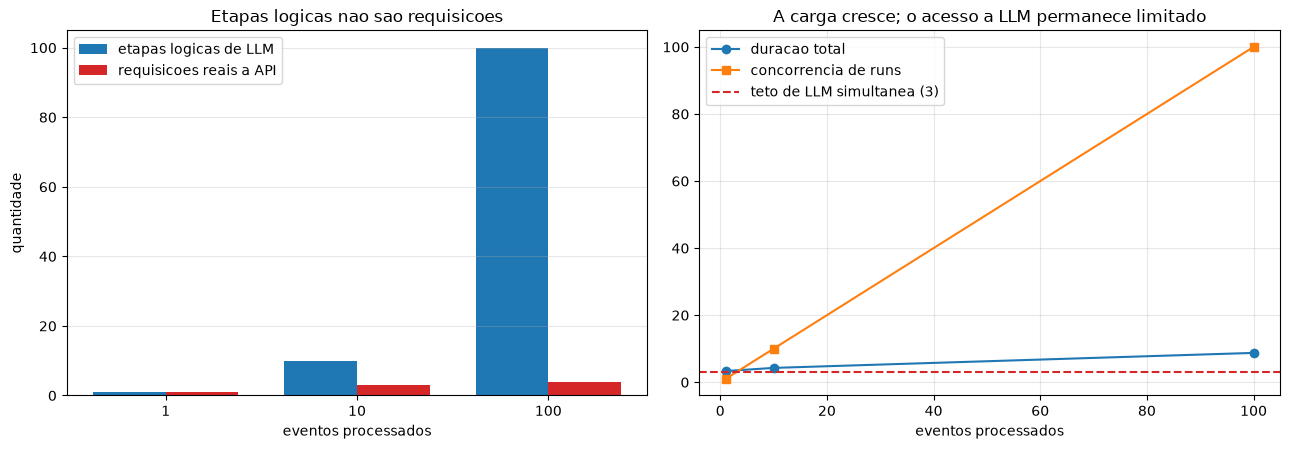

In [20]:
# Celula 1.3 - runs versus requisicoes reais: as duas curvas nao coincidem
qtd = [m.recebidos for m in metricas_atividade1]
rotulos = [str(q) for q in qtd]
x = list(range(len(qtd)))
largura = 0.38

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].bar([i - largura / 2 for i in x], [m.logical_llm_steps for m in metricas_atividade1],
            largura, label="etapas logicas de LLM", color=COR["baseline"])
axes[0].bar([i + largura / 2 for i in x], [m.real_api_calls for m in metricas_atividade1],
            largura, label="requisicoes reais a API", color=COR["llm"])
axes[0].set_xticks(x, rotulos)
axes[0].set_xlabel("eventos processados")
axes[0].set_ylabel("quantidade")
axes[0].set_title("Etapas logicas nao sao requisicoes")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(qtd, [m.duracao_total for m in metricas_atividade1],
             marker="o", color=COR["baseline"], label="duracao total")
axes[1].plot(qtd, [m.concorrencia_maxima for m in metricas_atividade1],
             marker="s", color=COR["falha"], label="concorrencia de runs")
axes[1].axhline(MAX_PARALLEL_LLM_CALLS, color=COR["llm"], linestyle="--",
                label=f"teto de LLM simultanea ({MAX_PARALLEL_LLM_CALLS})")
axes[1].set_xlabel("eventos processados")
axes[1].set_title("A carga cresce; o acesso a LLM permanece limitado")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

> ### Observe
>
> - **Runs e requisicoes crescem em ritmos diferentes.** Os 100 runs geram 100 etapas
>   logicas de LLM, mas apenas as entradas *novas* viram requisicao. Na primeira
>   execucao do notebook, as chamadas reais param em torno do numero de perfis (8); em
>   uma segunda execucao, com o cache ja povoado, elas caem para perto de zero.
> - **A concorrencia de runs continua sem limite** (100 runs ativos), mas a concorrencia
>   de *requisicoes reais* nunca passa de `MAX_PARALLEL_LLM_CALLS`. Sao dois limites
>   distintos, e so o segundo protege o fornecedor.
> - **A primeira execucao de um perfil paga a latencia integral.** O `p95` da LLM e
>   dominado justamente por essas chamadas; os cache hits entram com latencia zero e por
>   isso sao contabilizados separadamente - misturar os dois produziria uma media
>   bonita e mentirosa.
> - **Cache nao e capacidade.** Ele apenas evita trabalho *equivalente*. Se os 100
>   eventos tivessem 100 albuns realmente diferentes, seriam 100 chamadas - e o
>   orcamento de `MAX_LIVE_LLM_CALLS` interromperia a execucao com uma mensagem clara,
>   que e exatamente o comportamento desejado.


## Interpretacao

- O grafo do agente **nao precisou ganhar nenhum no novo**. As cinco etapas sao as mesmas
  nos tres cenarios.
- O problema esta na **politica de execucao**: quantos runs podem existir ao mesmo tempo,
  o que acontece quando a capacidade acaba, quem guarda o progresso.
- Executar mais runs aumenta simultaneamente tres coisas: **contencao** (disputa por
  recursos), **exposicao a falhas** (mais tentativas, mais chances de erro) e **custo**.
- Escalar, portanto, **nao significa apenas adicionar workers**. Significa decidir
  limites, ordem de atendimento e como o estado sobrevive.

> ### Erro comum
>
> Concluir que "o sistema aguentou 100 eventos" apenas porque nenhum run falhou. Sem
> limite de concorrencia, o sistema nao aguentou: ele apenas teve sorte com a carga
> testada. Com uma dependencia externa real - que rejeita a 51a chamada simultanea - o
> mesmo codigo produziria dezenas de erros.

> ### Relacao com o Pipeline Guardian e com producao
>
> O Pipeline Guardian, no repositorio CopaFigurinhas, nasce respondendo a um evento de
> pipeline por vez: um `workflow_run` chega, o agente diagnostica, devolve o resultado.
> Isso e o cenario "uma execucao".
>
> Em producao, o mesmo agente e acionado por todos os pushes de todos os repositorios de
> uma organizacao. Uma segunda-feira de manha concentra dezenas de pipelines. A logica de
> diagnostico continua valida; o que falta e a camada operacional: limite de execucoes,
> fila de entrada, estado duravel e politica de retry. As proximas atividades constroem
> exatamente essa camada.

---

# Atividade 2 - Localizando o gargalo

## Conceito

A capacidade de um fluxo nao e a media das suas etapas. Ela e limitada pela **etapa mais
lenta ou mais restrita**. Isso vale tanto para uma fabrica quanto para um agente: nao
adianta acelerar a validacao se a analise leva dez vezes mais tempo.

Nosso fluxo:

```
Receber evento -> Validar -> Consultar album -> Analisar colecao -> Registrar recomendacao
```

Se a analise leva 6 unidades de tempo e todas as outras etapas somam 6 unidades juntas,
metade do tempo de cada run esta concentrada em um unico ponto. Otimizar qualquer outra
etapa produz ganho pequeno; otimizar a analise produz ganho grande.

## Onde os gargalos costumam aparecer

### Persistencia

- tempo de leitura e gravacao;
- contencao no armazenamento (locks, pool de conexoes esgotado);
- serializacao de estados grandes - quanto maior o estado, mais caro cada checkpoint.

### API externa ou catalogo

- tempo de resposta que voce nao controla;
- **rate limit**: um teto de chamadas por segundo ou por minuto;
- timeouts;
- indisponibilidade temporaria.

### Analise com IA

- latencia do modelo, geralmente a maior do fluxo;
- tokens: quanto maior o contexto, mais lento e mais caro;
- custo por chamada;
- concorrencia permitida pela cota contratada.

### Aprovacao ou decisao humana

- tempo de espera que pode ser de horas;
- horario de atendimento - um run que chega as 19h so avanca no dia seguinte;
- acumulo de runs aguardando, que vira backlog visivel.

Repare que os dois ultimos casos **nao sao resolviveis com mais maquina**.

## As perguntas de investigacao

Antes de mudar qualquer coisa, responda:

1. **Em que etapa os runs passam mais tempo?** Some a duracao por etapa, nao por run.
2. **Onde surge a maior fila?** O gargalo e onde o trabalho se acumula.
3. **Qual dependencia possui o menor limite?** O menor teto da cadeia define a capacidade.
4. **O gargalo e interno ou externo?** Interno voce otimiza; externo voce negocia,
   contorna com cache ou absorve com fila.
5. **Aumentar workers realmente aumentaria a capacidade?** Só se o gargalo for a
   capacidade de execucao local.

> Adicionar workers **nao remove** o rate limit de uma API externa, **nao reduz** a
> latencia de uma aprovacao humana e **nao aumenta** o pool de conexoes do banco. Nesses
> casos, mais workers apenas produzem mais processos esperando.

## O que sera demonstrado

Vamos instrumentar cada etapa do fluxo (inicio, fim, duracao, `event_id`, `run_id`,
status) e executar 30 eventos com um perfil de latencia onde:

- a validacao e rapida;
- a consulta ao album tem latencia intermediaria;
- a analise da colecao e a etapa mais lenta;
- a gravacao e rapida.

Depois vamos **mover o gargalo**: em uma segunda execucao a analise fica ainda mais
lenta; em uma terceira, a consulta ao album passa a ser a etapa dominante. O objetivo e
mostrar que o gargalo nao e uma propriedade fixa do codigo.

### Como a LLM participa desta atividade

A etapa "Analisar colecao" e a chamada real ao modelo. Para localizar o gargalo, ela e
decomposta em tres tempos que costumam ser somados por engano:

| Tempo | O que e | Como reduzir |
| --- | --- | --- |
| **espera pelo semaforo** | a requisicao existe, mas nao ha vaga | aumentar o limite (se a cota permitir) |
| **latencia da API** | o modelo pensando e respondendo | prompt/modelo menor, menos tokens |
| **validacao da resposta** | parse + Pydantic | quase sempre irrelevante - e o ponto |

A terceira coluna existe para uma conclusao: se a validacao aparece com 0,001s e a API
com 2s, otimizar o parser e desperdicio de esforco.

**A latencia da LLM nao e simulada.** As demais etapas continuam com atraso injetado de
forma deterministica, para que os dois experimentos sejam comparaveis.


> ### Pergunta para a turma
>
> **Se o servico externo permite apenas duas chamadas simultaneas, o que acontece ao
> aumentar os workers de tres para dez?**

In [21]:
# Celula 2.1 - 30 eventos com instrumentacao por etapa (analise = LLM real)
eventos_30 = gerar_eventos(30)

registro_etapas: list[dict] = []
pol_a2 = Politicas(perfil=PerfilLatencia(validar=1, consultar_album=3,
                                         gerar_recomendacao=1, registrar=1),
                   limite_runs=asyncio.Semaphore(5),
                   activity_id="atividade_02_gargalo",
                   prompt_version="gargalo_v1",
                   n_perfis=4)

marco_a2 = marco_llm()
runs_a2, dur_a2, med_a2 = await executar_lote(eventos_30, pol_a2,
                                              registro_etapas=registro_etapas)
llm_a2 = metricas_llm_desde(marco_a2)

log.info("30 eventos em %.2fs | etapas LLM=%d | reais=%d | cache=%d | tokens=%d/%d",
         dur_a2, llm_a2["logical_llm_steps"], llm_a2["real_api_calls"],
         llm_a2["cache_hits"], llm_a2["input_tokens"], llm_a2["output_tokens"])

30 eventos em 7.20s | etapas LLM=30 | reais=4 | cache=26 | tokens=1646/610


In [22]:
# Celula 2.2 - DataFrame por etapa (amostra) e estatisticas agregadas
df_etapas = pd.DataFrame(registro_etapas)
print("Amostra do registro por etapa (5 primeiras linhas de", len(df_etapas), "):")
display(df_etapas[["event_id", "run_id", "etapa", "duracao", "status"]].head(5))

ORDEM_ETAPAS = ["validar", "consultar_album", "analisar_colecao", "gerar_recomendacao", "registrar"]

stats_etapas = (df_etapas.groupby("etapa")["duracao"]
                .agg(execucoes="count", media="mean",
                     p50=lambda s: percentil(list(s), 50),
                     p95=lambda s: percentil(list(s), 95),
                     tempo_total="sum")
                .reindex(ORDEM_ETAPAS).round(4))
stats_etapas["participacao_%"] = (stats_etapas["tempo_total"] /
                                  stats_etapas["tempo_total"].sum() * 100).round(1)
stats_etapas

Amostra do registro por etapa (5 primeiras linhas de 150 ):


,event_id,run_id,etapa,duracao,status
0,evt-001,run-0112-evt-001,validar,0.030366,ok
1,evt-002,run-0113-evt-002,validar,0.030379,ok
2,evt-003,run-0114-evt-003,validar,0.031509,ok
3,evt-004,run-0115-evt-004,validar,0.031524,ok
4,evt-005,run-0116-evt-005,validar,0.031522,ok


,execucoes,media,p50,p95,tempo_total,participacao_%
etapa,,,,,,
validar,30,0.0314,0.0313,0.0323,0.9413,2.7
consultar_album,30,0.0948,0.0944,0.0979,2.8429,8.0
analisar_colecao,30,0.9791,0.0002,3.1821,29.3737,83.0
gerar_recomendacao,30,0.0433,0.0317,0.1130,1.2981,3.7
registrar,30,0.0317,0.0314,0.0324,0.9499,2.7


In [23]:
# Celula 2.2b - decomposicao da etapa de LLM (espera / API / validacao)
df_llm_etapa = pd.DataFrame(
    [l for l in registro_etapas if l["etapa"] == "analisar_colecao"])

decomposicao = pd.DataFrame([{
    "componente": "espera pelo semaforo da LLM",
    "media_s": round(df_llm_etapa["llm_espera_s"].mean(), 4),
    "total_s": round(df_llm_etapa["llm_espera_s"].sum(), 3),
}, {
    "componente": "latencia da API da OpenAI",
    "media_s": round(df_llm_etapa["llm_api_s"].mean(), 4),
    "total_s": round(df_llm_etapa["llm_api_s"].sum(), 3),
}, {
    "componente": "validacao da resposta (parse + Pydantic)",
    "media_s": round(df_llm_etapa["llm_validacao_s"].mean(), 6),
    "total_s": round(df_llm_etapa["llm_validacao_s"].sum(), 5),
}, {
    "componente": "latencia total da etapa",
    "media_s": round(df_llm_etapa["duracao"].mean(), 4),
    "total_s": round(df_llm_etapa["duracao"].sum(), 3),
}])

print("Decomposicao da etapa 'analisar_colecao' (30 runs):")
display(decomposicao)

print("Origem de cada etapa logica:")
display(df_llm_etapa["llm_cache_source"].value_counts().rename("runs").to_frame())
print()
print("Tokens consumidos na atividade 2 -",
      custo_ilustrativo_texto(llm_a2["input_tokens"], llm_a2["output_tokens"]))

Decomposicao da etapa 'analisar_colecao' (30 runs):


,componente,media_s,total_s
0,espera pelo semaforo da LLM,0.000000,0.00000
1,latencia da API da OpenAI,0.340800,10.22300
2,validacao da resposta (parse + Pydantic),0.000003,0.00008
3,latencia total da etapa,0.979100,29.37400


Origem de cada etapa logica:


,runs
llm_cache_source,
sqlite,20
em_voo,6
api,4



Tokens consumidos na atividade 2 - tokens: entrada=1646 saida=610 total=2256 | custo monetario nao configurado (somente tokens)


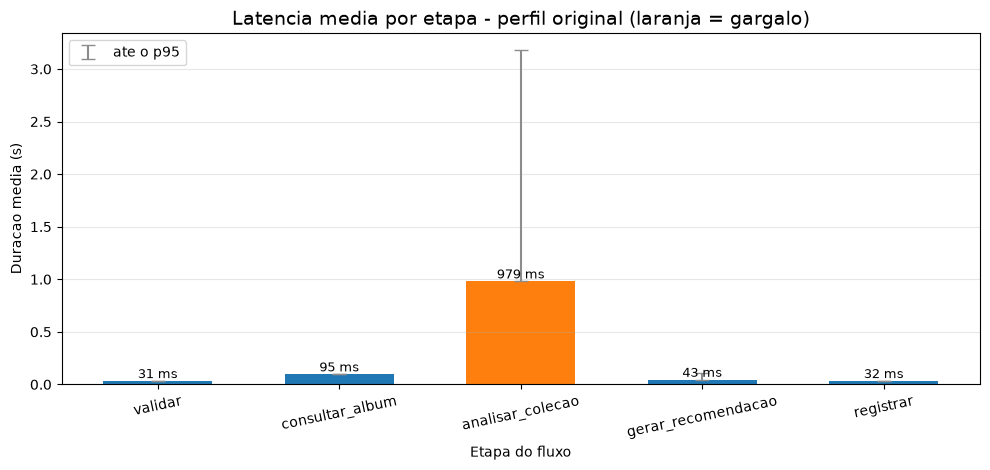

Etapa mais lenta (gargalo): analisar_colecao


In [24]:
# Celula 2.3 - grafico de barras da latencia media por etapa, destacando a mais lenta
def grafico_gargalo(stats: pd.DataFrame, titulo: str):
    etapa_lenta = stats["media"].idxmax()
    cores = [COR["falha"] if e == etapa_lenta else COR["baseline"] for e in stats.index]

    fig, ax = plt.subplots(figsize=(10, 4.8))
    barras = ax.bar(stats.index, stats["media"], color=cores, width=0.6)
    margem = (stats["p95"] - stats["media"]).clip(lower=0)
    ax.errorbar(stats.index, stats["media"],
                yerr=[[0] * len(stats), margem],
                fmt="none", ecolor=COR["neutro"], capsize=5, label="ate o p95")
    for b, v in zip(barras, stats["media"]):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v*1000:.0f} ms",
                ha="center", va="bottom", fontsize=9)
    ax.set_title(titulo, fontsize=14)
    ax.set_xlabel("Etapa do fluxo")
    ax.set_ylabel("Duracao media (s)")
    ax.legend(loc="upper left")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=12)
    plt.tight_layout()
    plt.show()
    print(f"Etapa mais lenta (gargalo): {etapa_lenta}")


grafico_gargalo(stats_etapas, "Latencia media por etapa - perfil original (laranja = gargalo)")

In [25]:
# Celula 2.4 - quantos runs disputaram cada recurso
espera_recursos = pd.DataFrame([
    {"recurso": "runs simultaneos", "limite": 5,
     "pico_observado": med_a2.runs.maximo,
     "runs_que_disputaram": len(eventos_30)},
    {"recurso": "consulta ao catalogo (simulada)", "limite": "sem limite",
     "pico_observado": med_a2.catalogo.maximo, "runs_que_disputaram": len(eventos_30)},
    {"recurso": "etapa de analise (LLM real)", "limite": MAX_PARALLEL_LLM_CALLS,
     "pico_observado": llm_gateway.medidor.maximo,
     "runs_que_disputaram": len(eventos_30)},
])
print("O unico limite que protege um fornecedor externo e o da LLM.")
espera_recursos

O unico limite que protege um fornecedor externo e o da LLM.


,recurso,limite,pico_observado,runs_que_disputaram
0,runs simultaneos,5,5,30
1,consulta ao catalogo (simulada),sem limite,5,30
2,etapa de analise (LLM real),3,3,30


### Movendo o gargalo

Agora repetimos o mesmo experimento alterando **apenas o perfil de latencia**. O codigo do
fluxo nao muda uma linha.

In [26]:
# Celula 2.5 - dois experimentos: quem e o gargalo muda, o codigo nao
async def medir_experimento(nome: str, perfil: PerfilLatencia,
                            activity_id: str) -> tuple[pd.DataFrame, dict, float]:
    """Executa 30 eventos e devolve (estatisticas por etapa, metricas de LLM, duracao).

    Apenas as latencias SIMULADAS mudam entre os experimentos. A etapa de LLM continua
    sendo a chamada real - a sua latencia e observada, nunca configurada.
    """
    reg: list[dict] = []
    pol = Politicas(perfil=perfil, limite_runs=asyncio.Semaphore(5),
                    activity_id=activity_id, prompt_version="gargalo_v1", n_perfis=4)
    marco = marco_llm()
    _, dur, _ = await executar_lote(gerar_eventos(30), pol, registro_etapas=reg)
    llm = metricas_llm_desde(marco)
    df = pd.DataFrame(reg)
    st = (df.groupby("etapa")["duracao"]
          .agg(media="mean", p50=lambda s: percentil(list(s), 50),
               p95=lambda s: percentil(list(s), 95), tempo_total="sum")
          .reindex(ORDEM_ETAPAS).round(4))
    st["participacao_%"] = (st["tempo_total"] / st["tempo_total"].sum() * 100).round(1)
    log.info("%-34s dur=%.2fs | gargalo=%s | reais=%d cache=%d",
             nome, dur, st["media"].idxmax(), llm["real_api_calls"], llm["cache_hits"])
    return st, llm, dur


# Experimento A: a consulta ao album e lenta; a LLM responde normalmente.
perfil_catalogo_lento = PerfilLatencia(validar=1, consultar_album=90,
                                       gerar_recomendacao=1, registrar=1)
stats_catalogo_lento, llm_expA, dur_expA = await medir_experimento(
    "A) catalogo lento, LLM normal", perfil_catalogo_lento, "atividade_02_gargalo")

# Experimento B: a consulta ao album e rapida; a LLM passa a ser a etapa mais lenta.
perfil_catalogo_rapido = PerfilLatencia(validar=1, consultar_album=1,
                                        gerar_recomendacao=1, registrar=1)
stats_catalogo_rapido, llm_expB, dur_expB = await medir_experimento(
    "B) catalogo rapido, LLM dominante", perfil_catalogo_rapido, "atividade_02_gargalo")

comparativo_gargalo = pd.DataFrame({
    "A - catalogo lento (participacao %)": stats_catalogo_lento["participacao_%"],
    "B - catalogo rapido (participacao %)": stats_catalogo_rapido["participacao_%"],
})
print("\nParticipacao de cada etapa no tempo total de fluxo:")
display(comparativo_gargalo)
print(f"Experimento A: gargalo = {stats_catalogo_lento['media'].idxmax()}")
print(f"Experimento B: gargalo = {stats_catalogo_rapido['media'].idxmax()}")
print("\nObs.: nos dois experimentos as chamadas reais foram poucas porque o cache da "
      "atividade ja estava povoado. O que mudou foi o PESO RELATIVO das etapas.")

A) catalogo lento, LLM normal      dur=17.44s | gargalo=consultar_album | reais=0 cache=30


B) catalogo rapido, LLM dominante  dur=0.78s | gargalo=gerar_recomendacao | reais=0 cache=30



Participacao de cada etapa no tempo total de fluxo:


,A - catalogo lento (participacao %),B - catalogo rapido (participacao %)
etapa,,
validar,1.1,24.6
consultar_album,96.7,25.0
analisar_colecao,0.0,0.2
gerar_recomendacao,1.1,25.1
registrar,1.1,25.1


Experimento A: gargalo = consultar_album
Experimento B: gargalo = gerar_recomendacao

Obs.: nos dois experimentos as chamadas reais foram poucas porque o cache da atividade ja estava povoado. O que mudou foi o PESO RELATIVO das etapas.


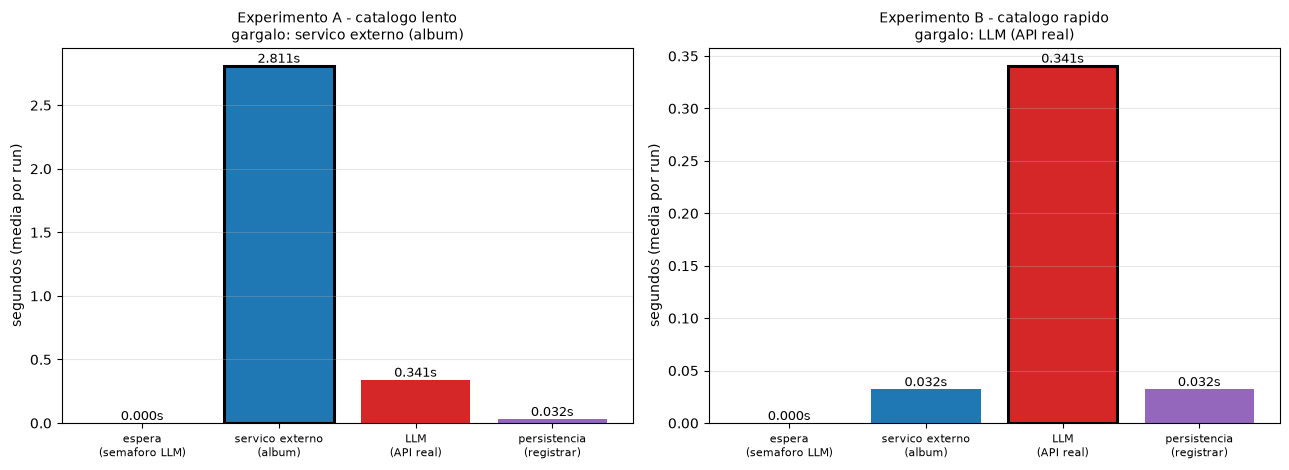

A etapa de LLM e a unica cuja altura NAO foi escolhida por nos.


In [27]:
# Celula 2.6 - decomposicao visual: espera, servico externo, LLM e persistencia
def grafico_decomposto(stats: pd.DataFrame, llm_df: pd.DataFrame, titulo: str, ax):
    componentes = {
        "espera (semaforo LLM)": llm_df["llm_espera_s"].mean(),
        "servico externo (album)": stats.loc["consultar_album", "media"],
        "LLM (API real)": llm_df["llm_api_s"].mean(),
        "persistencia (registrar)": stats.loc["registrar", "media"],
    }
    cores = [COR["neutro"], COR["baseline"], COR["llm"], COR["persistencia"]]
    maior = max(componentes, key=componentes.get)
    barras = ax.bar(range(len(componentes)), list(componentes.values()), color=cores)
    for b, (nome, v) in zip(barras, componentes.items()):
        if nome == maior:
            b.set_edgecolor("black")
            b.set_linewidth(2.2)
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}s",
                ha="center", va="bottom", fontsize=9)
    ax.set_xticks(range(len(componentes)),
                  [c.replace(" (", "\n(") for c in componentes], fontsize=8)
    ax.set_ylabel("segundos (media por run)")
    ax.set_title(f"{titulo}\ngargalo: {maior}", fontsize=10)
    ax.grid(axis="y", alpha=0.3)


df_llm_A = pd.DataFrame([l for l in registro_etapas if l["etapa"] == "analisar_colecao"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
grafico_decomposto(stats_catalogo_lento, df_llm_A,
                   "Experimento A - catalogo lento", axes[0])
grafico_decomposto(stats_catalogo_rapido, df_llm_A,
                   "Experimento B - catalogo rapido", axes[1])
plt.tight_layout()
plt.show()

print("A etapa de LLM e a unica cuja altura NAO foi escolhida por nos.")

> ### Observe
>
> - **O gargalo mudou de lugar sem que uma linha do fluxo mudasse.** No experimento A, a
>   consulta ao album domina; no B, com o catalogo rapido, a etapa de LLM assume - e ela
>   nao pode ser "acelerada" com um parametro, porque a sua duracao vem do fornecedor.
> - **A validacao da resposta e irrelevante em tempo.** Ela aparece na casa dos
>   microssegundos contra segundos da API. Isso e uma decisao de onde *nao* investir.
> - **A espera pelo semaforo e um custo real, mas e nosso.** Ela nao aparece na fatura da
>   OpenAI e nao e culpa do modelo: e o preco de proteger a cota. Confundi-la com
>   latencia da API leva a conclusao errada de que "o modelo esta lento".
> - Quando a LLM e o gargalo, as saidas sao diferentes das de sempre: reduzir tokens de
>   saida, trocar de modelo, dividir o trabalho em chamadas menores, ou aceitar a
>   latencia e trabalhar de forma assincrona. Adicionar workers nao ajuda.


## Interpretacao

Respondendo a pergunta da turma - se o servico externo permite apenas duas chamadas
simultaneas e voce sobe de 3 para 10 workers:

- **o limite efetivo continua sendo o servico externo**: no maximo duas chamadas
  acontecem ao mesmo tempo, independentemente de quantos workers existam;
- **a espera apenas muda de lugar**: antes os eventos esperavam para entrar em um worker,
  agora eles esperam dentro do worker, segurando recursos (memoria, conexao, timeout ativo);
- na pratica, o cenario com 10 workers pode ficar **pior**: mais chamadas em espera
  significa mais chance de estourar timeout e mais retentativas inuteis;
- **capacidade deve ser medida, nao presumida.**

> ### Relacao com o Pipeline Guardian e com producao
>
> No Pipeline Guardian, a etapa "analisar colecao" corresponde a chamada ao modelo que
> interpreta os logs do pipeline. Ela e quase sempre o gargalo: e a etapa mais lenta, a
> mais cara e a que tem o menor limite de concorrencia contratado.
>
> Em producao, essa instrumentacao por etapa e o que alimenta os paineis de observabilidade
> (traces por span). Sem ela, a equipe discute com base em impressao. Com ela, a
> conversa vira "78% do tempo esta na analise; vale a pena cachear o diagnostico de
> pipelines identicos?".

---

# Atividade 3 - Arquitetura essencial e controle de picos

## Conceito: as tres responsabilidades

```
Eventos -> Entrada/API -> Fila -> Workers <-> Persistencia
```

### Entrada

**Responsabilidades:** receber eventos; autenticar e autorizar; validar o formato;
normalizar os campos; criar o run.

**Resultado:** um run aceito - ou uma rejeicao rapida e explicita.

A entrada e barata e deve permanecer barata. Ela nunca executa o agente; ela apenas
transforma "uma requisicao" em "um trabalho registrado".

### Coordenacao

**Responsabilidades:** organizar os runs; aplicar limites; decidir qual e a proxima
etapa; pausar ou retomar; acompanhar o estado de cada run.

**Resultado:** trabalho organizado, com ordem e teto conhecidos.

### Execucao

**Responsabilidades:** executar as funcoes do agente; chamar modelos e APIs; executar
ferramentas; registrar resultados.

**Resultado:** estado atualizado e efeitos externos aplicados.

> Essas sao **responsabilidades logicas**, nao necessariamente processos separados. Elas
> podem comecar no mesmo projeto, no mesmo arquivo. Separa-las fisicamente so se justifica
> quando existir um motivo operacional concreto: escalar uma parte independentemente da
> outra, isolar falhas, ou atender requisitos de deploy diferentes.

## Conceito: para que serve uma fila

Uma fila **desacopla o ritmo de chegada do ritmo de processamento**. Sao duas grandezas
independentes: quem manda eventos nao sabe (nem deveria saber) quantos workers existem.

### Sem fila

- o pico atinge diretamente os workers;
- a concorrencia cresce sem teto;
- surgem timeouts, porque tudo fica mais lento ao mesmo tempo;
- requisicoes passam a ser rejeitadas quando a capacidade acaba;
- o sistema perde previsibilidade - nao da para prometer nada.

### Com fila

- os eventos aguardam de forma organizada, sem se perder;
- os workers processam no limite estabelecido, em ritmo constante;
- o **backlog fica visivel** e vira um indicador operacional;
- o sistema absorve picos temporarios sem quebrar.

> Uma fila **nao cria capacidade**. Ela organiza a espera. Se a taxa de chegada for
> permanentemente maior que a de processamento, a fila cresce para sempre - e o problema
> apenas fica mais visivel, nao resolvido.

## O que sera demonstrado

Dois experimentos com os **mesmos 30 eventos** e a **mesma capacidade** (equivalente a 3
workers):

- **Experimento A - sem fila:** os eventos vao direto aos workers. Quando a capacidade
  esta ocupada, o evento e **rejeitado** (o comportamento tipico de um servico sobrecarregado).
- **Experimento B - com `asyncio.Queue`:** um produtor insere os 30 eventos, tres workers
  consomem. Nenhum evento deve desaparecer. Registramos o tamanho da fila ao longo do tempo
  e a espera antes do processamento.

### Como a LLM participa desta atividade

Cada item retirado da fila por um worker chega a etapa logica de LLM, sempre atraves do
`LLMGateway`. Isso cria uma separacao importante:

- a **fila** protege o sistema contra perder eventos;
- o **semaforo do gateway** protege a **API** contra excesso de requisicoes.

Sao duas defesas em camadas diferentes. Um sistema com fila e sem limite de LLM ainda
derruba a cota; um sistema com limite de LLM e sem fila ainda perde eventos.

**Nao provocamos erros reais na API de proposito.** A sobrecarga e simulada na camada da
aplicacao (capacidade de atendimento), enquanto as chamadas reais permanecem sempre
protegidas pelo semaforo. Gerar dezenas de `RateLimitError` de verdade seria caro,
lento e nao ensinaria nada que a simulacao nao ensine.


> ### Pergunta para a turma
>
> **A fila torna o sistema mais rapido ou apenas mais controlavel?**

In [28]:
# Celula 3.1 - Experimento A: sem fila (capacidade 3, excedente e rejeitado)
CAPACIDADE = 3

async def experimento_sem_fila(eventos: list[Event]) -> tuple[list[RunResult], float, Medidores, int]:
    med = Medidores()
    pol = Politicas(activity_id="atividade_03_fila", prompt_version="fila_v1", n_perfis=4)
    vagas = {"livres": CAPACIDADE}
    chegada = time.perf_counter()
    resultados: list[RunResult] = []
    aguardaram = {"n": 0}

    async def tentar(ev: Event):
        if vagas["livres"] <= 0:
            # Sem fila, o excedente e recusado na porta - e nunca chega a LLM.
            r = RunResult(run_id=novo_run_id(ev.event_id), event_id=ev.event_id,
                          chegada=chegada, status="rejeitado", erro="capacidade esgotada")
            r.inicio = r.fim = time.perf_counter()
            resultados.append(r)
            return
        vagas["livres"] -= 1
        aguardaram["n"] += 1
        try:
            resultados.append(await executar_run(ev, pol, med, chegada, worker="direto"))
        finally:
            vagas["livres"] += 1

    with Cronometro() as c:
        await asyncio.gather(*[tentar(ev) for ev in eventos])
    return resultados, c.duracao, med, aguardaram["n"]


marco_a3a = marco_llm()
runs_sem_fila, dur_sem_fila, med_sem_fila, atendidos_sem_fila = \
    await experimento_sem_fila(eventos_30)
llm_sem_fila = metricas_llm_desde(marco_a3a)

m_sem_fila = resumir("A - sem fila", runs_sem_fila, dur_sem_fila,
                     concorrencia_maxima=med_sem_fila.runs.maximo)
log.info("A) recebidos=%d concluidos=%d rejeitados=%d | etapas LLM=%d reais=%d cache=%d",
         m_sem_fila.recebidos, m_sem_fila.concluidos, m_sem_fila.rejeitados,
         llm_sem_fila["logical_llm_steps"], llm_sem_fila["real_api_calls"],
         llm_sem_fila["cache_hits"])
print("Eventos que NUNCA chegaram a etapa de LLM:", m_sem_fila.rejeitados)

A) recebidos=30 concluidos=3 rejeitados=27 | etapas LLM=3 reais=2 cache=1


Eventos que NUNCA chegaram a etapa de LLM: 27


In [29]:
# Celula 3.2 - Experimento B: asyncio.Queue, 3 workers, LLM limitada a 3 simultaneas
async def experimento_com_fila(eventos: list[Event], n_workers: int = CAPACIDADE):
    fila: asyncio.Queue = asyncio.Queue()
    med = Medidores()
    pol = Politicas(activity_id="atividade_03_fila", prompt_version="fila_v1", n_perfis=4)
    resultados: list[RunResult] = []
    backlog: list[tuple[float, int]] = []
    esperas_ate_worker: list[float] = []
    parar = asyncio.Event()

    async def produtor():
        for ev in eventos:
            await fila.put((ev, time.perf_counter()))
            backlog.append((time.perf_counter(), fila.qsize()))

    async def worker(nome: str):
        while True:
            try:
                ev, t_chegada = await asyncio.wait_for(fila.get(), timeout=0.05)
            except asyncio.TimeoutError:
                if parar.is_set():
                    return
                continue
            backlog.append((time.perf_counter(), fila.qsize()))
            esperas_ate_worker.append(time.perf_counter() - t_chegada)
            r = await executar_run(ev, pol, med, t_chegada, worker=nome)
            resultados.append(r)
            fila.task_done()

    with Cronometro() as c:
        workers = [asyncio.create_task(worker(f"worker-{i+1}")) for i in range(n_workers)]
        await produtor()
        await fila.join()
        parar.set()
        await asyncio.gather(*workers)
    return resultados, c.duracao, med, backlog, esperas_ate_worker


marco_a3b = marco_llm()
runs_com_fila, dur_com_fila, med_com_fila, backlog, esperas_worker = \
    await experimento_com_fila(eventos_30)
llm_com_fila = metricas_llm_desde(marco_a3b)

m_com_fila = resumir("B - com fila (3 workers)", runs_com_fila, dur_com_fila,
                     concorrencia_maxima=med_com_fila.runs.maximo,
                     backlog_maximo=max(q for _, q in backlog))
log.info("B) recebidos=%d concluidos=%d rejeitados=%d backlog_max=%d | "
         "etapas LLM=%d reais=%d cache=%d",
         m_com_fila.recebidos, m_com_fila.concluidos, m_com_fila.rejeitados,
         m_com_fila.backlog_maximo, llm_com_fila["logical_llm_steps"],
         llm_com_fila["real_api_calls"], llm_com_fila["cache_hits"])

B) recebidos=30 concluidos=30 rejeitados=0 backlog_max=30 | etapas LLM=30 reais=2 cache=28


In [30]:
# Celula 3.3 - comparacao entre os dois experimentos, com a camada de LLM explicita
comparacao_fila = pd.DataFrame([
    {"experimento": "A - sem fila", "eventos_recebidos": len(eventos_30),
     "processados": m_sem_fila.concluidos, "rejeitados": m_sem_fila.rejeitados,
     "backlog_maximo": 0,
     "espera_media_worker_s": 0.0,
     "etapas_logicas_llm": llm_sem_fila["logical_llm_steps"],
     "chamadas_reais": llm_sem_fila["real_api_calls"],
     "cache_hits": llm_sem_fila["cache_hits"],
     "espera_media_llm_s": llm_sem_fila["llm_espera_media_s"],
     "tokens_entrada": llm_sem_fila["input_tokens"],
     "tokens_saida": llm_sem_fila["output_tokens"],
     "duracao_s": round(dur_sem_fila, 3)},
    {"experimento": "B - com fila (3 workers)", "eventos_recebidos": len(eventos_30),
     "processados": m_com_fila.concluidos, "rejeitados": m_com_fila.rejeitados,
     "backlog_maximo": m_com_fila.backlog_maximo,
     "espera_media_worker_s": round(sum(esperas_worker) / len(esperas_worker), 3),
     "etapas_logicas_llm": llm_com_fila["logical_llm_steps"],
     "chamadas_reais": llm_com_fila["real_api_calls"],
     "cache_hits": llm_com_fila["cache_hits"],
     "espera_media_llm_s": llm_com_fila["llm_espera_media_s"],
     "tokens_entrada": llm_com_fila["input_tokens"],
     "tokens_saida": llm_com_fila["output_tokens"],
     "duracao_s": round(dur_com_fila, 3)},
])
display(comparacao_fila)

print(f"Pico de requisicoes reais simultaneas em toda a atividade: "
      f"{llm_gateway.medidor.maximo} (teto configurado: {MAX_PARALLEL_LLM_CALLS})")
print("Repare: a fila mudou quantos eventos foram ATENDIDOS; o semaforo do gateway "
      "manteve a pressao sobre a API constante nos dois experimentos.")

,experimento,eventos_recebidos,processados,rejeitados,backlog_maximo,espera_media_worker_s,etapas_logicas_llm,chamadas_reais,cache_hits,espera_media_llm_s,tokens_entrada,tokens_saida,duracao_s
0,A - sem fila,30,3,27,0,0.000,3,2,1,0.0,822,358,4.030
1,B - com fila (3 workers),30,30,0,30,2.747,30,2,28,0.0,824,298,5.085


Pico de requisicoes reais simultaneas em toda a atividade: 3 (teto configurado: 3)
Repare: a fila mudou quantos eventos foram ATENDIDOS; o semaforo do gateway manteve a pressao sobre a API constante nos dois experimentos.


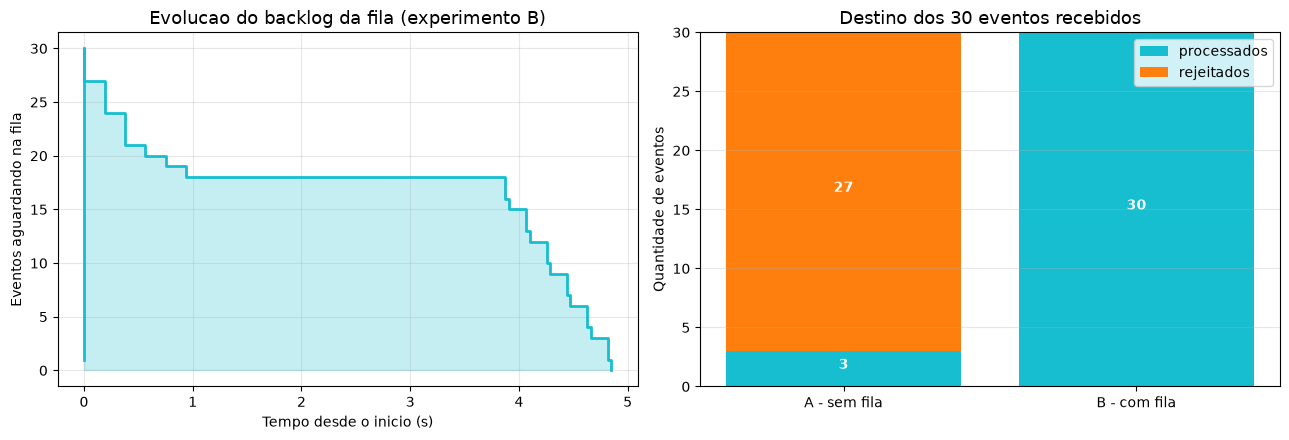

In [31]:
# Celula 3.4 - evolucao do backlog ao longo do tempo (experimento B)
t0 = backlog[0][0]
tempos = [t - t0 for t, _ in backlog]
tamanhos = [q for _, q in backlog]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].step(tempos, tamanhos, where="post", color=COR["controle"], linewidth=2)
axes[0].fill_between(tempos, tamanhos, step="post", alpha=0.25, color=COR["controle"])
axes[0].set_title("Evolucao do backlog da fila (experimento B)", fontsize=13)
axes[0].set_xlabel("Tempo desde o inicio (s)")
axes[0].set_ylabel("Eventos aguardando na fila")
axes[0].grid(alpha=0.3)

rotulos = ["A - sem fila", "B - com fila"]
processados = [m_sem_fila.concluidos, m_com_fila.concluidos]
perdidos = [m_sem_fila.rejeitados, m_com_fila.rejeitados]
axes[1].bar(rotulos, processados, color=COR["controle"], label="processados")
axes[1].bar(rotulos, perdidos, bottom=processados, color=COR["falha"], label="rejeitados")
for i, (p, r) in enumerate(zip(processados, perdidos)):
    axes[1].text(i, p / 2, str(p), ha="center", color="white", fontweight="bold")
    if r:
        axes[1].text(i, p + r / 2, str(r), ha="center", color="white", fontweight="bold")
axes[1].set_title("Destino dos 30 eventos recebidos", fontsize=13)
axes[1].set_ylabel("Quantidade de eventos")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

> ### Observe
>
> - **Sem fila, eventos somem antes de chegar a LLM.** Os rejeitados nao consumiram
>   token algum - o que pode parecer uma economia, mas e um pedido de usuario perdido.
> - **Com fila, nada se perde**; o custo aparece como espera. O backlog e a evidencia
>   visivel dessa espera.
> - **O pico de requisicoes reais e o mesmo nos dois experimentos.** A fila nao protege
>   a API; quem faz isso e o semaforo do gateway. Sao controles complementares, nao
>   substitutos - e essa e a razao de existirem separados.
> - Uma fila cheia e um sintoma, nao uma solucao: se a taxa de chegada supera de forma
>   sustentada a taxa de processamento, a fila apenas adia o problema e transforma
>   rejeicao imediata em latencia crescente.


## Interpretacao

- A fila **pode aumentar o tempo de resposta individual**: um evento que seria atendido
  na hora agora espera sua vez. O p95 de espera cresce.
- Sua funcao principal nao e velocidade, e sim **proteger o sistema e organizar o
  trabalho**: nenhum evento e perdido, e a concorrencia permanece dentro do teto.
- A **capacidade continua dependendo dos workers e das dependencias externas**. A fila nao
  processa nada; ela apenas segura o que ainda nao pode ser processado.
- Resposta a pergunta: a fila torna o sistema **mais controlavel**, e em geral nao mais
  rapido. Em compensacao, torna-o previsivel - e previsibilidade e o que permite prometer
  um SLA.

> ### Erro comum
>
> Tratar a fila como solucao de capacidade: "vamos colocar uma fila e o problema de carga
> some". Se a taxa media de chegada supera a taxa media de processamento, a fila cresce
> indefinidamente. A fila resolve **picos**, nao **sobrecarga sustentada**.

> ### Relacao com o Pipeline Guardian e com producao
>
> No CopaFigurinhas, os eventos de pipeline chegam em rajadas: um merge na main dispara
> varios workflows quase ao mesmo tempo. Sem fila, o agente recusaria diagnosticos
> justamente no momento em que eles sao mais necessarios.
>
> Em producao, essa `asyncio.Queue` seria SQS, RabbitMQ, Redis Streams ou Cloud Tasks. A
> mecanica conceitual e identica: produtor, backlog observavel, consumidores com teto e
> confirmacao de processamento (`task_done`). Aprender o padrao aqui torna a troca de
> tecnologia um detalhe de implementacao.

---

# Atividade 4 - Concorrencia controlada e limites externos

## Conceito: concorrencia nao e um numero so

Dizer "o sistema roda com concorrencia 10" e ambiguo. Existem pelo menos **dois niveis**
distintos, e eles precisam ser controlados separadamente.

### Concorrencia de runs

Quantidade de **execucoes completas** ativas ao mesmo tempo.

Exemplo:
- maximo de tres runs ativos;
- runs adicionais aguardam sua vez (na fila ou no semaforo).

Esse limite protege a memoria e o processamento locais.

### Concorrencia por dependencia

Quantidade de **chamadas simultaneas a cada servico** especifico.

Exemplo:
- ate tres runs ativos;
- no maximo duas chamadas simultaneas ao catalogo de figurinhas;
- no maximo duas analises simultaneas.

Repare que os numeros nao precisam ser iguais. Um run que esta gerando a recomendacao nao
esta ocupando o catalogo; portanto o limite do catalogo pode ser menor que o de runs sem
desperdicar capacidade.

## Por que os limites precisam ser independentes

- **APIs possuem rate limits proprios**, definidos por quem as opera, nao por voce;
- **modelos de linguagem** costumam ter dois limites simultaneos: requisicoes por minuto
  *e* tokens por minuto - e o segundo pode ser atingido antes do primeiro;
- **bancos de dados** tem pool de conexoes: passar do pool nao gera lentidao gradual,
  gera erro;
- **acoes criticas** (aprovar, publicar, cobrar) podem exigir execucao serial para evitar
  condicoes de corrida;
- **mais workers nao significam chamadas externas ilimitadas** - o teto externo continua
  o mesmo.

Um unico semaforo global forcaria todos esses limites a serem iguais ao menor deles,
desperdicando capacidade nas etapas que nao sao restritas.

## O que sera demonstrado

Primeiro, aplicamos **tres semaforos independentes** e provamos, com contadores, que
nenhum limite foi ultrapassado durante 30 execucoes:

```python
limite_runs     = asyncio.Semaphore(3)
limite_catalogo = asyncio.Semaphore(2)
limite_analise  = asyncio.Semaphore(2)
```

Depois fazemos um **planejamento de capacidade**: variamos os workers em `[1, 2, 3, 5, 10]`
mantendo o limite do catalogo em 2, e observamos o que acontece com o throughput.

### Como a LLM participa desta atividade

Esta atividade usa **dois limites independentes**:

```python
limite_catalogo = asyncio.Semaphore(2)   # dependencia interna simulada
limite_llm      = llm_gateway.semaforo   # asyncio.Semaphore(MAX_PARALLEL_LLM_CALLS) = 3
```

O `limite_llm` **nao e criado aqui**: ele vive dentro do `LLMGateway` e vale para o
notebook inteiro. Essa e justamente a razao de o gateway existir - um limite de cota
precisa ser global ao processo, nao local a uma atividade.

O que sera demonstrado: aumentar workers nao aumenta o acesso ao modelo. O pico de
requisicoes reais permanece em 3, os runs excedentes esperam, e o catalogo pode
continuar sendo o gargalo mesmo quando a LLM tem capacidade sobrando.


> ### Pergunta para a turma
>
> **Por que o throughput deixa de crescer, mesmo adicionando mais workers?**
>
> Faca sua aposta: com 10 workers, o throughput sera aproximadamente 10 vezes o de 1 worker?

In [32]:
# Celula 4.1 - dois limites independentes: catalogo (2) e LLM (3)
LIMITE_RUNS, LIMITE_CATALOGO = 3, 2

limite_catalogo = asyncio.Semaphore(LIMITE_CATALOGO)
limite_llm = llm_gateway.semaforo          # o teto real de requisicoes a OpenAI

pol_a4 = Politicas(
    limite_runs=asyncio.Semaphore(LIMITE_RUNS),
    limite_catalogo=limite_catalogo,
    activity_id="atividade_04_limites",
    prompt_version="limites_v1",
    n_perfis=4,
)
med_a4 = Medidores()
llm_gateway.medidor.zerar()
marco_a4 = marco_llm()
runs_a4, dur_a4, med_a4 = await executar_lote(eventos_30, pol_a4, med=med_a4)
llm_a4 = metricas_llm_desde(marco_a4)

evidencias = pd.DataFrame([
    {"recurso": "runs simultaneos", "limite_configurado": LIMITE_RUNS,
     "maximo_observado": med_a4.runs.maximo,
     "respeitado": med_a4.runs.maximo <= LIMITE_RUNS},
    {"recurso": "chamadas ao catalogo", "limite_configurado": LIMITE_CATALOGO,
     "maximo_observado": med_a4.catalogo.maximo,
     "respeitado": med_a4.catalogo.maximo <= LIMITE_CATALOGO},
    {"recurso": "requisicoes REAIS a OpenAI", "limite_configurado": MAX_PARALLEL_LLM_CALLS,
     "maximo_observado": llm_gateway.medidor.maximo,
     "respeitado": llm_gateway.medidor.maximo <= MAX_PARALLEL_LLM_CALLS},
])
log.info("30 eventos, %d concluidos em %.2fs | etapas LLM=%d reais=%d cache=%d",
         sum(1 for r in runs_a4 if r.status == "concluido"), dur_a4,
         llm_a4["logical_llm_steps"], llm_a4["real_api_calls"], llm_a4["cache_hits"])
display(evidencias)

30 eventos, 30 concluidos em 10.76s | etapas LLM=30 reais=4 cache=26


,recurso,limite_configurado,maximo_observado,respeitado
0,runs simultaneos,3,3,True
1,chamadas ao catalogo,2,2,True
2,requisicoes REAIS a OpenAI,3,2,True


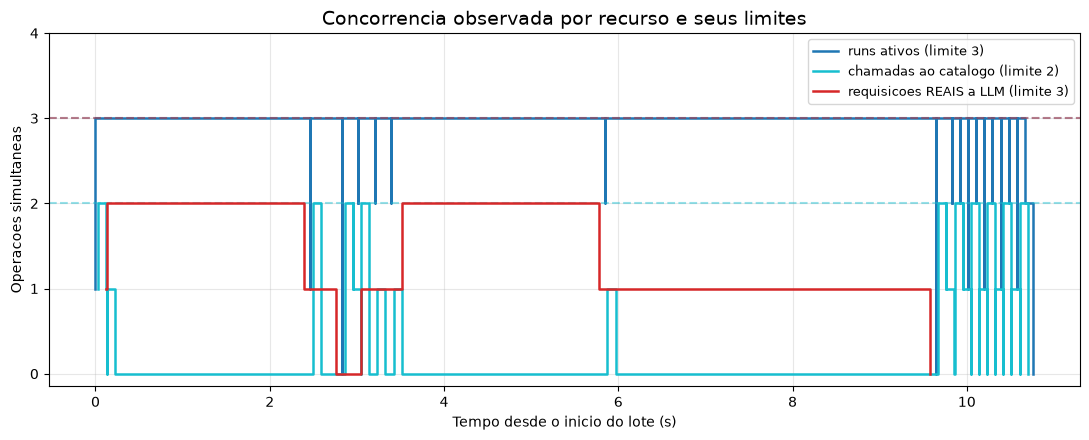

In [33]:
# Celula 4.2 - prova visual: nenhum limite foi ultrapassado ao longo do tempo
fig, ax = plt.subplots(figsize=(11, 4.5))
inicio_ref = min(a[0] for a in med_a4.runs.amostras)

for medidor, cor, limite, rotulo in [
    (med_a4.runs, COR["baseline"], LIMITE_RUNS, "runs ativos"),
    (med_a4.catalogo, COR["controle"], LIMITE_CATALOGO, "chamadas ao catalogo"),
    (llm_gateway.medidor, COR["llm"], MAX_PARALLEL_LLM_CALLS, "requisicoes REAIS a LLM"),
]:
    xs = [t - inicio_ref for t, _ in medidor.amostras]
    ys = [v for _, v in medidor.amostras]
    ax.step(xs, ys, where="post", color=cor, linewidth=1.8, label=f"{rotulo} (limite {limite})")
    ax.axhline(limite, color=cor, linestyle="--", alpha=0.45)

ax.set_title("Concorrencia observada por recurso e seus limites", fontsize=14)
ax.set_xlabel("Tempo desde o inicio do lote (s)")
ax.set_ylabel("Operacoes simultaneas")
ax.set_yticks(range(0, LIMITE_RUNS + 2))
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# Celula 4.3 - planejamento de capacidade: workers [1, 2, 3, 5, 10]
# O catalogo fica fixo em 2 e a LLM em MAX_PARALLEL_LLM_CALLS. So os workers mudam.
EVENTOS_CAPACIDADE = gerar_eventos(12)
linhas_capacidade = []

for n_workers in [1, 2, 3, 5, 10]:
    pol = Politicas(
        limite_runs=asyncio.Semaphore(n_workers),
        limite_catalogo=asyncio.Semaphore(2),   # limite externo fixo
        activity_id="atividade_04_limites",
        prompt_version="limites_v1",
        n_perfis=4,
    )
    med = Medidores()
    llm_gateway.medidor.zerar()
    marco = marco_llm()
    runs, dur, med = await executar_lote(EVENTOS_CAPACIDADE, pol, med=med)
    llm = metricas_llm_desde(marco)
    m = resumir(f"{n_workers} workers", runs, dur, concorrencia_maxima=med.runs.maximo)
    linhas_capacidade.append({
        "workers": n_workers,
        "duracao_s": round(dur, 3),
        "throughput_run_s": round(m.throughput, 2),
        "latencia_p95_s": round(m.p95, 3),
        "conc_max_runs": med.runs.maximo,
        "conc_max_catalogo": med.catalogo.maximo,
        "conc_max_llm_real": llm_gateway.medidor.maximo,
        "chamadas_reais": llm["real_api_calls"],
        "cache_hits": llm["cache_hits"],
        "espera_llm_media_s": llm["llm_espera_media_s"],
    })

df_capacidade = pd.DataFrame(linhas_capacidade)
base_tp = df_capacidade.loc[0, "throughput_run_s"]
df_capacidade["ganho_vs_1_worker"] = (df_capacidade["throughput_run_s"] / base_tp).round(2)

# Contadores resumidos - nao imprimimos evento a evento.
print(f"Teto de LLM simultanea: {MAX_PARALLEL_LLM_CALLS} | "
      f"maior valor observado em TODAS as configuracoes: "
      f"{df_capacidade['conc_max_llm_real'].max()}")
print(f"Teto do catalogo: 2 | maior valor observado: "
      f"{df_capacidade['conc_max_catalogo'].max()}")
display(df_capacidade)

Teto de LLM simultanea: 3 | maior valor observado em TODAS as configuracoes: 0
Teto do catalogo: 2 | maior valor observado: 2


,workers,duracao_s,throughput_run_s,latencia_p95_s,conc_max_runs,conc_max_catalogo,conc_max_llm_real,chamadas_reais,cache_hits,espera_llm_media_s,ganho_vs_1_worker
0,1,2.174,5.52,2.074,1,1,0,0,12,0.0,1.00
1,2,1.118,10.74,1.117,2,2,0,0,12,0.0,1.95
2,3,0.842,14.26,0.790,3,2,0,0,12,0.0,2.58
3,5,0.660,18.19,0.659,5,2,0,0,12,0.0,3.30
4,10,0.679,17.68,0.679,10,2,0,0,12,0.0,3.20


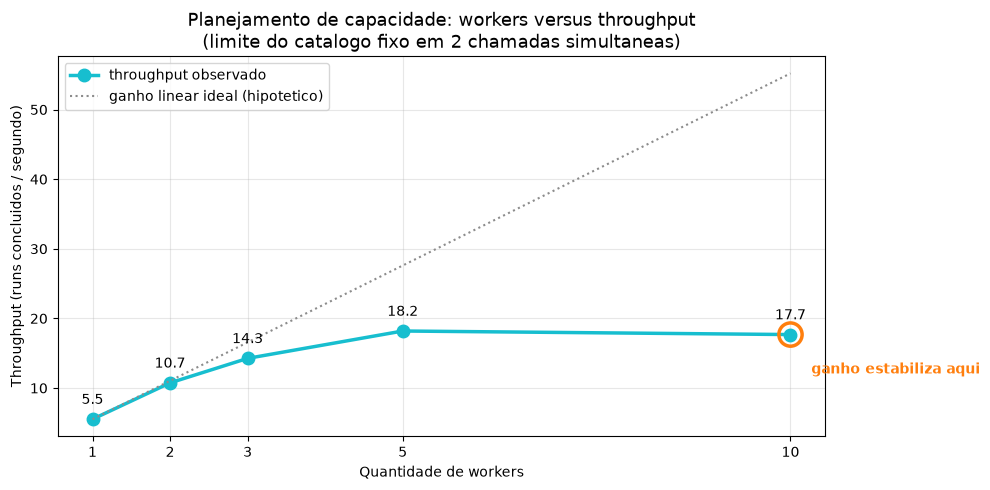

In [35]:
# Celula 4.4 - curva de capacidade: onde o ganho estabiliza
fig, ax = plt.subplots(figsize=(10, 5))
x = df_capacidade["workers"]
y = df_capacidade["throughput_run_s"]

ax.plot(x, y, marker="o", markersize=9, linewidth=2.5, color=COR["controle"],
        label="throughput observado")
ax.plot(x, [base_tp * w for w in x], linestyle=":", color=COR["neutro"],
        label="ganho linear ideal (hipotetico)")

# Ponto em que o ganho marginal cai abaixo de 10%
ponto_saturacao = None
for i in range(1, len(y)):
    if (y.iloc[i] - y.iloc[i - 1]) / y.iloc[i - 1] < 0.10:
        ponto_saturacao = (x.iloc[i], y.iloc[i])
        break
if ponto_saturacao:
    ax.scatter(*ponto_saturacao, s=280, facecolors="none",
               edgecolors=COR["falha"], linewidths=2.5, zorder=5)
    ax.annotate("ganho estabiliza aqui", ponto_saturacao,
                textcoords="offset points", xytext=(15, -28),
                color=COR["falha"], fontweight="bold")

for xi, yi in zip(x, y):
    ax.annotate(f"{yi:.1f}", (xi, yi), textcoords="offset points", xytext=(0, 11), ha="center")

ax.set_title("Planejamento de capacidade: workers versus throughput\n(limite do catalogo fixo em 2 chamadas simultaneas)",
             fontsize=13)
ax.set_xlabel("Quantidade de workers")
ax.set_ylabel("Throughput (runs concluidos / segundo)")
ax.set_xticks(list(x))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> ### Observe
>
> - **`conc_max_llm_real` nunca passa de 3**, nem com 10 workers. O semaforo do gateway
>   e independente do numero de workers - e essa independencia e o que impede que um
>   ajuste de escala do nosso lado derrube a cota do fornecedor.
> - **Runs adicionais nao somem: eles esperam.** O aumento aparece em
>   `espera_llm_media_s`, nao em `conc_max_llm_real`. Escalar workers sem escalar o
>   limite externo converte throughput em fila.
> - **O catalogo continua sendo gargalo mesmo com a LLM ociosa.** Com o catalogo em 2 e
>   a LLM em 3, ha momentos em que existe vaga no modelo e nao ha dado para analisar.
>   Um unico semaforo global esconderia isso: os dois limites precisam ser separados
>   justamente para que a saturacao de um nao seja confundida com a do outro.
> - O ganho de throughput estabiliza. Depois que os dois limites saturam, adicionar
>   worker adiciona espera, nao capacidade.


## Interpretacao

- **A dependencia externa tornou-se o gargalo.** A partir do momento em que o catalogo e a
  analise saturam seus dois slots, adicionar workers nao adiciona capacidade.
- **Workers adicionais passam mais tempo aguardando** do que trabalhando. Eles nao sao
  neutros: consomem memoria, mantem conexoes abertas e podem estourar timeouts enquanto
  esperam.
- **Escalar exige observar toda a cadeia.** A capacidade do sistema e a do elo mais
  restrito, e o unico jeito de descobrir qual e ele e medindo.
- Consequencia pratica: antes de pedir mais maquinas, verifique se o limite que doi e
  interno (voce resolve) ou externo (voce negocia, cacheia ou enfileira).

> ### Relacao com o Pipeline Guardian e com producao
>
> O Pipeline Guardian chama a API do GitHub para buscar logs e um modelo para diagnosticar.
> Ambos tem cotas. Um unico semaforo global obrigaria as duas etapas a compartilhar o
> menor teto, desperdicando cota do GitHub sempre que o modelo estivesse ocupado.
>
> Em producao esse padrao aparece como *bulkhead* (compartimentacao): cada dependencia
> ganha seu proprio pool. Assim, uma dependencia lenta degrada apenas a sua parte do fluxo,
> em vez de travar o sistema inteiro.

---

# Atividade 5 - Estado, checkpoints e recuperacao

## Conceito: workers desacoplados

Um worker e uma instancia descartavel. Ele pode ser reiniciado durante um deploy, morto
por falta de memoria, removido por uma politica de autoescala ou simplesmente perder a
rede. Nada disso deveria destruir o trabalho ja realizado.

Dai a regra central:

- o **worker executa** o run;
- o **progresso duravel nao deve existir apenas na memoria do worker**;
- **outro worker deve poder continuar** a execucao de onde o primeiro parou;
- workers podem manter cache temporario em memoria - isso e legitimo e ate desejavel por
  desempenho - mas esse cache **nao pode ser o unico lugar** onde o estado duravel existe.

Se a resposta para "o que acontece se este processo morrer agora?" for "perdemos tudo",
entao o estado esta no lugar errado.

## Conceito: persistencia compartilhada

Um armazenamento acessivel por todos os workers guarda:

- **estado do run**: em que etapa esta, qual o status atual;
- **checkpoints**: os pontos seguros ja confirmados;
- **historico**: o que aconteceu, quando e por qual worker;
- **status**: `pendente`, `executando`, `concluido`, `falha_final`;
- **tentativas**: quantas vezes ja foi tentado, para respeitar o limite de retry.

O historico e frequentemente subestimado. Ele e o que permite responder, semanas depois,
"por que este run demorou tres horas?" - e essa e uma pergunta que sempre aparece.

## Conceito: checkpoints

Um checkpoint e um **snapshot do estado em um ponto seguro** do fluxo. Ele:

- preserva o ultimo progresso **confirmado** (nao o progresso "quase pronto");
- permite retomar a execucao apos uma falha, sem refazer tudo desde o inicio;
- normalmente faz o passo interrompido **reiniciar do comeco**, porque nao se sabe quanto
  dele chegou a ser executado.

E aqui vem a limitacao que mais gera confusao:

> **Checkpoint, sozinho, nao garante que efeitos externos nao serao duplicados.**

Se o passo interrompido ja tinha enviado um e-mail, criado um registro ou cobrado um
cartao, retoma-lo do comeco repete esse efeito. Resolver isso exige idempotencia - o tema
da Atividade 7.

Sequencia usada na demonstracao:

```
Validar -> Consultar album -> Analisar colecao -> Gerar recomendacao -> Registrar resultado
```

## O que sera demonstrado

Usaremos **SQLite** como persistencia externa ao worker. O banco fica em
`artifacts/agentes_complexos_escalaveis/`, criado pelo notebook e removido pela funcao de
limpeza. Nenhum banco da aplicacao CopaFigurinhas e tocado.

Roteiro:

1. Worker A inicia o run do evento `evt-007`.
2. Worker A valida o evento.
3. Worker A consulta o album.
4. Um checkpoint e salvo.
5. Worker A falha durante a analise (falha **deterministica**, sempre no `evt-007`, sempre
   na primeira tentativa).
6. Worker B le o ultimo checkpoint.
7. Worker B reinicia a etapa interrompida.
8. Worker B conclui o run.

### Como a LLM participa desta atividade

A etapa "Analisar colecao" e a chamada real ao modelo - a etapa **cara** do fluxo. Isso
torna a demonstracao mais honesta do que na versao simulada: perder a analise nao custa
mais um `sleep`, custa tokens e latencia de verdade.

O roteiro e deliberado:

1. o worker A recebe o estado;
2. salva checkpoint apos consultar o album;
3. **chama a LLM** (requisicao real, resposta obtida, resposta cacheada);
4. uma falha didatica ocorre **depois** da resposta, mas **antes** de a etapa ser
   confirmada - ou seja, antes do checkpoint de `analisar_colecao`;
5. o worker B retoma pelo ultimo checkpoint;
6. o worker B **reinicia a etapa interrompida**;
7. o cache devolve a mesma analise sem uma segunda cobranca, porque a entrada e a versao
   do prompt sao identicas.

#### Checkpoint e cache nao sao a mesma coisa

| | Checkpoint | Cache |
| --- | --- | --- |
| Pergunta que responde | "ate onde eu ja cheguei?" | "esse trabalho ja foi feito?" |
| Escopo | um run especifico | qualquer run com entrada equivalente |
| Se sumir | o run recomeca do zero | o run refaz e paga de novo |
| Protege | progresso | custo |

E um terceiro controle, a **idempotencia**, protege o efeito externo. Os tres resolvem
problemas diferentes; nenhum substitui o outro. Um cache que "preserva progresso" e uma
ilusao: ele nao sabe em que etapa o run estava.


> ### Pergunta para a turma
>
> **O segundo worker continua exatamente da linha em que o primeiro parou?**

In [36]:
# Celula 5.1 - persistencia externa em SQLite (tabelas runs, checkpoints e historico)
CAMINHO_BANCO = BASE_ARTEFATOS / "copafigurinhas_estado.sqlite"


def criar_banco(caminho: Path = CAMINHO_BANCO) -> sqlite3.Connection:
    """Cria um banco novo, isolado, exclusivo deste notebook."""
    if caminho.exists():
        caminho.unlink()
    con = sqlite3.connect(caminho)
    # Banco descartavel de demonstracao: dispensamos a durabilidade contra queda de
    # energia para que centenas de commits didaticos nao dominem o tempo do notebook.
    # Em producao, NAO se usa synchronous=OFF em um armazenamento de estado.
    con.execute("PRAGMA synchronous=OFF")
    con.execute("PRAGMA journal_mode=MEMORY")
    con.executescript("""
        CREATE TABLE runs (
            run_id       TEXT PRIMARY KEY,
            event_id     TEXT NOT NULL,
            album_id     TEXT NOT NULL,
            status       TEXT NOT NULL,
            etapa_atual  TEXT,
            tentativas   INTEGER NOT NULL DEFAULT 0,
            worker       TEXT,
            atualizado_em REAL
        );
        CREATE TABLE checkpoints (
            id        INTEGER PRIMARY KEY AUTOINCREMENT,
            run_id    TEXT NOT NULL,
            etapa     TEXT NOT NULL,
            estado    TEXT NOT NULL,   -- JSON com o estado confirmado
            criado_em REAL
        );
        CREATE TABLE historico (
            id        INTEGER PRIMARY KEY AUTOINCREMENT,
            run_id    TEXT NOT NULL,
            worker    TEXT NOT NULL,
            evento    TEXT NOT NULL,
            detalhe   TEXT,
            criado_em REAL
        );
    """)
    con.commit()
    return con


con = criar_banco()
print("Banco criado em:", CAMINHO_BANCO)
print("Tabelas:", [r[0] for r in con.execute(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")])

Banco criado em: artifacts/agentes_complexos_escalaveis_llm/copafigurinhas_estado.sqlite
Tabelas: ['checkpoints', 'historico', 'runs', 'sqlite_sequence']


In [37]:
# Celula 5.2 - operacoes de estado: salvar checkpoint, ler o ultimo, registrar historico
def registrar_historico(con, run_id, worker, evento, detalhe=""):
    con.execute("INSERT INTO historico (run_id, worker, evento, detalhe, criado_em) VALUES (?,?,?,?,?)",
                (run_id, worker, evento, detalhe, time.time()))
    con.commit()


def salvar_checkpoint(con, run_id, etapa, estado: dict):
    con.execute("INSERT INTO checkpoints (run_id, etapa, estado, criado_em) VALUES (?,?,?,?)",
                (run_id, etapa, json.dumps(estado), time.time()))
    con.execute("UPDATE runs SET etapa_atual=?, atualizado_em=? WHERE run_id=?",
                (etapa, time.time(), run_id))
    con.commit()


def ler_ultimo_checkpoint(con, run_id) -> Optional[tuple[str, dict]]:
    linha = con.execute(
        "SELECT etapa, estado FROM checkpoints WHERE run_id=? ORDER BY id DESC LIMIT 1",
        (run_id,)).fetchone()
    return (linha[0], json.loads(linha[1])) if linha else None


def atualizar_run(con, run_id, **campos):
    campos["atualizado_em"] = time.time()
    sets = ", ".join(f"{k}=?" for k in campos)
    con.execute(f"UPDATE runs SET {sets} WHERE run_id=?", (*campos.values(), run_id))
    con.commit()


def tabela(con, sql, params=()) -> pd.DataFrame:
    return pd.read_sql_query(sql, con, params=params)


print("Operacoes de estado definidas.")

Operacoes de estado definidas.


In [38]:
# Celula 5.3 - executor com checkpoint: retoma a partir do ultimo estado confirmado
SEQUENCIA = ["validar", "consultar_album", "analisar_colecao", "gerar_recomendacao", "registrar"]


class SemaforoOpcional:
    """Aplica um asyncio.Semaphore quando ele existe; caso contrario, nao faz nada."""

    def __init__(self, sem: Optional[asyncio.Semaphore]):
        self.sem = sem

    async def __aenter__(self):
        if self.sem is not None:
            await self.sem.acquire()

    async def __aexit__(self, *exc):
        if self.sem is not None:
            self.sem.release()
        return False


def analise_enxuta(analise: dict) -> dict:
    """Versao serializavel da analise, para caber no checkpoint.

    O objeto LLMResult e o prompt NAO vao para o estado: guardamos apenas o rastro
    (response_id, cache_key, tokens) e a recomendacao estruturada.
    """
    llm: LLMResult = analise["llm"]
    return {
        "perfil_id": analise["perfil_id"],
        "risco": analise["risco"],
        "recomendacao": analise["recomendacao"],
        "response_id": llm.response_id,
        "cache_key": llm.cache_key[:16],
        "cache_hit": llm.cache_hit,
        "tokens_entrada": llm.input_tokens,
        "tokens_saida": llm.output_tokens,
    }


async def executar_com_checkpoint(con, ev: Event, worker: str,
                                  pol: Politicas, med: Medidores) -> str:
    """Executa (ou retoma) o run do evento, salvando checkpoint apos cada etapa.

    Devolve o status final. A retomada sempre reinicia a etapa interrompida.
    """
    linha = con.execute("SELECT run_id, tentativas FROM runs WHERE event_id=?",
                        (ev.event_id,)).fetchone()
    if linha is None:
        run_id = novo_run_id(ev.event_id)
        con.execute("INSERT INTO runs (run_id, event_id, album_id, status, etapa_atual,"
                    " tentativas, worker, atualizado_em) VALUES (?,?,?,?,?,?,?,?)",
                    (run_id, ev.event_id, ev.album_id, "executando", None, 0, worker, time.time()))
        con.commit()
        registrar_historico(con, run_id, worker, "run_criado", f"evento {ev.event_id}")
        estado, concluidas = {}, []
    else:
        run_id = linha[0]
        cp = ler_ultimo_checkpoint(con, run_id)
        if cp is None:
            estado, concluidas = {}, []
        else:
            etapa_cp, estado = cp
            concluidas = SEQUENCIA[:SEQUENCIA.index(etapa_cp) + 1]
        registrar_historico(con, run_id, worker, "run_retomado",
                            f"ultimo checkpoint: {concluidas[-1] if concluidas else 'nenhum'}")

    RUN_ID_ATUAL.set(run_id)
    tentativa = con.execute("SELECT tentativas FROM runs WHERE run_id=?", (run_id,)).fetchone()[0] + 1
    atualizar_run(con, run_id, tentativas=tentativa, status="executando", worker=worker)

    pendentes = [e for e in SEQUENCIA if e not in concluidas]
    registrar_historico(con, run_id, worker, "tentativa_iniciada",
                        f"tentativa {tentativa}; etapas pendentes: {', '.join(pendentes)}")

    # O album e reconstruido a partir do perfil: o estado guarda o identificador,
    # nao o objeto - mais um exemplo de estado enxuto.
    def _album_do_estado() -> dict:
        dados = estado.get("album", {})
        perfil = PERFIS_POR_ID.get(dados.get("perfil_id")) or perfil_do_evento(
            ev.event_id, pol.n_perfis)
        return {"perfil": perfil, "total": perfil.total_figurinhas,
                "obtidas": perfil.obtidas, "faltantes": perfil.faltantes,
                "repetidas": perfil.repetidas}

    try:
        async with SemaforoOpcional(pol.limite_runs):
            with med.runs:
                for etapa in pendentes:
                    if etapa == "validar":
                        await etapa_validar(ev, pol, med)
                        estado["validado"] = True
                    elif etapa == "consultar_album":
                        album = await etapa_consultar_album(ev, pol, med)
                        estado["album"] = {"perfil_id": album["perfil"].perfil_id,
                                           "total": album["total"],
                                           "obtidas": album["obtidas"],
                                           "faltantes": album["faltantes"]}
                    elif etapa == "analisar_colecao":
                        bruta = await etapa_analisar_colecao(
                            ev, pol, med, _album_do_estado(), tentativa)
                        estado["analise"] = analise_enxuta(bruta)
                    elif etapa == "gerar_recomendacao":
                        acao = (estado["analise"].get("recomendacao") or {}).get(
                            "acao_recomendada", "recomendacao indisponivel")
                        await dormir(pol.perfil.gerar_recomendacao * TIME_SCALE, med.runs)
                        estado["recomendacao"] = f"Album {ev.album_id}: {acao}"
                    elif etapa == "registrar":
                        estado["action_id"] = await etapa_registrar_resultado(
                            ev, pol, med, estado["recomendacao"])
                    salvar_checkpoint(con, run_id, etapa, estado)
                    registrar_historico(con, run_id, worker, "checkpoint_salvo", etapa)
        atualizar_run(con, run_id, status="concluido", worker=worker)
        registrar_historico(con, run_id, worker, "run_concluido", "")
        return "concluido"
    except FalhaTemporaria as exc:
        atualizar_run(con, run_id, status="falhou", worker=worker)
        registrar_historico(con, run_id, worker, "falha_temporaria", str(exc))
        return "falhou"


print("Executor com checkpoint definido (a analise usa LLM real e cai no cache na retomada).")

Executor com checkpoint definido (a analise usa LLM real e cai no cache na retomada).


In [39]:
# Celula 5.4 - worker A: chama a LLM, obtem a resposta e SO ENTAO falha
evento_alvo = Event(event_id="evt-007", album_id="album-091", tipo="analisar_colecao")
pol_a5 = Politicas(falhas_programadas=frozenset({"evt-007"}),
                   activity_id="atividade_05_checkpoint",
                   prompt_version="checkpoint_v1",
                   n_perfis=1)
med_a5 = Medidores()

marco_a5a = marco_llm()
status_a = await executar_com_checkpoint(con, evento_alvo, "worker-A", pol_a5, med_a5)
llm_worker_a = metricas_llm_desde(marco_a5a)

log.info("Worker A terminou com status: %s", status_a)
print(f"Worker A -> etapas logicas de LLM: {llm_worker_a['logical_llm_steps']} | "
      f"chamadas REAIS: {llm_worker_a['real_api_calls']} | "
      f"cache hits: {llm_worker_a['cache_hits']} | "
      f"tokens: {llm_worker_a['input_tokens']}/{llm_worker_a['output_tokens']}")
print("A resposta da LLM foi obtida e ja esta no cache. A falha veio DEPOIS disso.")
print()
print("Estado do run APOS a falha do worker A:")
display(tabela(con, "SELECT run_id, event_id, status, etapa_atual, tentativas, worker FROM runs"))

print("Checkpoints existentes apos a falha:")
display(tabela(con, "SELECT id, etapa, length(estado) AS bytes_estado FROM checkpoints ORDER BY id"))
print("Note que NAO ha checkpoint de 'analisar_colecao': a etapa nao chegou a ser confirmada.")

Worker A terminou com status: falhou


Worker A -> etapas logicas de LLM: 1 | chamadas REAIS: 1 | cache hits: 0 | tokens: 409/137
A resposta da LLM foi obtida e ja esta no cache. A falha veio DEPOIS disso.

Estado do run APOS a falha do worker A:


,run_id,event_id,status,etapa_atual,tentativas,worker
0,run-0352-evt-007,evt-007,falhou,consultar_album,1,worker-A


Checkpoints existentes apos a falha:


,id,etapa,bytes_estado
0,1,validar,18
1,2,consultar_album,107


Note que NAO ha checkpoint de 'analisar_colecao': a etapa nao chegou a ser confirmada.


In [40]:
# Celula 5.5 - worker B retoma pelo checkpoint e a LLM vem do cache
cp = ler_ultimo_checkpoint(con, tabela(con, "SELECT run_id FROM runs").iloc[0]["run_id"])
print("Ultimo checkpoint confirmado:", cp[0])
print("Chaves preservadas no estado:", sorted(cp[1].keys()))
print("A etapa 'analisar_colecao' NAO tem checkpoint: sera reiniciada do comeco.\n")

marco_a5b = marco_llm()
status_b = await executar_com_checkpoint(con, evento_alvo, "worker-B", pol_a5, med_a5)
llm_worker_b = metricas_llm_desde(marco_a5b)
log.info("Worker B terminou com status: %s", status_b)

print()
comparacao_recuperacao = pd.DataFrame([
    {"worker": "A (falhou)", **{k: llm_worker_a[k] for k in
     ("logical_llm_steps", "real_api_calls", "cache_hits", "input_tokens", "output_tokens")}},
    {"worker": "B (retomou)", **{k: llm_worker_b[k] for k in
     ("logical_llm_steps", "real_api_calls", "cache_hits", "input_tokens", "output_tokens")}},
])
display(comparacao_recuperacao)

print("Tres controles, tres responsabilidades:")
print("  checkpoint ... preservou o progresso (validar e consultar_album nao se repetiram);")
print("  cache ........ evitou o trabalho equivalente (a analise nao foi cobrada de novo);")
print("  idempotencia . protege o efeito externo (assunto da atividade 7).")
print()
print("O worker B REEXECUTOU a etapa logica de analise - isso e visivel em "
      "logical_llm_steps. O que ele nao fez foi pagar por ela outra vez.")

Worker B terminou com status: concluido


Ultimo checkpoint confirmado: consultar_album
Chaves preservadas no estado: ['album', 'validado']
A etapa 'analisar_colecao' NAO tem checkpoint: sera reiniciada do comeco.




,worker,logical_llm_steps,real_api_calls,cache_hits,input_tokens,output_tokens
0,A (falhou),1,1,0,409,137
1,B (retomou),1,0,1,0,0


Tres controles, tres responsabilidades:
  checkpoint ... preservou o progresso (validar e consultar_album nao se repetiram);
  cache ........ evitou o trabalho equivalente (a analise nao foi cobrada de novo);
  idempotencia . protege o efeito externo (assunto da atividade 7).

O worker B REEXECUTOU a etapa logica de analise - isso e visivel em logical_llm_steps. O que ele nao fez foi pagar por ela outra vez.


In [41]:
# Celula 5.6 - evidencias: estado final, checkpoints e historico completo
print("Estado FINAL do run:")
display(tabela(con, "SELECT run_id, event_id, status, etapa_atual, tentativas, worker FROM runs"))

print("Checkpoints (ordem cronologica):")
display(tabela(con, "SELECT id, etapa, length(estado) AS bytes_estado FROM checkpoints ORDER BY id"))

print("Historico - qual worker executou o que:")
hist = tabela(con, "SELECT id, worker, evento, detalhe FROM historico ORDER BY id")
display(hist)

Estado FINAL do run:


,run_id,event_id,status,etapa_atual,tentativas,worker
0,run-0352-evt-007,evt-007,concluido,registrar,2,worker-B


Checkpoints (ordem cronologica):


,id,etapa,bytes_estado
0,1,validar,18
1,2,consultar_album,107
2,3,analisar_colecao,869
3,4,gerar_recomendacao,1034
4,5,registrar,1062


Historico - qual worker executou o que:


,id,worker,evento,detalhe
0,1,worker-A,run_criado,evento evt-007
1,2,worker-A,tentativa_iniciada,"tentativa 1; etapas pendentes: validar, consul..."
2,3,worker-A,checkpoint_salvo,validar
3,4,worker-A,checkpoint_salvo,consultar_album
4,5,worker-A,falha_temporaria,analise indisponivel para evt-007 (falha progr...
5,6,worker-B,run_retomado,ultimo checkpoint: consultar_album
6,7,worker-B,tentativa_iniciada,tentativa 2; etapas pendentes: analisar_coleca...
7,8,worker-B,checkpoint_salvo,analisar_colecao
8,9,worker-B,checkpoint_salvo,gerar_recomendacao
9,10,worker-B,checkpoint_salvo,registrar


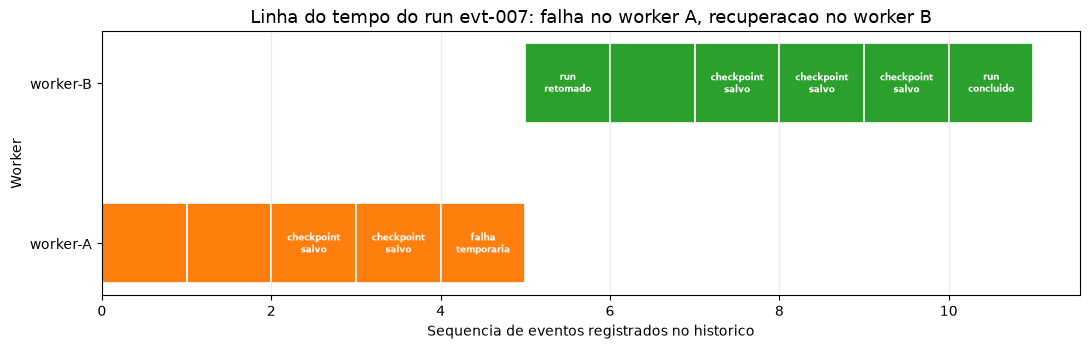

In [42]:
# Celula 5.7 - linha do tempo visual: worker A x worker B
fig, ax = plt.subplots(figsize=(11, 3.6))
mapa_cor = {"worker-A": COR["falha"], "worker-B": COR["recuperacao"]}
for i, linha in hist.iterrows():
    ax.barh(linha["worker"], 1, left=i, height=0.5,
            color=mapa_cor[linha["worker"]],
            edgecolor="white", linewidth=1.2)
    if linha["evento"] in ("checkpoint_salvo", "falha_temporaria", "run_concluido", "run_retomado"):
        ax.text(i + 0.5, linha["worker"], linha["evento"].replace("_", "\n"),
                ha="center", va="center", fontsize=6.5, color="white", fontweight="bold")

ax.set_title("Linha do tempo do run evt-007: falha no worker A, recuperacao no worker B", fontsize=13)
ax.set_xlabel("Sequencia de eventos registrados no historico")
ax.set_ylabel("Worker")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

> ### Observe
>
> - **O worker B nao continua da linha de codigo onde o A parou.** Ele recupera o ultimo
>   estado confirmado e **reinicia a etapa interrompida** inteira. Toda etapa precisa
>   tolerar ser executada de novo.
> - **A etapa de analise foi executada duas vezes; a API foi chamada uma vez.** O
>   `logical_llm_steps` do worker B e 1, e o `real_api_calls` e 0 - a diferenca esta em
>   `cache_hits`. Confundir os dois numeros levaria a concluir, erroneamente, que a
>   recuperacao foi gratuita em termos de trabalho.
> - **Se o cache estivesse vazio, a retomada custaria uma nova chamada.** O cache reduz o
>   custo da recuperacao; ele nao e a recuperacao. Quem sabe *onde retomar* e o
>   checkpoint - e essa informacao nao existe em lugar nenhum do cache.
> - Guardar o progresso em um dicionario do processo do worker funciona em todos os
>   testes locais e falha exatamente quando importa: quando o processo morre.


## Interpretacao - resposta a pergunta da turma

**Nao.** O segundo worker nao continua da linha de codigo em que o primeiro parou.

Ele recupera o **ultimo estado confirmado** (o checkpoint de `consultar_album`) e
**reinicia do comeco a etapa interrompida** (`analisar_colecao`). Isso acontece porque
nao ha como saber quanto da etapa interrompida chegou a ser executado - o processo pode
ter morrido em qualquer instrucao.

Duas consequencias praticas:

1. **Granularidade importa.** Etapas muito grandes desperdicam trabalho a cada retomada;
   etapas muito pequenas geram muitos checkpoints e sobrecarregam a persistencia.
2. **Reiniciar a etapa significa repetir o que ela faz** - inclusive os efeitos externos
   que ela ja tenha aplicado. Por isso checkpoint e idempotencia sao controles
   complementares, nao alternativos.

> ### Erro comum
>
> Guardar o progresso em um dicionario global do processo do worker e considerar o
> problema resolvido. Funciona perfeitamente nos testes locais, onde o processo nunca
> morre, e falha silenciosamente no primeiro deploy em producao - perdendo exatamente os
> runs que estavam em andamento.

> ### Relacao com o Pipeline Guardian e com producao
>
> No Pipeline Guardian, buscar os logs do pipeline e caro e lento. Se o agente falha ao
> chamar o modelo, refazer o download completo dos logs desperdica tempo e cota da API.
> Um checkpoint apos "coletar logs" faz a retomada custar apenas a analise.
>
> Em producao, o SQLite deste exemplo seria Postgres, DynamoDB ou o *checkpointer* de um
> framework de orquestracao. O conceito e o mesmo: o estado duravel vive **fora** do
> processo que executa, e qualquer worker consegue lê-lo.

---

# Atividade 6 - Estado enxuto, artefatos e memoria

## Conceito

Nem todo dado produzido pelo agente deve circular dentro do estado do grafo. Existe uma
tentacao natural - "vou guardar tudo no estado, assim fica disponivel" - que funciona bem
com dez runs e se torna um problema serio com dez mil.

O motivo e mecanico: o estado e **serializado e gravado a cada checkpoint**. Se ele carrega
500 KB de logs, cada checkpoint grava 500 KB. Com cinco checkpoints por run e mil runs por
dia, sao 2,5 GB por dia gravados e lidos sem necessidade.

A separacao util e em tres categorias.

### Estado do run

Contem apenas o necessario para **coordenar a execucao**:

- `event_id`;
- `album_id`;
- `status`;
- `risco`;
- etapa atual;
- `artifact_uri`;
- `memory_key`.

Se o dado nao ajuda a decidir o que fazer a seguir, ele provavelmente nao pertence ao estado.

### Artefatos

Conteudo **volumoso** gerado durante a execucao:

- logs completos;
- relatorios;
- arquivos de evidencia;
- resultados intermediarios extensos.

Artefatos vao para um armazenamento de objetos (S3, GCS, disco). O estado guarda apenas a
**URI**.

### Memoria

Conhecimento **reutilizavel entre execucoes**:

- padroes ja conhecidos;
- recomendacoes anteriores para o mesmo album;
- regras e informacoes recuperaveis por chave.

Memoria vive em um indice ou banco proprio. O estado guarda apenas a **chave**.

## Beneficios de guardar referencias em vez de conteudo

- **menos serializacao**: converter para JSON deixa de ser proporcional ao tamanho do log;
- **menor armazenamento de checkpoints**: cada checkpoint fica pequeno e barato;
- **retomada mais rapida**: recuperar o estado nao exige ler megabytes;
- **menor acoplamento**: o formato do relatorio pode mudar sem afetar o orquestrador;
- **melhor separacao de responsabilidades** entre execucao, artefato e memoria - cada um
  com seu ciclo de vida e sua politica de retencao.

## O que sera demonstrado

Construimos dois estados para o mesmo run:

1. um estado **pesado**, que carrega logs e o relatorio completo dentro de si;
2. um estado **enxuto**, que guarda apenas `artifact_uri` e `memory_key`.

Comparamos tamanho em bytes, tempo de serializacao, tempo de gravacao, tempo de leitura e
tamanho do checkpoint. O artefato completo e salvo em
`artifacts/agentes_complexos_escalaveis/`.

### Como a LLM participa desta atividade

Aqui a LLM real produz os quatro artefatos que o agente entrega: **resumo**,
**recomendacao**, **justificativa** e **lista de prioridades**. A resposta completa vai
para o disco como artefato JSON; o estado do run guarda apenas referencias.

No estado ficam somente: `status`, `etapa`, `response_id`, `artifact_uri`, `memory_key`,
resumo curto e tokens. **O prompt completo nao entra no estado** - ele e reconstruivel a
partir do perfil e nao precisa ser arrastado por todos os checkpoints.

### Esta e a atividade em que embeddings sao uteis

Embeddings aparecem aqui, e **somente aqui**, porque so aqui existe recuperacao
semantica: buscar uma recomendacao anterior parecida com o caso atual e usa-la como
contexto de uma nova chamada. Nas outras atividades o problema e concorrencia, estado ou
idempotencia - nenhum deles melhora com vetores.

Se `OPENAI_EMBEDDING_MODEL` nao estiver configurado, a parte semantica e ignorada com um
aviso explicito e a chamada principal de LLM continua. Um modelo de chat **nunca** e
usado como substituto silencioso de um modelo de embedding: sao coisas diferentes, e
fingir o contrario produziria vetores sem significado geometrico.


> ### Pergunta para a turma
>
> **O agente precisa carregar novamente todos os logs para saber em qual etapa esta?**

In [43]:
# Celula 6.1 - conteudo volumoso que acompanha o run (logs simulados)
def gerar_logs(event_id: str, linhas: int = 600) -> list[str]:
    """Logs simulados, deterministicos, do processamento do album."""
    return [f"[{i:04d}] {event_id} figurinha={int(ruido(f'{event_id}:{i}') * 900):03d} "
            f"status={'repetida' if ruido(f'r{event_id}:{i}') > 0.7 else 'obtida'} "
            f"verificada em {0.001 * i:.3f}s"
            for i in range(linhas)]


print("Gerador de logs pronto. O conteudo pesado nao entra no estado do run.")

Gerador de logs pronto. O conteudo pesado nao entra no estado do run.


In [44]:
# Celula 6.1b - a LLM real produz o conteudo do artefato
ev6 = Event("evt-042", "album-013")
perfil6 = perfil_do_evento(ev6.event_id, n_perfis=3)

marco_a6 = marco_llm()
resultado6 = await llm_gateway.generate(
    activity_id="atividade_06_estado",
    prompt_version="estado_v1",
    system_prompt=SYSTEM_PROMPT_AGENTE,
    user_prompt=montar_prompt_usuario(perfil6),
    cache_key_data=perfil6.como_dados(),
    event_id=ev6.event_id,
    run_id="run-estado-001",
)
recomendacao6 = resultado6.parsed or {}

print(f"Perfil analisado: {perfil6.perfil_id} ({perfil6.descricao})")
print(f"Origem: {'cache (' + resultado6.cache_source + ')' if resultado6.cache_hit else 'requisicao real'}"
      f" | latencia {resultado6.latency_seconds:.2f}s"
      f" | tokens {resultado6.input_tokens}/{resultado6.output_tokens}")
print()
print("Resposta estruturada do agente:")
print(json.dumps(recomendacao6, ensure_ascii=False, indent=2))

Perfil analisado: muitas_repetidas (Muitas figurinhas repetidas)
Origem: requisicao real | latencia 2.11s | tokens 415/148

Resposta estruturada do agente:
{
  "resumo": "Album com muitos repetidos e faltando 240 figurinhas, especialmente meio-campistas e escudos.",
  "figurinhas_prioritarias": [
    "meio-campistas",
    "escudos"
  ],
  "acao_recomendada": "Priorizar trocas oferecendo repetidas em grande volume e buscar pacotes/feiras focadas em meio-campistas e escudos.",
  "justificativa": "Alto número de repetidas (310) e grande disponibilidade para troca (260) indicam que trocar intensivamente por categorias com maior ausência é a ação mais eficiente.",
  "confianca": 0.78
}


In [45]:
# Celula 6.2 - dois estados para o MESMO run: pesado e enxuto
# Conteudo volumoso: os logs simulados do processamento mais a resposta completa da LLM.
logs = gerar_logs(ev6.event_id)

diretorio_artefatos_run = BASE_ARTEFATOS / ev6.event_id
diretorio_artefatos_run.mkdir(parents=True, exist_ok=True)
caminho_artefato = diretorio_artefatos_run / "analise_llm.json"
caminho_artefato.write_text(json.dumps({
    "event_id": ev6.event_id,
    "perfil_id": perfil6.perfil_id,
    "model": resultado6.model,
    "response_id": resultado6.response_id,
    "prompt_version": "estado_v1",
    "recomendacao": recomendacao6,
    "texto_completo": resultado6.text,
    "logs": logs,
}, ensure_ascii=False), encoding="utf-8")

memory_key = f"album:{perfil6.perfil_id}:recomendacao:estado_v1"

# ERRADO: tudo dentro do estado, inclusive o que so serve para auditoria.
estado_pesado = {
    "event_id": ev6.event_id,
    "album_id": ev6.album_id,
    "status": "analisado",
    "etapa_atual": "gerar_recomendacao",
    "logs_completos": logs,
    "resposta_llm_completa": resultado6.text,
    "recomendacao_completa": recomendacao6,
    "prompt_completo": montar_prompt_usuario(perfil6),      # nao deveria estar aqui
    "recomendacoes_anteriores": [resultado6.text for _ in range(5)],
}

# CERTO: o estado carrega referencias e o minimo necessario para decidir o proximo passo.
estado_enxuto = {
    "status": "analisado",
    "etapa": "gerar_recomendacao",
    "response_id": resultado6.response_id,
    "artifact_uri": str(caminho_artefato),
    "memory_key": memory_key,
    "resumo_curto": (recomendacao6.get("resumo", ""))[:160],
    "tokens_entrada": resultado6.input_tokens,
    "tokens_saida": resultado6.output_tokens,
}

print("Estado enxuto completo:")
print(json.dumps(estado_enxuto, ensure_ascii=False, indent=2))
print("\nArtefato gravado em:", caminho_artefato)
print("O prompt completo NAO esta no estado: ele e reconstruivel a partir do perfil.")

Estado enxuto completo:
{
  "status": "analisado",
  "etapa": "gerar_recomendacao",
  "response_id": "resp_08423c082f2d8fed006a5daae1b104819580b9f886cedc2225",
  "artifact_uri": "artifacts/agentes_complexos_escalaveis_llm/evt-042/analise_llm.json",
  "memory_key": "album:muitas_repetidas:recomendacao:estado_v1",
  "resumo_curto": "Album com muitos repetidos e faltando 240 figurinhas, especialmente meio-campistas e escudos.",
  "tokens_entrada": 415,
  "tokens_saida": 148
}

Artefato gravado em: artifacts/agentes_complexos_escalaveis_llm/evt-042/analise_llm.json
O prompt completo NAO esta no estado: ele e reconstruivel a partir do perfil.


In [46]:
# Celula 6.3 - medicao: serializacao, gravacao, leitura e tamanho do checkpoint
def medir_estado(nome: str, estado: dict) -> dict:
    with Cronometro() as c_ser:
        texto = json.dumps(estado)
    caminho = BASE_ARTEFATOS / f"checkpoint_{nome}.json"

    with Cronometro() as c_grav:
        caminho.write_text(texto, encoding="utf-8")

    with Cronometro() as c_leit:
        lido = json.loads(caminho.read_text(encoding="utf-8"))

    return {
        "estado": nome,
        "tamanho_bytes": len(texto.encode("utf-8")),
        "tamanho_kb": round(len(texto.encode("utf-8")) / 1024, 1),
        "serializacao_ms": round(c_ser.duracao * 1000, 3),
        "gravacao_ms": round(c_grav.duracao * 1000, 3),
        "leitura_ms": round(c_leit.duracao * 1000, 3),
        "checkpoint_bytes": caminho.stat().st_size,
        "chaves": len(lido),
    }


df_estado = pd.DataFrame([medir_estado("pesado", estado_pesado),
                          medir_estado("enxuto", estado_enxuto)])
df_estado["reducao_x"] = (df_estado["tamanho_bytes"].iloc[0] / df_estado["tamanho_bytes"]).round(1)
df_estado

,estado,tamanho_bytes,tamanho_kb,serializacao_ms,gravacao_ms,leitura_ms,checkpoint_bytes,chaves,reducao_x
0,pesado,44985,43.9,0.321,1.267,0.327,44985,9,1.0
1,enxuto,435,0.4,0.031,0.196,0.070,435,8,103.4


In [47]:
# Celula 6.4 - custo acumulado dos checkpoints em um cenario realista
CHECKPOINTS_POR_RUN, RUNS_POR_DIA = 5, 1000
pesado_b = int(df_estado.loc[df_estado["estado"] == "pesado", "tamanho_bytes"].iloc[0])
enxuto_b = int(df_estado.loc[df_estado["estado"] == "enxuto", "tamanho_bytes"].iloc[0])

projecao = pd.DataFrame([
    {"estado": "pesado", "bytes_por_checkpoint": pesado_b,
     "mb_por_run": round(pesado_b * CHECKPOINTS_POR_RUN / 1024 / 1024, 2),
     "gb_por_dia_1000_runs": round(pesado_b * CHECKPOINTS_POR_RUN * RUNS_POR_DIA / 1024**3, 2)},
    {"estado": "enxuto", "bytes_por_checkpoint": enxuto_b,
     "mb_por_run": round(enxuto_b * CHECKPOINTS_POR_RUN / 1024 / 1024, 4),
     "gb_por_dia_1000_runs": round(enxuto_b * CHECKPOINTS_POR_RUN * RUNS_POR_DIA / 1024**3, 4)},
])
print(f"Projecao com {CHECKPOINTS_POR_RUN} checkpoints por run e {RUNS_POR_DIA} runs por dia:")
projecao

Projecao com 5 checkpoints por run e 1000 runs por dia:


,estado,bytes_por_checkpoint,mb_por_run,gb_por_dia_1000_runs
0,pesado,44985,0.2100,0.210
1,enxuto,435,0.0021,0.002


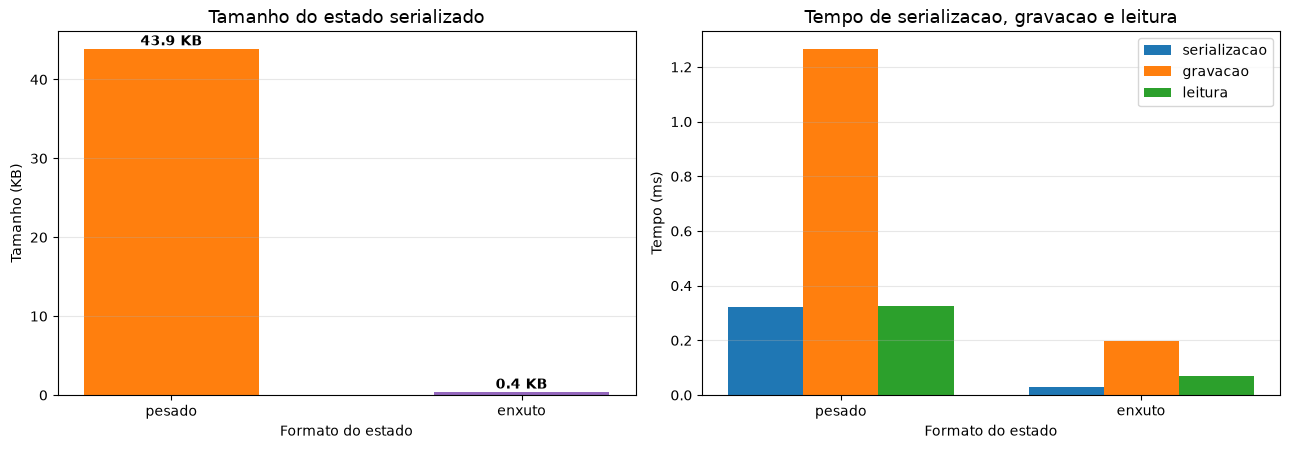

In [48]:
# Celula 6.5 - grafico comparativo: tamanho e tempos
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
cores = [COR["falha"], COR["persistencia"]]

axes[0].bar(df_estado["estado"], df_estado["tamanho_kb"], color=cores, width=0.5)
for i, v in enumerate(df_estado["tamanho_kb"]):
    axes[0].text(i, v, f"{v} KB", ha="center", va="bottom", fontweight="bold")
axes[0].set_title("Tamanho do estado serializado", fontsize=13)
axes[0].set_ylabel("Tamanho (KB)")
axes[0].set_xlabel("Formato do estado")
axes[0].grid(axis="y", alpha=0.3)

largura = 0.25
x = range(len(df_estado))
for i, (col, rotulo) in enumerate([("serializacao_ms", "serializacao"),
                                   ("gravacao_ms", "gravacao"),
                                   ("leitura_ms", "leitura")]):
    axes[1].bar([xi + i * largura for xi in x], df_estado[col], width=largura, label=rotulo)
axes[1].set_xticks([xi + largura for xi in x])
axes[1].set_xticklabels(df_estado["estado"])
axes[1].set_title("Tempo de serializacao, gravacao e leitura", fontsize=13)
axes[1].set_ylabel("Tempo (ms)")
axes[1].set_xlabel("Formato do estado")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Memoria semantica com embeddings

O passo a seguir so faz sentido porque existe uma pergunta genuinamente semantica:
*"ja analisamos antes um album parecido com este?"*. Similaridade textual exata nao
responde isso; comparacao vetorial responde.

O fluxo e: gerar embeddings das recomendacoes anteriores, indexar, buscar por
similaridade de cosseno o caso mais proximo do album atual, e usar essa memoria
recuperada como **contexto de uma nova chamada** ao modelo.

Os vetores ficam apenas no diretorio temporario do notebook.


In [49]:
# Celula 6.6 - memoria semantica: embeddings, cosseno e recuperacao
def similaridade_cosseno(a: list[float], b: list[float]) -> float:
    num = sum(x * y for x, y in zip(a, b))
    na = math.sqrt(sum(x * x for x in a))
    nb = math.sqrt(sum(y * y for y in b))
    return num / (na * nb) if na and nb else 0.0


memoria_ativa = bool(OPENAI_EMBEDDING_MODEL)

if not memoria_ativa:
    print("OPENAI_EMBEDDING_MODEL nao configurado.")
    print("A parte de recuperacao semantica foi IGNORADA (veja a celula Markdown abaixo).")
    print("A chamada principal de LLM desta atividade foi executada normalmente.")
else:
    # 1) recomendacoes anteriores: usamos os perfis ja analisados como historico.
    marco_emb = marco_llm()
    historico = []
    for p in PERFIS_ALBUM[:3]:
        r = await llm_gateway.generate(
            activity_id="atividade_06_estado", prompt_version="estado_v1",
            system_prompt=SYSTEM_PROMPT_AGENTE,
            user_prompt=montar_prompt_usuario(p), cache_key_data=p.como_dados(),
            event_id=f"hist-{p.perfil_id}", run_id="run-memoria")
        rec = r.parsed or {}
        historico.append({
            "memory_key": f"album:{p.perfil_id}:recomendacao:estado_v1",
            "perfil_id": p.perfil_id,
            "texto": f"{rec.get('resumo','')} {rec.get('acao_recomendada','')}".strip(),
        })

    # 2) embeddings do historico + da consulta atual (uma unica requisicao)
    consulta = (f"Album com {perfil6.faltantes} faltantes, {perfil6.repetidas} repetidas, "
                f"ausencias em {', '.join(perfil6.categorias_com_maior_ausencia)}.")
    vetores = await llm_gateway.embed([h["texto"] for h in historico] + [consulta])
    vetor_consulta = vetores[-1]

    # 3) os vetores ficam SOMENTE no diretorio temporario do notebook
    caminho_vetores = BASE_ARTEFATOS / "memoria_vetorial.json"
    caminho_vetores.write_text(json.dumps(
        [{"memory_key": h["memory_key"], "vetor": v}
         for h, v in zip(historico, vetores[:-1])]), encoding="utf-8")

    # 4) busca por similaridade de cosseno
    ranking = sorted(
        ({"memory_key": h["memory_key"], "perfil_id": h["perfil_id"],
          "similaridade": round(similaridade_cosseno(vetor_consulta, v), 4),
          "trecho": h["texto"][:70] + "..."}
         for h, v in zip(historico, vetores[:-1])),
        key=lambda d: d["similaridade"], reverse=True)

    print(f"Modelo de embedding: {OPENAI_EMBEDDING_MODEL} | dimensoes: {len(vetor_consulta)}")
    print(f"Requisicoes de embedding: {llm_gateway.embedding_calls} | "
          f"tokens: {llm_gateway.embedding_tokens}")
    print(f"Vetores salvos em: {caminho_vetores}")
    print("\nRanking por similaridade de cosseno:")
    display(pd.DataFrame(ranking))

    # 5) a memoria recuperada vira CONTEXTO de uma nova chamada
    recuperada = ranking[0]
    prompt_com_memoria = (
        montar_prompt_usuario(perfil6)
        + "\n\nMemoria recuperada de um album semelhante (use apenas como referencia, "
          "nao copie dados que nao estejam no album atual):\n"
        + f"- {recuperada['memory_key']}: {recuperada['trecho']}"
    )
    resultado_memoria = await llm_gateway.generate(
        activity_id="atividade_06_estado", prompt_version="estado_memoria_v1",
        system_prompt=SYSTEM_PROMPT_AGENTE, user_prompt=prompt_com_memoria,
        cache_key_data={"album": perfil6.como_dados(),
                        "memoria": recuperada["memory_key"]},
        event_id=ev6.event_id, run_id="run-estado-002")

    print(f"\nNova chamada com memoria recuperada ({recuperada['memory_key']}):")
    print(f"  origem: {'cache' if resultado_memoria.cache_hit else 'requisicao real'} | "
          f"latencia {resultado_memoria.latency_seconds:.2f}s | "
          f"tokens {resultado_memoria.input_tokens}/{resultado_memoria.output_tokens}")
    print("  resumo:", (resultado_memoria.parsed or {}).get("resumo", "")[:200])

Modelo de embedding: text-embedding-3-small | dimensoes: 1536
Requisicoes de embedding: 1 | tokens: 191
Vetores salvos em: artifacts/agentes_complexos_escalaveis_llm/memoria_vetorial.json

Ranking por similaridade de cosseno:


,memory_key,perfil_id,similaridade,trecho
0,album:muitas_repetidas:recomendacao:estado_v1,muitas_repetidas,0.6883,Album com muitos repetidos e faltando 240 figu...
1,album:quase_completo:recomendacao:estado_v1,quase_completo,0.6855,"Album quase completo, faltam 22 figurinhas com..."
2,album:recem_iniciado:recomendacao:estado_v1,recem_iniciado,0.4563,Album no inicio da colecao com muitas figurinh...



Nova chamada com memoria recuperada (album:muitas_repetidas:recomendacao:estado_v1):
  origem: requisicao real | latencia 2.66s | tokens 472/155
  resumo: Album com elevado numero de repetidas e muitas faltantes, especialmente em meio-campistas e escudos.


> ### Se `OPENAI_EMBEDDING_MODEL` nao estiver configurado
>
> A celula acima detecta a ausencia da variavel, imprime um aviso e **segue sem falhar**.
> A chamada principal de LLM desta atividade continua sendo executada normalmente - o
> que se perde e apenas a demonstracao de recuperacao semantica.
>
> O notebook **nao** substitui o modelo de embedding por um modelo de chat nesse caso.
> Pedir a um modelo de chat que "gere um vetor" produz numeros sem as propriedades
> geometricas que a similaridade de cosseno pressupoe: o resultado pareceria funcionar e
> estaria errado. Quando a ferramenta certa nao esta disponivel, a resposta honesta e
> dizer que a etapa foi ignorada.


> ### Observe
>
> - **O estado enxuto e ordens de grandeza menor** e descreve exatamente o mesmo run. O
>   `response_id` permite auditar a chamada; o `artifact_uri` permite recuperar o
>   conteudo; o `memory_key` permite reencontrar a analise semanticamente. Nada se
>   perdeu - tudo foi movido para o lugar certo.
> - **O prompt completo ficou fora do estado.** Ele e derivavel do perfil, e arrasta-lo
>   por cinco checkpoints por run multiplica o custo de serializacao sem beneficio.
> - **Embeddings resolvem um problema especifico.** Eles nao aceleram o fluxo, nao
>   controlam concorrencia e nao substituem checkpoint. Aparecem nesta atividade porque
>   aqui a pergunta e "o que ja vimos parecido com isto?" - e essa e a unica pergunta
>   que vetores respondem bem.
> - Cada checkpoint com o estado pesado regrava os logs por inteiro. Com cinco
>   checkpoints por run e mil runs por dia, a diferenca deixa de ser detalhe de
>   implementacao e vira conta de armazenamento.


## Interpretacao - resposta a pergunta da turma

**Nao.** Para saber em qual etapa esta, o agente precisa de `status` e `etapa_atual` -
poucas dezenas de bytes. Carregar 600 linhas de log para descobrir isso e desperdicio puro.

Duas ideias para levar:

- **O estado operacional nao deve virar deposito de todos os dados produzidos.** Ele e um
  instrumento de coordenacao, nao um arquivo morto.
- **O checkpoint preserva progresso, nao conteudo.** Ele precisa responder "ate onde
  chegamos e com quais decisoes", nao "tudo o que foi gerado no caminho".

> ### Relacao com o Pipeline Guardian e com producao
>
> O diagnostico do Pipeline Guardian produz logs de build que podem ter megabytes. Se esses
> logs entrarem no estado do run, cada checkpoint os regrava por inteiro.
>
> O padrao de producao e o *claim check*: grave o conteudo grande em um armazenamento de
> objetos e passe adiante somente o ticket (a URI). Vale tambem para o payload que vai ao
> modelo - se o estado carrega tudo, alguem eventualmente vai mandar tudo para o prompt, e
> ai o desperdicio deixa de ser de disco e passa a ser de tokens.

---

# Atividade 7 - Retentativas seguras, backoff e idempotencia

## Conceito

Falhas transitorias sao inevitaveis: rede oscila, servico reinicia, cota estoura por um
instante. Quatro controles trabalham juntos para lidar com elas sem causar danos.

### Timeout

Define **quanto tempo uma chamada pode permanecer aguardando** antes de ser considerada
perdida. Sem timeout, um run pode ficar preso indefinidamente segurando um worker.

O timeout tem um efeito colateral importante: ele cria **incerteza**. Quando ele dispara,
voce nao sabe se a operacao falhou ou se apenas a resposta se perdeu.

### Retry limitado

Permite repetir uma operacao, mas **somente ate um numero maximo** de tentativas. O limite
existe para que uma falha permanente nao gere retentativas infinitas - que amplificam a
carga exatamente quando o sistema esta em dificuldade.

### Backoff

**Aumenta o intervalo entre tentativas**, dando tempo para o servico se recuperar.

Exemplo didatico: `0,1 s -> 0,2 s -> 0,4 s`

Os valores sao reduzidos para a demonstracao; em producao, costumam ser segundos ou
minutos, com um componente aleatorio (*jitter*) para evitar que todos os clientes tentem
de novo no mesmo instante.

### Idempotencia

Permite **repetir uma requisicao sem repetir o efeito externo**. E o controle que torna o
retry seguro.

## O problema classico

1. o agente registra uma recomendacao no sistema externo;
2. a gravacao e **concluida com sucesso** do lado do servidor;
3. ocorre um **timeout antes de a resposta chegar** ao agente;
4. o agente **nao sabe** que a acao aconteceu;
5. a tentativa e repetida, como manda a politica de retry;
6. **sem idempotencia, uma segunda acao e criada.**

O resultado sao duas recomendacoes para o mesmo evento. Em um sistema de figurinhas isso e
um incomodo; em um sistema de pagamentos, e uma cobranca duplicada.

A solucao e uma **chave de idempotencia**: um identificador estavel, derivado do evento e
da operacao, que o servidor usa para reconhecer "isto eu ja fiz".

```
f"{event_id}:registrar_recomendacao:v1"
```

Note as tres partes: o **evento** (o que), a **operacao** (qual acao) e a **versao** (para
permitir mudancas futuras de semantica sem colidir com chaves antigas).

## O que sera demonstrado

Dois cenarios com o mesmo roteiro de falha - timeout **depois** da gravacao:

- **sem idempotencia**: o retry cria uma segunda acao;
- **com idempotencia**: uma restricao `UNIQUE` no SQLite faz a persistencia devolver a
  acao existente, e apenas uma permanece registrada.

Registramos para cada tentativa: numero da tentativa, atraso aplicado (backoff),
`idempotency_key`, `action_id` e resultado.

### Como a LLM participa desta atividade

A LLM real gera a recomendacao que sera **registrada como acao externa**. Isso coloca em
cena dois mecanismos de retry que sao frequentemente confundidos:

| | Retry da LLM | Retry do efeito externo |
| --- | --- | --- |
| Onde vive | dentro do `LLMGateway` | na camada de registro da acao |
| O que protege | contra falha de rede/cota | contra acao duplicada |
| Como | backoff 0,5s -> 1s -> 2s | mesma `idempotency_key` |
| Se repetir | custa tokens | **cria uma segunda acao** |

O ponto central: **uma nova resposta textual do modelo nao deve criar uma segunda acao
para a mesma operacao logica**. O modelo e nao-deterministico; a chave de idempotencia
nao pode depender do texto que ele produziu.

A chave usada e:

```python
f"{event_id}:registrar_recomendacao:{prompt_version}"
```

Ela inclui a versao do prompt de proposito: mudar a versao do prompt e, deliberadamente,
uma operacao logica nova. Ela **nao** inclui o `response_id` nem o texto - se incluisse,
cada tentativa geraria uma chave diferente e a protecao desapareceria.


> ### Pergunta para a turma
>
> **Qual operacao pode se repetir e qual efeito deve acontecer apenas uma vez?**

In [50]:
# Celula 7.1 - banco de acoes com e sem restricao de unicidade
CAMINHO_ACOES = BASE_ARTEFATOS / "copafigurinhas_acoes.sqlite"
if CAMINHO_ACOES.exists():
    CAMINHO_ACOES.unlink()
con_acoes = sqlite3.connect(CAMINHO_ACOES)
con_acoes.executescript("""
    -- Sem protecao: qualquer insercao cria uma nova acao.
    CREATE TABLE acoes_sem_idempotencia (
        action_id       TEXT PRIMARY KEY,
        event_id        TEXT NOT NULL,
        recomendacao    TEXT NOT NULL,
        criado_em       REAL
    );
    -- Com protecao: a chave de idempotencia e UNIQUE.
    CREATE TABLE acoes_com_idempotencia (
        action_id       TEXT PRIMARY KEY,
        idempotency_key TEXT NOT NULL UNIQUE,
        event_id        TEXT NOT NULL,
        recomendacao    TEXT NOT NULL,
        criado_em       REAL
    );
""")
con_acoes.commit()
print("Tabelas de acoes criadas em:", CAMINHO_ACOES)

Tabelas de acoes criadas em: artifacts/agentes_complexos_escalaveis_llm/copafigurinhas_acoes.sqlite


In [51]:
# Celula 7.2 - a operacao externa: grava e SO DEPOIS estoura timeout (deterministico)
class TimeoutSimulado(TimeoutError):
    """A gravacao aconteceu; a resposta se perdeu. O cliente nao sabe o que ocorreu."""


CONTADOR_ACOES = {"n": 0}


def _novo_action_id() -> str:
    CONTADOR_ACOES["n"] += 1
    return f"act-{CONTADOR_ACOES['n']:04d}"


async def registrar_sem_idempotencia(ev: Event, recomendacao: str, tentativa: int) -> str:
    await asyncio.sleep(TIME_SCALE)
    action_id = _novo_action_id()
    con_acoes.execute(
        "INSERT INTO acoes_sem_idempotencia (action_id, event_id, recomendacao, criado_em)"
        " VALUES (?,?,?,?)", (action_id, ev.event_id, recomendacao, time.time()))
    con_acoes.commit()
    if tentativa == 1:                       # timeout DEPOIS da gravacao
        raise TimeoutSimulado("resposta perdida apos a gravacao")
    return action_id


async def registrar_com_idempotencia(ev: Event, recomendacao: str, tentativa: int) -> tuple[str, str]:
    """Devolve (action_id, situacao) onde situacao e 'criada' ou 'ja_existia'.

    A chave NAO depende do texto gerado pelo modelo nem do response_id: se dependesse,
    cada nova resposta criaria uma acao nova - exatamente o que queremos evitar.
    """
    chave = f"{ev.event_id}:registrar_recomendacao:{PROMPT_VERSION_A7}"
    await asyncio.sleep(TIME_SCALE)
    existente = con_acoes.execute(
        "SELECT action_id FROM acoes_com_idempotencia WHERE idempotency_key=?",
        (chave,)).fetchone()
    if existente:
        return existente[0], "ja_existia"    # a persistencia devolve a acao existente
    try:
        action_id = _novo_action_id()
        con_acoes.execute(
            "INSERT INTO acoes_com_idempotencia"
            " (action_id, idempotency_key, event_id, recomendacao, criado_em) VALUES (?,?,?,?,?)",
            (action_id, chave, ev.event_id, recomendacao, time.time()))
        con_acoes.commit()
    except sqlite3.IntegrityError:           # corrida entre dois workers: UNIQUE protege
        action_id = con_acoes.execute(
            "SELECT action_id FROM acoes_com_idempotencia WHERE idempotency_key=?",
            (chave,)).fetchone()[0]
        return action_id, "ja_existia"
    if tentativa == 1:                       # timeout DEPOIS da gravacao
        raise TimeoutSimulado("resposta perdida apos a gravacao")
    return action_id, "criada"


print("Operacoes externas simuladas definidas (timeout sempre apos a gravacao).")

Operacoes externas simuladas definidas (timeout sempre apos a gravacao).


In [52]:
# Celula 7.3 - a LLM gera a recomendacao; a acao externa e protegida por idempotencia
MAX_TENTATIVAS, BACKOFF_BASE = 3, 0.1
ev7 = Event("evt-013", "album-034")
PROMPT_VERSION_A7 = "idempotencia_v1"
perfil7 = perfil_do_evento(ev7.event_id, n_perfis=1)

# 1) A LLM gera a recomendacao (com retry tecnico proprio, dentro do gateway).
marco_a7 = marco_llm()
resultado7 = await llm_gateway.generate(
    activity_id="atividade_07_idempotencia",
    prompt_version=PROMPT_VERSION_A7,
    system_prompt=SYSTEM_PROMPT_AGENTE,
    user_prompt=montar_prompt_usuario(perfil7),
    cache_key_data=perfil7.como_dados(),
    event_id=ev7.event_id,
    run_id="run-idem-001",
)
llm_a7 = metricas_llm_desde(marco_a7)
recomendacao_7 = (resultado7.parsed or {}).get("acao_recomendada", "recomendacao indisponivel")

print("Recomendacao gerada pela LLM:")
print(" ", recomendacao_7[:180])
print(f"  response_id={resultado7.response_id} | "
      f"origem={'cache' if resultado7.cache_hit else 'API real'} | "
      f"tentativas={resultado7.attempts} | "
      f"tokens={resultado7.input_tokens}/{resultado7.output_tokens}")
print()

# 2) O registro da acao: a MESMA idempotency_key em todas as tentativas.
IDEMPOTENCY_KEY_A7 = f"{ev7.event_id}:registrar_recomendacao:{PROMPT_VERSION_A7}"
registro_tentativas: list[dict] = []


async def com_retry(cenario: str, operacao) -> None:
    for tentativa in range(1, MAX_TENTATIVAS + 1):
        atraso = 0.0 if tentativa == 1 else BACKOFF_BASE * (2 ** (tentativa - 2))
        if atraso:
            await asyncio.sleep(atraso)
        usa_chave = cenario.startswith("com")
        chave = IDEMPOTENCY_KEY_A7 if usa_chave else "(nao usa chave)"
        try:
            resultado = await operacao(ev7, recomendacao_7, tentativa)
            action_id, situacao = resultado if isinstance(resultado, tuple) else (resultado, "criada")
            registro_tentativas.append({
                "cenario": cenario, "tentativa": tentativa, "atraso_s": round(atraso, 3),
                "idempotency_key": chave, "action_id": action_id,
                "response_id": resultado7.response_id,
                "cache_hit": resultado7.cache_hit,
                "tokens": resultado7.input_tokens + resultado7.output_tokens,
                "resultado": f"sucesso ({situacao})"})
            return
        except TimeoutSimulado as exc:
            registro_tentativas.append({
                "cenario": cenario, "tentativa": tentativa, "atraso_s": round(atraso, 3),
                "idempotency_key": chave, "action_id": "desconhecido",
                "response_id": resultado7.response_id,
                "cache_hit": resultado7.cache_hit,
                "tokens": resultado7.input_tokens + resultado7.output_tokens,
                "resultado": f"timeout: {exc}"})


await com_retry("sem idempotencia", registrar_sem_idempotencia)
await com_retry("com idempotencia", registrar_com_idempotencia)

display(pd.DataFrame(registro_tentativas))
print(f"Retries tecnicos da LLM nesta atividade: {llm_a7['llm_retries']} | "
      f"chamadas reais: {llm_a7['real_api_calls']} | cache hits: {llm_a7['cache_hits']}")

Recomendacao gerada pela LLM:
  Priorizar troca das 40 disponiveis focando nas goleiros reservas e nas raras; listar essas figurinhas ao negociar.
  response_id=resp_0599d62b30024feb006a5daaef55e8819092a92289de25afe1 | origem=API real | tentativas=1 | tokens=409/151



,cenario,tentativa,atraso_s,idempotency_key,action_id,response_id,cache_hit,tokens,resultado
0,sem idempotencia,1,0.0,(nao usa chave),desconhecido,resp_0599d62b30024feb006a5daaef55e8819092a9228...,False,560,timeout: resposta perdida apos a gravacao
1,sem idempotencia,2,0.1,(nao usa chave),act-0002,resp_0599d62b30024feb006a5daaef55e8819092a9228...,False,560,sucesso (criada)
2,com idempotencia,1,0.0,evt-013:registrar_recomendacao:idempotencia_v1,desconhecido,resp_0599d62b30024feb006a5daaef55e8819092a9228...,False,560,timeout: resposta perdida apos a gravacao
3,com idempotencia,2,0.1,evt-013:registrar_recomendacao:idempotencia_v1,act-0003,resp_0599d62b30024feb006a5daaef55e8819092a9228...,False,560,sucesso (ja_existia)


Retries tecnicos da LLM nesta atividade: 0 | chamadas reais: 1 | cache hits: 0


In [53]:
# Celula 7.4 - quantas acoes existem de fato em cada cenario
acoes_sem = pd.read_sql_query(
    "SELECT action_id, event_id FROM acoes_sem_idempotencia", con_acoes)
acoes_com = pd.read_sql_query(
    "SELECT action_id, idempotency_key, event_id FROM acoes_com_idempotencia", con_acoes)

print("Acoes registradas SEM idempotencia:")
display(acoes_sem)
print("Acoes registradas COM idempotencia:")
display(acoes_com)

comparacao_idem = pd.DataFrame([
    {"cenario": "sem idempotencia", "tentativas_tecnicas": MAX_TENTATIVAS,
     "acoes_registradas": len(acoes_sem), "duplicacoes": max(0, len(acoes_sem) - 1),
     "efeito_externo_correto": len(acoes_sem) == 1},
    {"cenario": "com idempotencia", "tentativas_tecnicas": MAX_TENTATIVAS,
     "acoes_registradas": len(acoes_com), "duplicacoes": max(0, len(acoes_com) - 1),
     "efeito_externo_correto": len(acoes_com) == 1},
])
comparacao_idem

Acoes registradas SEM idempotencia:


,action_id,event_id
0,act-0001,evt-013
1,act-0002,evt-013


Acoes registradas COM idempotencia:


,action_id,idempotency_key,event_id
0,act-0003,evt-013:registrar_recomendacao:idempotencia_v1,evt-013


,cenario,tentativas_tecnicas,acoes_registradas,duplicacoes,efeito_externo_correto
0,sem idempotencia,3,2,1,False
1,com idempotencia,3,1,0,True


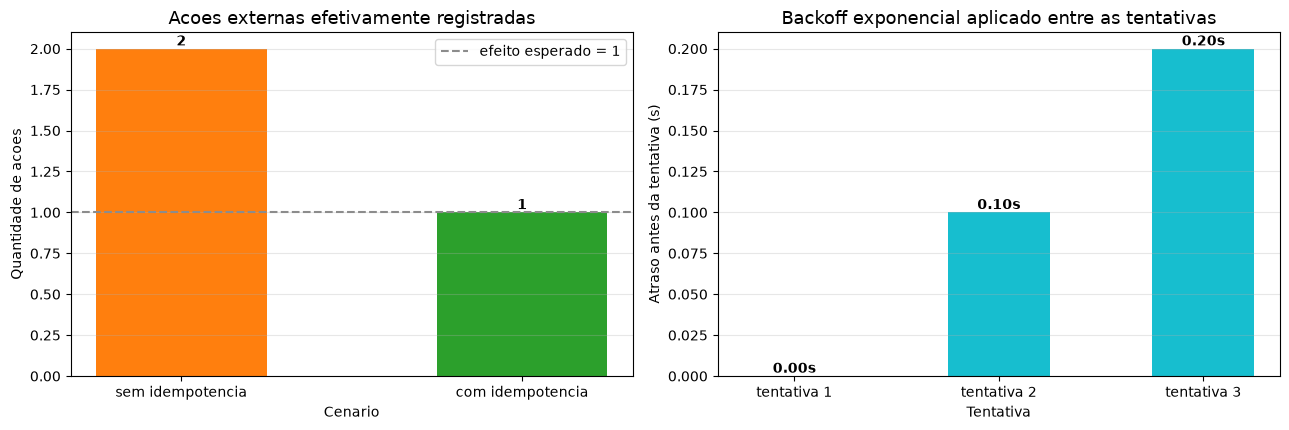

In [54]:
# Celula 7.5 - grafico: tentativas versus efeitos externos produzidos
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

rot = comparacao_idem["cenario"]
axes[0].bar(rot, comparacao_idem["acoes_registradas"],
            color=[COR["falha"], COR["recuperacao"]], width=0.5)
axes[0].axhline(1, linestyle="--", color=COR["neutro"], label="efeito esperado = 1")
for i, v in enumerate(comparacao_idem["acoes_registradas"]):
    axes[0].text(i, v, str(v), ha="center", va="bottom", fontweight="bold")
axes[0].set_title("Acoes externas efetivamente registradas", fontsize=13)
axes[0].set_ylabel("Quantidade de acoes")
axes[0].set_xlabel("Cenario")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

atrasos = [0.0] + [BACKOFF_BASE * (2 ** i) for i in range(MAX_TENTATIVAS - 1)]
axes[1].bar([f"tentativa {i+1}" for i in range(MAX_TENTATIVAS)], atrasos,
            color=COR["controle"], width=0.5)
for i, v in enumerate(atrasos):
    axes[1].text(i, v, f"{v:.2f}s", ha="center", va="bottom", fontweight="bold")
axes[1].set_title("Backoff exponencial aplicado entre as tentativas", fontsize=13)
axes[1].set_ylabel("Atraso antes da tentativa (s)")
axes[1].set_xlabel("Tentativa")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

> ### Observe
>
> - **Os dois cenarios tiveram o mesmo numero de tentativas.** O retry funcionou igual; o
>   que mudou foi o efeito. Sem idempotencia, cada tentativa criou uma `action_id` nova.
> - **O retry da LLM e o retry da acao sao independentes.** O gateway pode ter repetido a
>   chamada por um erro de rede sem que isso crie qualquer acao; a camada de registro
>   pode repetir a gravacao sem chamar o modelo de novo. Unificar os dois em um unico
>   contador de tentativas apaga essa distincao.
> - **A chave nao depende da resposta.** Se ela incluisse o `response_id` ou o texto,
>   cada tentativa geraria uma chave diferente - e a protecao existiria apenas no nome.
>   O mesmo vale para `uuid4()` gerado na hora da chamada: parece correto e nao protege
>   nada.
> - A chave inclui `prompt_version` porque mudar o prompt e uma decisao deliberada de
>   produzir uma nova recomendacao - uma operacao logica genuinamente diferente.


## Interpretacao - resposta a pergunta da turma

- **A tentativa tecnica pode se repetir.** Chamar de novo a API, reexecutar a etapa,
  reprocessar o evento: tudo isso e esperado e saudavel.
- **O efeito externo deve acontecer uma unica vez.** Registrar a recomendacao, enviar a
  notificacao, aplicar a cobranca: isso deve ser protegido por uma chave estavel.

A regra pratica: para toda operacao que **altera algo fora do agente**, pergunte "qual e a
chave que identifica esta acao de forma unica e reproduzivel?". Se nao houver resposta,
ainda nao da para ligar o retry com seguranca.

> ### Erro comum
>
> Gerar a chave de idempotencia com `uuid4()` no momento da chamada. Cada tentativa produz
> uma chave diferente, e a protecao deixa de existir - com a agravante de que o codigo
> *parece* correto. A chave precisa ser **derivada do evento e da operacao**, para que a
> segunda tentativa produza exatamente a mesma chave da primeira.

> ### Relacao com o Pipeline Guardian e com producao
>
> Quando o Pipeline Guardian comenta o diagnostico em um pull request, um timeout na API do
> GitHub seguido de retry produziria dois comentarios identicos - ruido visivel para toda a
> equipe. Uma chave como `f"{run_id}:comentar_pr:v1"` resolve o problema.
>
> Em producao, esse controle aparece de duas formas: no cliente (verificar antes de agir) e
> no servidor (aceitar um header `Idempotency-Key`, como fazem gateways de pagamento). A
> versao mais robusta usa as duas, porque a restricao `UNIQUE` no banco e a unica que
> protege contra corrida entre workers simultaneos.

---

# Demonstracao integrada - Evoluindo o CopaFigurinhas

## Conceito

Esta secao reune todos os controles introduzidos nas atividades anteriores **sem alterar o
fluxo logico principal**. As cinco etapas do agente CopaFigurinhas continuam exatamente as
mesmas: validar, consultar album, analisar colecao, gerar recomendacao, registrar resultado.

O que muda de uma fase para a outra sao as **politicas de execucao**:

| Fase | O que muda | Controle adicionado |
| --- | --- | --- |
| 1. Baseline | um unico evento | nenhum |
| 2. Pico sem controle | 30 eventos de uma vez | nenhum |
| 3. Concorrencia controlada | 30 eventos, teto de 3 analises | semaforos independentes |
| 4. Falha temporaria | a analise falha na primeira tentativa | nenhum (mostra o estrago) |
| 5. Recuperacao segura | mesma falha, com protecao | retry + backoff + idempotencia |

Repare que nenhuma linha das funcoes `etapa_*` foi modificada entre as fases. Toda a
evolucao acontece **em volta** do fluxo.

### Como a LLM participa desta demonstracao

Todas as fases usam a LLM real, com um `prompt_version` exclusivo: **`demo_integrada_v1`**.
Como esse namespace comeca vazio, a fase 1 garante pelo menos uma chamada real; as fases
seguintes reaproveitam o cache dos mesmos perfis, o que mantem a demonstracao barata sem
esconder o custo - ele aparece separado na tabela.

| Fase | O que muda | Papel da LLM |
| --- | --- | --- |
| 1. Baseline | 1 evento, sem controle | primeira chamada real, popula o cache |
| 2. Pico sem controle | 30 eventos de uma vez | 30 etapas logicas, concorrencia real limitada mesmo assim |
| 3. Concorrencia controlada | semaforos | a espera pela LLM fica visivel |
| 4. Falha temporaria | falha apos a resposta | trabalho ja pago e perdido |
| 5. Recuperacao segura | retry + checkpoint + idempotencia | cache evita repagar; idempotencia evita duplicar |


> ### Pergunta para a turma
>
> Antes de executar: **entre a fase 4 e a fase 5, o que voce espera que aconteca com
> (a) o numero de runs concluidos, (b) o tempo total e (c) o numero de acoes duplicadas?**

In [55]:
# Celula I.1 - registro de acoes externas com e sem idempotencia
class RegistroAcoes:
    """Simula o sistema externo que recebe as recomendacoes do CopaFigurinhas."""

    def __init__(self):
        self.por_chave: dict[str, str] = {}
        self.insercoes: list[tuple[str, str]] = []   # toda gravacao fisica

    def registrar(self, event_id: str, usar_idempotencia: bool) -> tuple[str, bool]:
        chave = f"{event_id}:registrar_recomendacao:v1"
        if usar_idempotencia and chave in self.por_chave:
            return self.por_chave[chave], False      # devolve a acao existente
        action_id = f"act-{len(self.insercoes) + 1:04d}"
        self.insercoes.append((chave, action_id))
        if usar_idempotencia:
            self.por_chave[chave] = action_id
        return action_id, True

    @property
    def duplicacoes(self) -> int:
        chaves = [k for k, _ in self.insercoes]
        return len(chaves) - len(set(chaves))


async def registrar_com_politica(ev: Event, registro: RegistroAcoes, *,
                                 usar_idempotencia: bool, timeout_apos_gravacao: bool,
                                 max_tentativas: int, backoff_base: float) -> tuple[str, int]:
    """Registra a recomendacao aplicando timeout simulado, retry e backoff."""
    action_id, tentativa = "", 0
    for tentativa in range(1, max_tentativas + 1):
        if tentativa > 1:
            await asyncio.sleep(backoff_base * (2 ** (tentativa - 2)))
        action_id, _ = registro.registrar(ev.event_id, usar_idempotencia)
        if timeout_apos_gravacao and tentativa == 1:
            continue                                  # a resposta se perdeu: tenta de novo
        break
    return action_id, tentativa


print("Registro de acoes externas pronto.")

Registro de acoes externas pronto.


In [56]:
# Celula I.2 - executor de fase (reutiliza executar_run e as etapas ja definidas)
async def executar_fase(nome: str, eventos: list[Event], pol: Politicas, *,
                        usar_idempotencia: bool = False,
                        timeout_apos_gravacao: bool = False,
                        max_tentativas_acao: int = 1) -> tuple[ExecutionMetrics, RegistroAcoes]:
    registro = RegistroAcoes()
    med = Medidores()
    chegada = time.perf_counter()

    async def um_run(ev: Event) -> RunResult:
        r = await executar_run(ev, pol, med, chegada, worker="worker-integrado")
        if r.status == "concluido":
            r.action_id, _ = await registrar_com_politica(
                ev, registro, usar_idempotencia=usar_idempotencia,
                timeout_apos_gravacao=timeout_apos_gravacao,
                max_tentativas=max_tentativas_acao, backoff_base=pol.backoff_base)
        elif r.status == "erro":
            r.status = "falha_final"
        return r

    with Cronometro() as c:
        runs = list(await asyncio.gather(*[um_run(ev) for ev in eventos]))

    m = resumir(nome, runs, c.duracao,
                concorrencia_maxima=med.runs.maximo,
                duplicacoes=registro.duplicacoes)
    log.info("%-28s concluidos=%2d/%2d erros=%d dup=%d conc_max=%2d dur=%.3fs",
             nome, m.concluidos, m.recebidos, m.erros, m.duplicacoes,
             m.concorrencia_maxima, m.duracao_total)
    return m, registro


print("Executor de fase pronto.")

Executor de fase pronto.


In [57]:
# Celula I.3 - as cinco fases, todas com LLM real
PROMPT_VERSION_DEMO = "demo_integrada_v1"
FALHAS_INTEGRADAS = frozenset(f"evt-{i:03d}" for i in (3, 7, 11, 19, 23, 29))
eventos_int = gerar_eventos(30)
fases: list[ExecutionMetrics] = []
registros_fase: dict[str, RegistroAcoes] = {}
llm_por_fase: dict[str, dict] = {}


def _pol_demo(**kw) -> Politicas:
    return Politicas(activity_id="demonstracao_integrada",
                     prompt_version=PROMPT_VERSION_DEMO, n_perfis=4, **kw)


async def executar_fase_medida(nome, eventos, pol, **kw):
    """Envolve executar_fase capturando os contadores de LLM da fase."""
    llm_gateway.medidor.zerar()
    marco = marco_llm()
    m, registro = await executar_fase(nome, eventos, pol, **kw)
    llm = metricas_llm_desde(marco)
    llm["conc_max_llm_real"] = llm_gateway.medidor.maximo
    llm_por_fase[nome] = llm
    m.logical_llm_steps = llm["logical_llm_steps"]
    m.real_api_calls = llm["real_api_calls"]
    m.cache_hits = llm["cache_hits"]
    m.input_tokens = llm["input_tokens"]
    m.output_tokens = llm["output_tokens"]
    m.conc_max_llm = llm["conc_max_llm_real"]
    return m, registro


# Fase 1 - Baseline: um unico evento, sem nenhum controle. Garante 1 chamada real
# quando o namespace demo_integrada_v1 ainda esta vazio.
m1, r1 = await executar_fase_medida("1. Baseline (1 evento)", gerar_eventos(1), _pol_demo())

# Fase 2 - Pico sem controle: 30 eventos disparados de uma vez
m2, r2 = await executar_fase_medida("2. Pico sem controle (30)", eventos_int, _pol_demo())

# Fase 3 - Concorrencia controlada
pol3 = _pol_demo(limite_runs=asyncio.Semaphore(3), limite_catalogo=asyncio.Semaphore(2))
m3, r3 = await executar_fase_medida("3. Concorrencia controlada", eventos_int, pol3)

# Fase 4 - Falha temporaria: sem retry e sem idempotencia
pol4 = _pol_demo(limite_runs=asyncio.Semaphore(3), limite_catalogo=asyncio.Semaphore(2),
                 max_tentativas=1, falhas_programadas=FALHAS_INTEGRADAS)
m4, r4 = await executar_fase_medida("4. Falha temporaria", eventos_int, pol4,
                                    usar_idempotencia=False, timeout_apos_gravacao=True,
                                    max_tentativas_acao=2)

# Fase 5 - Recuperacao segura: retry limitado, backoff e idempotencia
pol5 = _pol_demo(limite_runs=asyncio.Semaphore(3), limite_catalogo=asyncio.Semaphore(2),
                 max_tentativas=3, backoff_base=0.05,
                 falhas_programadas=FALHAS_INTEGRADAS)
m5, r5 = await executar_fase_medida("5. Recuperacao segura", eventos_int, pol5,
                                    usar_idempotencia=True, timeout_apos_gravacao=True,
                                    max_tentativas_acao=3)

fases = [m1, m2, m3, m4, m5]
for m, r in zip(fases, [r1, r2, r3, r4, r5]):
    registros_fase[m.cenario] = r

print(f"\nOrcamento consumido ate aqui: {llm_gateway.real_api_calls}/{MAX_LIVE_LLM_CALLS} "
      f"chamadas reais")

1. Baseline (1 evento)       concluidos= 1/ 1 erros=0 dup=0 conc_max= 1 dur=3.509s


2. Pico sem controle (30)    concluidos=30/30 erros=0 dup=0 conc_max=30 dur=3.529s


3. Concorrencia controlada   concluidos=30/30 erros=0 dup=0 conc_max= 3 dur=1.962s


4. Falha temporaria          concluidos=24/30 erros=6 dup=24 conc_max= 3 dur=2.020s


5. Recuperacao segura        concluidos=30/30 erros=0 dup=0 conc_max= 3 dur=2.433s



Orcamento consumido ate aqui: 31/40 chamadas reais


In [58]:
# Celula I.4 - tabela comparativa das fases, com a camada de LLM explicita
df_fases = pd.DataFrame([{
    "fase": m.cenario,
    "runs": m.recebidos,
    "concluidos": m.concluidos,
    "logical_llm_steps": m.logical_llm_steps,
    "real_api_calls": m.real_api_calls,
    "cache_hits": m.cache_hits,
    "input_tokens": m.input_tokens,
    "output_tokens": m.output_tokens,
    "llm_latencia_media_s": llm_por_fase[m.cenario]["llm_latencia_media_s"],
    "espera_llm_media_s": llm_por_fase[m.cenario]["llm_espera_media_s"],
    "conc_max": m.concorrencia_maxima,
    "conc_max_llm_real": m.conc_max_llm,
    "falhas": m.erros,
    "retries": m.retries,
    "acoes_duplicadas": m.duplicacoes,
    "duracao_s": round(m.duracao_total, 3),
} for m in fases])

display(df_fases)

_in = int(df_fases["input_tokens"].sum())
_out = int(df_fases["output_tokens"].sum())
print("Demonstracao integrada -", custo_ilustrativo_texto(_in, _out))
print()
print("Somatorio de verificacao:")
print(f"  etapas logicas .... {int(df_fases['logical_llm_steps'].sum())}")
print(f"  chamadas reais .... {int(df_fases['real_api_calls'].sum())}")
print(f"  cache hits ........ {int(df_fases['cache_hits'].sum())}")
assert (df_fases["logical_llm_steps"].sum()
        == df_fases["real_api_calls"].sum() + df_fases["cache_hits"].sum()), \
    "etapas logicas devem ser sempre a soma de chamadas reais e cache hits"
print("  OK: etapas logicas == chamadas reais + cache hits")

,fase,runs,concluidos,logical_llm_steps,real_api_calls,cache_hits,input_tokens,output_tokens,llm_latencia_media_s,espera_llm_media_s,conc_max,conc_max_llm_real,falhas,retries,acoes_duplicadas,duracao_s
0,1. Baseline (1 evento),1,1,1,1,0,413,179,2.293,0.0,1,1,0,0,0,3.509
1,2. Pico sem controle (30),30,30,30,3,27,1233,474,2.599,0.0,30,3,0,0,0,3.529
2,3. Concorrencia controlada,30,30,30,0,30,0,0,0.000,0.0,3,0,0,0,0,1.962
3,4. Falha temporaria,30,24,30,0,30,0,0,0.000,0.0,3,0,6,0,24,2.020
4,5. Recuperacao segura,30,30,36,0,36,0,0,0.000,0.0,3,0,0,6,0,2.433


Demonstracao integrada - tokens: entrada=1646 saida=653 total=2299 | custo monetario nao configurado (somente tokens)

Somatorio de verificacao:
  etapas logicas .... 127
  chamadas reais .... 4
  cache hits ........ 123
  OK: etapas logicas == chamadas reais + cache hits


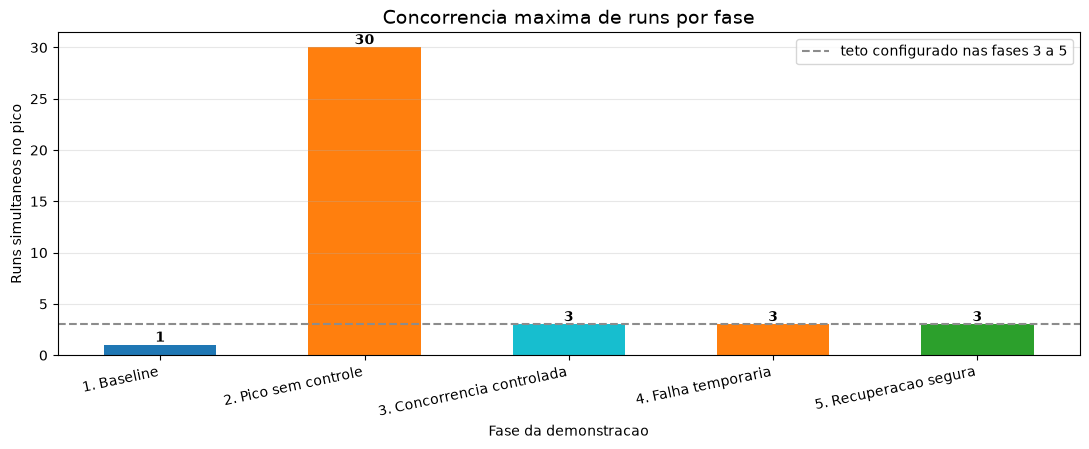

In [59]:
# Celula I.5 - grafico 1: concorrencia maxima por fase
cores_fases = [COR["baseline"], COR["falha"], COR["controle"], COR["falha"], COR["recuperacao"]]
rotulos = [f.split(".")[0] + ". " + f.split(". ")[1].split(" (")[0] for f in df_fases["fase"]]

fig, ax = plt.subplots(figsize=(11, 4.6))
barras = ax.bar(rotulos, df_fases["conc_max"], color=cores_fases, width=0.55)
ax.axhline(3, linestyle="--", color=COR["neutro"], label="teto configurado nas fases 3 a 5")
for b, v in zip(barras, df_fases["conc_max"]):
    ax.text(b.get_x() + b.get_width() / 2, v, str(v), ha="center", va="bottom", fontweight="bold")
ax.set_title("Concorrencia maxima de runs por fase", fontsize=14)
ax.set_xlabel("Fase da demonstracao")
ax.set_ylabel("Runs simultaneos no pico")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

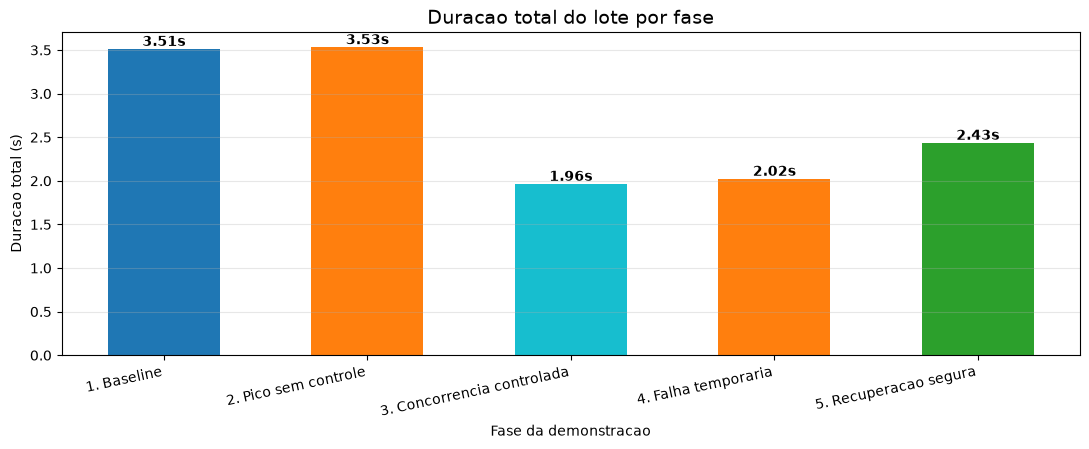

In [60]:
# Celula I.6 - grafico 2: duracao total por fase
fig, ax = plt.subplots(figsize=(11, 4.6))
barras = ax.bar(rotulos, df_fases["duracao_s"], color=cores_fases, width=0.55)
for b, v in zip(barras, df_fases["duracao_s"]):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}s",
            ha="center", va="bottom", fontweight="bold")
ax.set_title("Duracao total do lote por fase", fontsize=14)
ax.set_xlabel("Fase da demonstracao")
ax.set_ylabel("Duracao total (s)")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

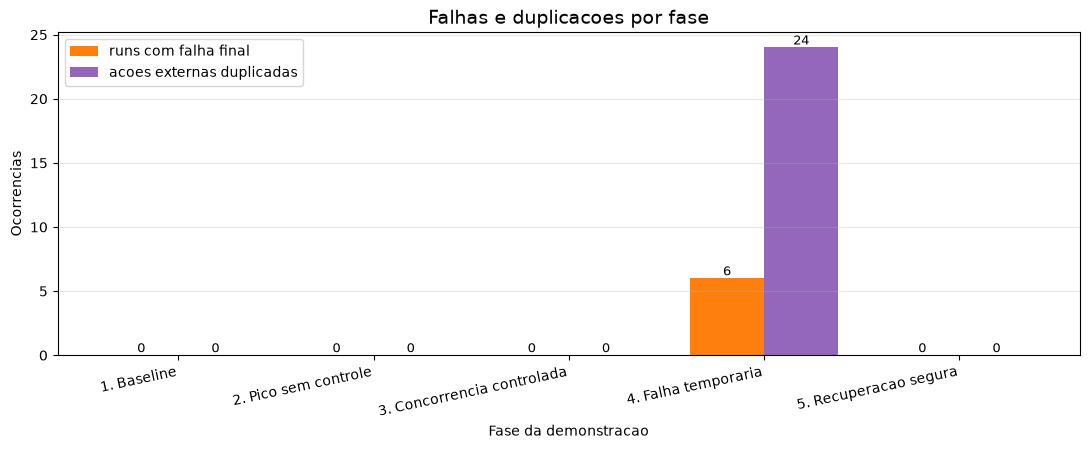

In [61]:
# Celula I.7 - grafico 3: falhas e acoes duplicadas por fase
import numpy as np

x = np.arange(len(rotulos))
largura = 0.38

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.bar(x - largura / 2, df_fases["falhas"], largura, color=COR["falha"], label="runs com falha final")
ax.bar(x + largura / 2, df_fases["acoes_duplicadas"], largura,
       color=COR["persistencia"], label="acoes externas duplicadas")
for xi, (f, d) in enumerate(zip(df_fases["falhas"], df_fases["acoes_duplicadas"])):
    ax.text(xi - largura / 2, f, str(f), ha="center", va="bottom", fontsize=9)
    ax.text(xi + largura / 2, d, str(d), ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(rotulos, rotation=12, ha="right")
ax.set_title("Falhas e duplicacoes por fase", fontsize=14)
ax.set_xlabel("Fase da demonstracao")
ax.set_ylabel("Ocorrencias")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

> ### Observe
>
> - **Da fase 2 para a 3, a concorrencia de runs cai de 30 para 3** e a duracao aumenta.
>   Esse e o preco consciente do controle. Repare que `conc_max_llm_real` ja estava
>   limitado na fase 2: o gateway protege a API mesmo quando a aplicacao nao se protege.
> - **A fase 4 mostra o custo real de uma falha tardia.** Os runs que falharam ja tinham
>   pago a chamada ao modelo. Sem checkpoint, esse trabalho e descartado.
> - **A fase 5 recupera sem repagar.** O `real_api_calls` quase nao cresce em relacao a
>   fase 4, mas `logical_llm_steps` sim - a diferenca esta inteira em `cache_hits`. E
>   `acoes_duplicadas` volta a zero por causa da idempotencia, nao por causa do cache.
> - **O agente nunca mudou.** Entre a fase 2 e a 3 mudou um semaforo; entre a 4 e a 5,
>   tres parametros de politica. As cinco etapas do fluxo sao identicas nas cinco fases.


## Interpretacao

As cinco fases contam uma historia unica: **o agente nunca mudou**.

- O que mudou entre a fase 2 e a 3 foi um **semaforo**.
- O que mudou entre a fase 4 e a 5 foram **tres parametros de politica**: numero de
  tentativas, intervalo entre elas e uma chave de idempotencia.
- Nenhuma dessas mudancas exigiu tocar na logica de negocio do CopaFigurinhas.

Esse e o resultado que se busca em uma arquitetura preparada para escala: as decisoes
operacionais ficam **configuraveis e visiveis**, em vez de espalhadas dentro das regras de
negocio.

## Mensagem de encerramento

> ## O grafo pode permanecer; as politicas de execucao precisam evoluir.

---

# Desafio do aluno - Validando escala e recuperacao

## Instrucoes

Voce recebe 30 eventos do tipo `workflow_run` adaptados ao CopaFigurinhas. Alguns tem uma
**falha temporaria programada** na etapa de analise - que agora e uma **chamada real a
LLM** - e o registro da recomendacao sofre um **timeout depois da gravacao**.

Implemente ou complete:

1. a chamada ao **`LLMGateway`** (via `executar_com_checkpoint`, que ja a utiliza);
2. o **semaforo da LLM** - lembre que ele e global e vive no gateway;
3. o **retry limitado** com backoff;
4. o **checkpoint** para retomada;
5. o **cache** (voce nao precisa implementa-lo: precisa nao sabota-lo, mantendo
   `activity_id` e `prompt_version` estaveis entre as tentativas);
6. a **`idempotency_key`** identica em todas as tentativas;
7. o **status final** de cada run.

### O que o validador exige

| Criterio | O que prova |
| --- | --- |
| 30 runs contabilizados | nenhum evento se perdeu |
| todos passaram pela etapa logica de LLM | o fluxo nao foi curto-circuitado |
| pelo menos uma chamada real | a integracao esta viva, nao so o cache |
| reais + cache hits == etapas logicas | a contabilidade fecha |
| concorrencia real de LLM <= 3 | o limite externo foi respeitado |
| todos com status final | nenhum run ficou pendente |
| nenhuma acao duplicada | a idempotencia funcionou |
| `response_id` ou `cache_key` presente | cada etapa e rastreavel |
| tokens registrados nas chamadas reais | o custo e observavel |


In [62]:
# Celula D.1 - dados ja preparados para o desafio (nao altere esta celula)
EVENTOS_DESAFIO = [Event(event_id=f"evt-{i:03d}", album_id=f"album-{(i * 3 + 5) % 100:03d}",
                         tipo="workflow_run") for i in range(1, 31)]

# Falhas temporarias predefinidas: estes eventos falham na PRIMEIRA tentativa da analise,
# DEPOIS que a resposta da LLM ja foi obtida.
FALHAS_DESAFIO = frozenset(f"evt-{i:03d}" for i in (2, 5, 9, 14, 18, 22, 27, 30))

# Todos os eventos sofrem timeout DEPOIS de gravar a recomendacao (a resposta se perde).
TIMEOUT_APOS_GRAVACAO = True

# Limites conhecidos
LIMITE_LLM_SIMULTANEA = MAX_PARALLEL_LLM_CALLS   # o teto real vive no LLMGateway
MAX_TENTATIVAS_DESAFIO = 3
BACKOFF_DESAFIO = 0.05

# Namespace de cache e versao de prompt do desafio: mantenha estaveis entre tentativas,
# ou o cache deixa de funcionar e cada retry vira uma nova cobranca.
ACTIVITY_ID_DESAFIO = "desafio_aluno"
PROMPT_VERSION_DESAFIO = "desafio_v1"

print(f"{len(EVENTOS_DESAFIO)} eventos | {len(FALHAS_DESAFIO)} com falha programada: "
      f"{sorted(FALHAS_DESAFIO)}")
print(f"Teto de LLM simultanea: {LIMITE_LLM_SIMULTANEA}")
display(pd.DataFrame([asdict(e) for e in EVENTOS_DESAFIO[:4]]))

30 eventos | 8 com falha programada: ['evt-002', 'evt-005', 'evt-009', 'evt-014', 'evt-018', 'evt-022', 'evt-027', 'evt-030']
Teto de LLM simultanea: 3


,event_id,album_id,tipo
0,evt-001,album-008,workflow_run
1,evt-002,album-011,workflow_run
2,evt-003,album-014,workflow_run
3,evt-004,album-017,workflow_run


In [63]:
# Celula D.2 - ESPACO DO ALUNO. Complete os TODOs.
# Esta celula executa sem erro mesmo incompleta: ela apenas devolve uma lista vazia.

async def resolver_desafio(eventos: list[Event]) -> tuple[list[dict], dict]:
    """Devolve (linhas_da_tabela, metricas_gerais).

    TODO 1: montar as Politicas com activity_id=ACTIVITY_ID_DESAFIO,
            prompt_version=PROMPT_VERSION_DESAFIO, n_perfis=4,
            max_tentativas=MAX_TENTATIVAS_DESAFIO, backoff_base=BACKOFF_DESAFIO
            e falhas_programadas=FALHAS_DESAFIO.
            Lembre: o semaforo da LLM NAO se cria aqui - ele e o llm_gateway.semaforo.
    TODO 2: zerar llm_gateway.medidor e marcar a telemetria com marco_llm(),
            para medir apenas o que o desafio produziu
    TODO 3: executar cada evento com checkpoint (executar_com_checkpoint) dentro de um
            laco de retry limitado com backoff, capturando o status final
    TODO 4: registrar a acao externa com a MESMA idempotency_key em todas as tentativas
            (reaproveite RegistroAcoes e registrar_com_politica)
    TODO 5: montar as linhas com event_id, run_id, tentativas, status_final, action_id,
            duracao_s, retries, worker_final e o rastro da LLM
            (response_id ou cache_key, cache_hit, tokens)
    TODO 6: montar as metricas com tempo_total_s, total_retries, duplicacoes,
            logical_llm_steps, real_api_calls, cache_hits, input_tokens, output_tokens
            e pico_llm_real (= llm_gateway.medidor.maximo)
    """
    linhas: list[dict] = []
    metricas = {
        "tempo_total_s": 0.0, "total_retries": 0, "duplicacoes": 0,
        "logical_llm_steps": 0, "real_api_calls": 0, "cache_hits": 0,
        "input_tokens": 0, "output_tokens": 0, "pico_llm_real": 0,
    }
    return linhas, metricas


linhas_aluno, metricas_aluno = await resolver_desafio(EVENTOS_DESAFIO)
print(f"Solucao do aluno: {len(linhas_aluno)} linhas produzidas. "
      f"Complete os TODOs e rode a celula de validacao.")

Solucao do aluno: 0 linhas produzidas. Complete os TODOs e rode a celula de validacao.


In [64]:
# Celula D.3 - validador automatico (use para conferir sua solucao)
def validar_entrega(linhas: list[dict], metricas: dict) -> None:
    """Valida a entrega do desafio. Levanta AssertionError com mensagem clara."""
    df = pd.DataFrame(linhas)

    # 1) 30 runs contabilizados
    assert len(linhas) == 30, (
        f"Todos os 30 eventos devem ser contabilizados; foram encontrados {len(linhas)}.")

    ids = set(df["event_id"])
    esperados = {e.event_id for e in EVENTOS_DESAFIO}
    faltando = esperados - ids
    assert not faltando, f"Nenhuma execucao pode desaparecer; faltaram: {sorted(faltando)}"
    assert len(ids) == 30, f"Os 30 event_id devem ser unicos; ha {len(ids)} distintos."

    # 2) todos passaram pela etapa logica de LLM
    passos = metricas["logical_llm_steps"]
    assert passos >= 30, (
        f"Todo run deve passar pela etapa logica de LLM; foram registradas {passos} "
        f"etapas para 30 runs (retries podem elevar esse numero, nunca reduzi-lo).")

    # 3) pelo menos uma chamada real foi realizada nesta execucao do notebook
    # Na PRIMEIRA execucao o desafio faz as suas proprias chamadas. Numa reexecucao com
    # o cache ja povoado, zero chamadas aqui e o resultado CORRETO - a prova de que a
    # integracao esta viva vem do teste de conectividade, que nunca usa cache.
    assert llm_gateway.real_api_calls >= 1, (
        "Nenhuma chamada real aconteceu em toda a execucao do notebook. A integracao "
        "com a OpenAI nao foi exercitada - verifique o teste de conectividade.")
    if metricas["real_api_calls"] == 0:
        print("Nota: o desafio foi resolvido inteiramente pelo cache (reexecucao). "
              "A integracao real foi comprovada pelo teste de conectividade.")

    # 4) a contabilidade fecha
    assert passos == metricas["real_api_calls"] + metricas["cache_hits"], (
        f"etapas logicas ({passos}) devem ser exatamente chamadas reais "
        f"({metricas['real_api_calls']}) + cache hits ({metricas['cache_hits']}).")

    # 5) concorrencia real da LLM <= 3
    pico = metricas["pico_llm_real"]
    assert pico <= LIMITE_LLM_SIMULTANEA, (
        f"Concorrencia de requisicoes REAIS deve ser <= {LIMITE_LLM_SIMULTANEA}; "
        f"foi observado {pico}.")

    # 6) todos os runs possuem status final
    validos = {"concluido", "falha_final"}
    invalidos = sorted(set(df["status_final"]) - validos)
    assert not invalidos, (
        f"Todo run deve terminar como 'concluido' ou 'falha_final'; encontrado: {invalidos}")

    concluidos = df[df["status_final"] == "concluido"]
    sem_acao = concluidos[concluidos["action_id"].isna() | (concluidos["action_id"] == "")]
    assert sem_acao.empty, (
        f"Runs concluidos devem ter action_id; sem action_id: {sorted(sem_acao['event_id'])}")

    # 7) nenhuma acao duplicada
    acoes = [a for a in concluidos["action_id"] if a]
    assert len(acoes) == len(set(acoes)), (
        f"Nenhum action_id pode se repetir entre runs; "
        f"{len(acoes) - len(set(acoes))} repeticoes encontradas.")
    assert metricas["duplicacoes"] == 0, (
        f"Nenhuma acao externa pode ser duplicada; foram registradas "
        f"{metricas['duplicacoes']} duplicacoes.")

    # 8) response_id ou cache_key disponivel em todo run concluido
    def _tem_rastro(linha) -> bool:
        return bool(linha.get("response_id")) or bool(linha.get("cache_key"))

    sem_rastro = [l["event_id"] for l in linhas
                  if l["status_final"] == "concluido" and not _tem_rastro(l)]
    assert not sem_rastro, (
        f"Todo run concluido precisa de response_id ou cache_key para ser auditavel; "
        f"sem rastro: {sorted(sem_rastro)}")

    # 9) tokens registrados para as chamadas reais
    if metricas["real_api_calls"] > 0:
        assert metricas["input_tokens"] > 0 and metricas["output_tokens"] > 0, (
            "Chamadas reais devem registrar tokens de entrada e de saida; "
            f"recebido entrada={metricas['input_tokens']} "
            f"saida={metricas['output_tokens']}.")

    assert metricas["total_retries"] > 0, (
        "Os retries devem ser registrados; o cenario tem falhas programadas, "
        "logo total_retries deveria ser maior que zero.")

    print("VALIDACAO APROVADA")
    print(f"  runs contabilizados .......... {len(linhas)}")
    print(f"  etapas logicas de LLM ........ {passos}")
    print(f"  chamadas reais a API ......... {metricas['real_api_calls']}")
    print(f"  cache hits ................... {metricas['cache_hits']}")
    print(f"  tokens (entrada/saida) ....... {metricas['input_tokens']}/{metricas['output_tokens']}")
    print(f"  pico de LLM real simultanea .. {pico} (limite {LIMITE_LLM_SIMULTANEA})")
    print(f"  total de retries ............. {metricas['total_retries']}")
    print(f"  acoes duplicadas ............. {metricas['duplicacoes']}")
    print(f"  tempo total .................. {metricas['tempo_total_s']:.3f}s")


print("Validador pronto. Chame validar_entrega(linhas_aluno, metricas_aluno) quando terminar.")

Validador pronto. Chame validar_entrega(linhas_aluno, metricas_aluno) quando terminar.


## Criterios de sucesso

Sua solucao esta correta quando `validar_entrega(linhas_aluno, metricas_aluno)` imprime
**VALIDACAO APROVADA** sem levantar `AssertionError`. Isso significa que:

| Criterio | O que ele prova |
| --- | --- |
| 30 eventos contabilizados | nenhuma execucao desapareceu silenciosamente |
| pico de analises <= 3 | o limite de concorrencia foi realmente aplicado |
| status final valido | nenhum run ficou preso em estado intermediario |
| nenhum `action_id` duplicado | a idempotencia protegeu o efeito externo |
| `total_retries` > 0 | as falhas foram tratadas, e nao mascaradas |

> ### Erro comum no desafio
>
> Contar como "concorrencia maxima" o numero de tarefas criadas, e nao o numero de
> analises **efetivamente em execucao**. O medidor precisa incrementar quando a analise
> comeca e decrementar quando ela termina - por isso usamos `MedidorConcorrencia` como
> context manager em volta da chamada, e nao em volta da criacao da task.

---

# Gabarito do professor

As celulas a seguir estao marcadas com a tag `instructor-solution`. Em uma aula, elas
podem ser ocultadas ate o momento da correcao.

In [65]:
# Celula G.1 [instructor-solution] - solucao de referencia completa
async def resolver_desafio_gabarito(eventos: list[Event]) -> tuple[list[dict], dict]:
    # TODO 1 resolvido: politicas, incluindo o namespace de cache e a versao do prompt.
    # O semaforo da LLM NAO aparece aqui de proposito: ele e global e vive no gateway.
    pol = Politicas(
        limite_runs=asyncio.Semaphore(5),
        limite_catalogo=asyncio.Semaphore(2),
        max_tentativas=MAX_TENTATIVAS_DESAFIO,
        backoff_base=BACKOFF_DESAFIO,
        falhas_programadas=FALHAS_DESAFIO,
        activity_id=ACTIVITY_ID_DESAFIO,
        prompt_version=PROMPT_VERSION_DESAFIO,
        n_perfis=4,
    )
    med = Medidores()
    registro = RegistroAcoes()
    banco = criar_banco(BASE_ARTEFATOS / "desafio_estado.sqlite")

    # TODO 2 resolvido: isolar a medicao deste desafio
    llm_gateway.medidor.zerar()
    marco = marco_llm()

    chegada = time.perf_counter()
    linhas: list[dict] = []

    async def processar(ev: Event) -> None:
        t_ini = time.perf_counter()
        worker = f"worker-{(int(ev.event_id.split('-')[1]) % 3) + 1}"

        # TODO 3 resolvido: retry limitado com backoff, retomando pelo checkpoint.
        # A etapa interrompida e reiniciada; a resposta da LLM vem do cache, porque
        # activity_id e prompt_version nao mudam entre as tentativas.
        status, tentativas = "falha_final", 0
        for tentativa in range(1, MAX_TENTATIVAS_DESAFIO + 1):
            tentativas = tentativa
            if tentativa > 1:
                await asyncio.sleep(BACKOFF_DESAFIO * (2 ** (tentativa - 2)))
            resultado = await executar_com_checkpoint(banco, ev, worker, pol, med)
            if resultado == "concluido":
                status = "concluido"
                break

        # TODO 4 resolvido: acao externa com a MESMA idempotency_key em toda tentativa
        action_id = ""
        if status == "concluido":
            action_id, _ = await registrar_com_politica(
                ev, registro, usar_idempotencia=True,
                timeout_apos_gravacao=TIMEOUT_APOS_GRAVACAO,
                max_tentativas=MAX_TENTATIVAS_DESAFIO, backoff_base=BACKOFF_DESAFIO)

        run_id = banco.execute("SELECT run_id FROM runs WHERE event_id=?",
                               (ev.event_id,)).fetchone()[0]

        # TODO 5 resolvido: rastro da LLM lido do ultimo checkpoint do run
        cp = ler_ultimo_checkpoint(banco, run_id)
        analise = (cp[1].get("analise") if cp else None) or {}

        linhas.append({
            "event_id": ev.event_id,
            "run_id": run_id,
            "tentativas": tentativas,
            "status_final": status,
            "action_id": action_id,
            "duracao_s": round(time.perf_counter() - t_ini, 3),
            "retries": max(0, tentativas - 1),
            "worker_final": worker,
            "response_id": analise.get("response_id"),
            "cache_key": analise.get("cache_key"),
            "cache_hit": analise.get("cache_hit"),
            "tokens_entrada": analise.get("tokens_entrada", 0),
            "tokens_saida": analise.get("tokens_saida", 0),
        })

    with Cronometro() as c:
        await asyncio.gather(*[processar(ev) for ev in eventos])
    banco.close()

    linhas.sort(key=lambda linha: linha["event_id"])

    # TODO 6 resolvido: metricas gerais, separando etapas logicas de chamadas reais
    llm = metricas_llm_desde(marco)
    metricas = {
        "tempo_total_s": c.duracao,
        "total_retries": sum(linha["retries"] for linha in linhas),
        "duplicacoes": registro.duplicacoes,
        "logical_llm_steps": llm["logical_llm_steps"],
        "real_api_calls": llm["real_api_calls"],
        "cache_hits": llm["cache_hits"],
        "input_tokens": llm["input_tokens"],
        "output_tokens": llm["output_tokens"],
        "pico_llm_real": llm_gateway.medidor.maximo,
    }
    return linhas, metricas


linhas_gabarito, metricas_gabarito = await resolver_desafio_gabarito(EVENTOS_DESAFIO)
log.info("Gabarito executado: %d runs em %.2fs | etapas LLM=%d reais=%d cache=%d",
         len(linhas_gabarito), metricas_gabarito["tempo_total_s"],
         metricas_gabarito["logical_llm_steps"], metricas_gabarito["real_api_calls"],
         metricas_gabarito["cache_hits"])

Gabarito executado: 30 runs em 10.18s | etapas LLM=38 reais=4 cache=34


In [66]:
# Celula G.2 [instructor-solution] - entrega minima: tabela por run
df_desafio = pd.DataFrame(linhas_gabarito)
print("Entrega minima - primeiras 12 linhas de", len(df_desafio), ":")
display(df_desafio[["event_id", "run_id", "tentativas", "status_final", "action_id",
                    "retries", "cache_hit", "tokens_entrada", "tokens_saida"]].head(12))

print("\nRastro de auditoria (response_id ou cache_key por run) - amostra:")
display(df_desafio[["event_id", "response_id", "cache_key", "cache_hit"]].head(6))

Entrega minima - primeiras 12 linhas de 30 :


,event_id,run_id,tentativas,status_final,action_id,retries,cache_hit,tokens_entrada,tokens_saida
0,evt-001,run-0474-evt-001,1,concluido,act-0002,0,False,413,175
1,evt-002,run-0475-evt-002,2,concluido,act-0021,1,True,409,155
2,evt-003,run-0476-evt-003,1,concluido,act-0001,0,True,409,155
3,evt-004,run-0477-evt-004,1,concluido,act-0003,0,True,413,175
4,evt-005,run-0478-evt-005,2,concluido,act-0023,1,True,413,175
5,evt-006,run-0479-evt-006,1,concluido,act-0004,0,True,413,175
6,evt-007,run-0480-evt-007,1,concluido,act-0005,0,True,413,175
7,evt-008,run-0481-evt-008,1,concluido,act-0008,0,False,409,146
8,evt-009,run-0482-evt-009,2,concluido,act-0024,1,True,409,146
9,evt-010,run-0483-evt-010,1,concluido,act-0006,0,True,409,155



Rastro de auditoria (response_id ou cache_key por run) - amostra:


,event_id,response_id,cache_key,cache_hit
0,evt-001,resp_0d7543ad0bd2f1dc006a5dab03a8d0819781d2326...,2eb732f19de288c1,False
1,evt-002,resp_0563fb4e3aaf9ab7006a5dab03a8cc8194bc8e0ef...,41bfff1041375516,True
2,evt-003,resp_0563fb4e3aaf9ab7006a5dab03a8cc8194bc8e0ef...,41bfff1041375516,True
3,evt-004,resp_0d7543ad0bd2f1dc006a5dab03a8d0819781d2326...,2eb732f19de288c1,True
4,evt-005,resp_0d7543ad0bd2f1dc006a5dab03a8d0819781d2326...,2eb732f19de288c1,True
5,evt-006,resp_0d7543ad0bd2f1dc006a5dab03a8d0819781d2326...,2eb732f19de288c1,True


In [67]:
# Celula G.3 [instructor-solution] - metricas gerais e validacao automatica
print("Metricas gerais do desafio:")
display(pd.DataFrame([{
    "tempo_total_s": round(metricas_gabarito["tempo_total_s"], 3),
    "total_retries": metricas_gabarito["total_retries"],
    "duplicacoes": metricas_gabarito["duplicacoes"],
    "logical_llm_steps": metricas_gabarito["logical_llm_steps"],
    "real_api_calls": metricas_gabarito["real_api_calls"],
    "cache_hits": metricas_gabarito["cache_hits"],
    "input_tokens": metricas_gabarito["input_tokens"],
    "output_tokens": metricas_gabarito["output_tokens"],
    "pico_llm_real": metricas_gabarito["pico_llm_real"],
}]))
print()
validar_entrega(linhas_gabarito, metricas_gabarito)

Metricas gerais do desafio:


,tempo_total_s,total_retries,duplicacoes,logical_llm_steps,real_api_calls,cache_hits,input_tokens,output_tokens,pico_llm_real
0,10.183,8,0,38,4,34,1646,613,2



VALIDACAO APROVADA
  runs contabilizados .......... 30
  etapas logicas de LLM ........ 38
  chamadas reais a API ......... 4
  cache hits ................... 34
  tokens (entrada/saida) ....... 1646/613
  pico de LLM real simultanea .. 2 (limite 3)
  total de retries ............. 8
  acoes duplicadas ............. 0
  tempo total .................. 10.183s


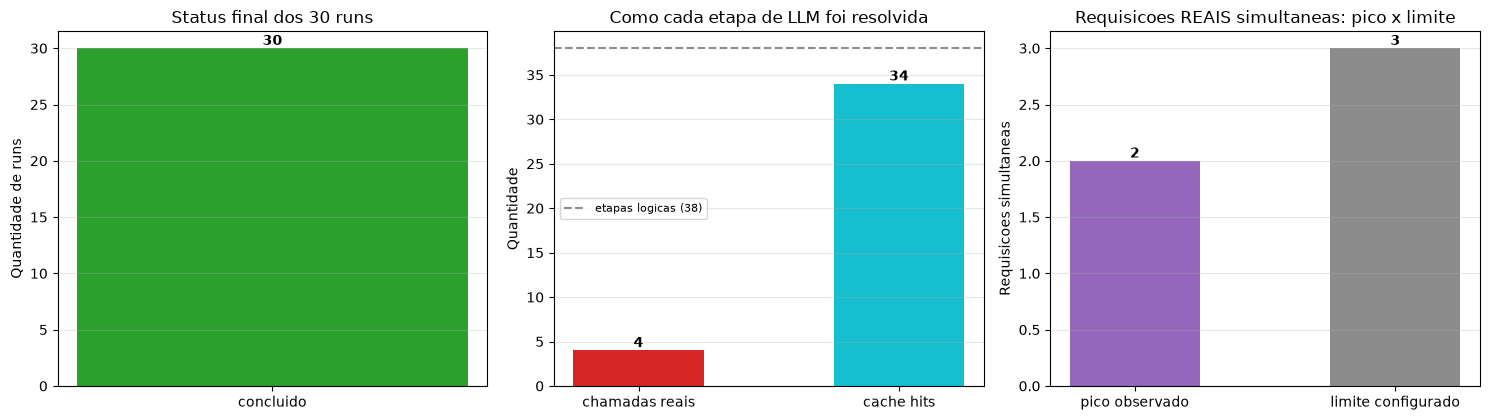

Etapas logicas de LLM: 38 = 4 reais + 34 do cache


In [68]:
# Celula G.4 [instructor-solution] - evidencias visuais do desafio
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

contagem = df_desafio["status_final"].value_counts()
axes[0].bar(contagem.index, contagem.values,
            color=[COR["recuperacao"] if s == "concluido" else COR["falha"]
                   for s in contagem.index], width=0.5)
for i, v in enumerate(contagem.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom", fontweight="bold")
axes[0].set_title("Status final dos 30 runs", fontsize=12)
axes[0].set_ylabel("Quantidade de runs")
axes[0].grid(axis="y", alpha=0.3)

# Etapas logicas de LLM x como elas foram resolvidas.
resolucao = ["chamadas reais", "cache hits"]
valores = [metricas_gabarito["real_api_calls"], metricas_gabarito["cache_hits"]]
axes[1].bar(resolucao, valores, color=[COR["llm"], COR["controle"]], width=0.5)
for i, v in enumerate(valores):
    axes[1].text(i, v, str(v), ha="center", va="bottom", fontweight="bold")
axes[1].axhline(metricas_gabarito["logical_llm_steps"], linestyle="--",
                color=COR["neutro"],
                label=f"etapas logicas ({metricas_gabarito['logical_llm_steps']})")
axes[1].set_title("Como cada etapa de LLM foi resolvida", fontsize=12)
axes[1].set_ylabel("Quantidade")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

medidas = ["pico observado", "limite configurado"]
picos = [metricas_gabarito["pico_llm_real"], LIMITE_LLM_SIMULTANEA]
axes[2].bar(medidas, picos, color=[COR["persistencia"], COR["neutro"]], width=0.5)
for i, v in enumerate(picos):
    axes[2].text(i, v, str(v), ha="center", va="bottom", fontweight="bold")
axes[2].set_title("Requisicoes REAIS simultaneas: pico x limite", fontsize=12)
axes[2].set_ylabel("Requisicoes simultaneas")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Etapas logicas de LLM: {metricas_gabarito['logical_llm_steps']} "
      f"= {metricas_gabarito['real_api_calls']} reais "
      f"+ {metricas_gabarito['cache_hits']} do cache")

> ### Relacao com o Pipeline Guardian e com producao
>
> O desafio reproduz, em miniatura, a lista de verificacao que uma equipe usa antes de
> liberar um agente para producao: nenhum evento perdido, limite de concorrencia
> comprovado por medicao, todo run em estado terminal, nenhum efeito externo duplicado e
> falhas registradas em vez de escondidas.
>
> Se essas cinco assercoes rodam automaticamente no CI a cada mudanca, a equipe passa a ter
> uma **rede de seguranca operacional** - e nao apenas testes de logica de negocio.

---

# Telemetria das chamadas ao modelo

Uma unica tabela reune tudo o que aconteceu na camada de LLM durante a execucao inteira
do notebook. Ela e o que permite responder, depois da aula, perguntas como "qual
atividade consumiu mais tokens?" ou "houve retry em producao?".

**O que esta tabela deliberadamente NAO contem:** a API key, o conteudo do `.env`, os
prompts enviados, os cabecalhos das requisicoes e os objetos brutos do cliente. Prompts
podem carregar dados de negocio, e telemetria costuma ir para sistemas com controle de
acesso mais frouxo do que a aplicacao que a gerou. O `cache_key` aparece truncado em 16
caracteres - o suficiente para correlacionar registros, insuficiente para reconstruir
qualquer entrada.

**Como ler as linhas de cache hit.** Elas repetem o `response_id` e os tokens da chamada
original de proposito: e assim que se descobre *qual* requisicao pagou por aquele
resultado. Mas esses tokens **nao foram consumidos de novo** - por isso o resumo abaixo
soma tokens apenas nas linhas com `cache_hit=False`. Somar a coluna inteira contaria
duas vezes um custo que aconteceu uma vez, que e exatamente o erro que este notebook
tenta evitar.


In [69]:
# Celula T.1 - DataFrame de telemetria das chamadas
llm_telemetry_df = pd.DataFrame(LLM_TELEMETRIA, columns=[
    "timestamp", "activity_id", "event_id", "run_id", "model", "prompt_version",
    "response_id", "cache_key", "cache_hit", "cache_source", "attempts",
    "wait_seconds", "latency_seconds", "input_tokens", "output_tokens",
    "status", "error_type",
])

print(f"Registros de telemetria: {len(llm_telemetry_df)}")
print("Amostra (5 primeiras linhas):")
display(llm_telemetry_df.head())

print("\nResumo por atividade:")
# Os tokens sao somados APENAS nas chamadas reais. Uma linha de cache hit repete os
# tokens da chamada original para fins de auditoria - soma-los seria contabilizar
# duas vezes um consumo que aconteceu uma vez so.
_tel = llm_telemetry_df.assign(
    chamada_real=lambda d: (~d["cache_hit"]) & (d["status"] == "ok"))
_tel["input_tokens_reais"] = _tel["input_tokens"].where(_tel["chamada_real"], 0)
_tel["output_tokens_reais"] = _tel["output_tokens"].where(_tel["chamada_real"], 0)

resumo_atividades = (_tel
    .groupby("activity_id")
    .agg(etapas_logicas=("activity_id", "size"),
         chamadas_reais=("chamada_real", "sum"),
         cache_hits=("cache_hit", "sum"),
         input_tokens=("input_tokens_reais", "sum"),
         output_tokens=("output_tokens_reais", "sum"),
         latencia_total_s=("latency_seconds", "sum"),
         espera_total_s=("wait_seconds", "sum"))
    .round(3))
display(resumo_atividades)

assert int(resumo_atividades["input_tokens"].sum()) == llm_gateway.input_tokens, (
    "os tokens do resumo devem bater com os contadores do gateway")
print("Tokens do resumo conferem com os contadores do gateway (somente chamadas reais).")

# Prova de que nenhum segredo vazou para a telemetria.
_colunas_proibidas = {"api_key", "authorization", "headers", "prompt", "system_prompt",
                      "user_prompt", "client"}
assert not (_colunas_proibidas & set(llm_telemetry_df.columns)), \
    "a telemetria nao pode conter prompts, credenciais ou cabecalhos"
_texto_telemetria = llm_telemetry_df.to_csv(index=False)
assert OPENAI_API_KEY not in _texto_telemetria, "a API key nao pode aparecer na telemetria"
print("\nVerificacao de seguranca: nenhuma credencial e nenhum prompt na telemetria. OK")

Registros de telemetria: 498
Amostra (5 primeiras linhas):


,timestamp,activity_id,event_id,run_id,model,prompt_version,response_id,cache_key,cache_hit,cache_source,attempts,wait_seconds,latency_seconds,input_tokens,output_tokens,status,error_type
0,1.784523e+09,teste_conectividade,-,-,gpt-5-mini,conectividade_v1,resp_02cca460b41f8143006a5daa95be748196b02beee...,5a68c93192ba1978,False,api,1,0.0,1.9226,32,21,ok,None
1,1.784523e+09,atividade_01_escala,evt-001,run-0001-evt-001,gpt-5-mini,scale_v1,resp_0f81b2513008601e006a5daa9819948190ade00dc...,0566b1c9ed0e9d50,False,api,1,0.0,2.3000,413,184,ok,None
2,1.784523e+09,atividade_01_escala,evt-001,run-0002-evt-001,gpt-5-mini,scale_v1,resp_0f81b2513008601e006a5daa9819948190ade00dc...,0566b1c9ed0e9d50,True,sqlite,0,0.0,0.0000,413,184,cache_hit,None
3,1.784523e+09,atividade_01_escala,evt-004,run-0005-evt-004,gpt-5-mini,scale_v1,resp_0f81b2513008601e006a5daa9819948190ade00dc...,0566b1c9ed0e9d50,True,sqlite,0,0.0,0.0000,413,184,cache_hit,None
4,1.784523e+09,atividade_01_escala,evt-005,run-0006-evt-005,gpt-5-mini,scale_v1,resp_0f81b2513008601e006a5daa9819948190ade00dc...,0566b1c9ed0e9d50,True,sqlite,0,0.0,0.0000,413,184,cache_hit,None



Resumo por atividade:


,etapas_logicas,chamadas_reais,cache_hits,input_tokens,output_tokens,latencia_total_s,espera_total_s
activity_id,,,,,,,
atividade_01_escala,111,8,103,3302,1297,22.464,3.127
atividade_02_gargalo,90,4,86,1646,610,10.223,0.000
atividade_03_fila,33,4,29,1646,656,9.874,0.000
atividade_04_limites,90,4,86,1646,659,11.542,0.000
atividade_05_checkpoint,2,1,1,409,137,2.654,0.000
atividade_06_estado,5,4,1,1709,606,9.253,0.000
atividade_07_idempotencia,1,1,0,409,151,2.081,0.000
demonstracao_integrada,127,4,123,1646,653,10.091,0.000
desafio_aluno,38,4,34,1646,613,13.132,0.000


Tokens do resumo conferem com os contadores do gateway (somente chamadas reais).

Verificacao de seguranca: nenhuma credencial e nenhum prompt na telemetria. OK


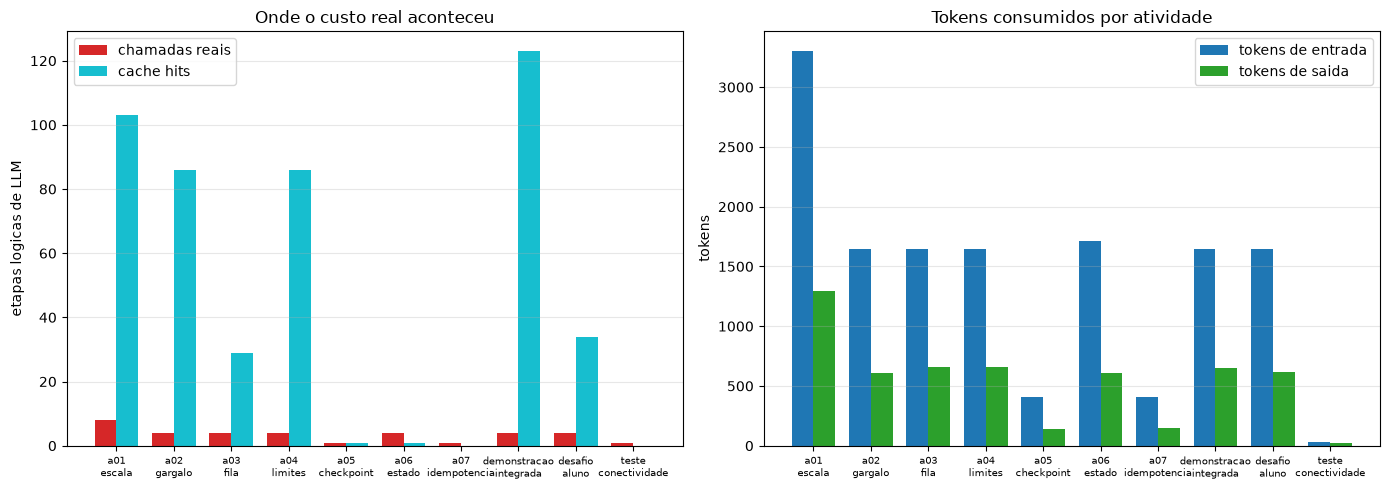

Execucao completa do notebook:
  logical_llm_steps......... 498
  real_api_calls............ 35
  cache_hits................ 463
  input_tokens.............. 14091
  output_tokens............. 5403
  llm_latency_seconds....... 93.236
  llm_errors................ 0
  llm_retries............... 0
  conc_max_llm_real......... 2
  orcamento_restante........ 5

  tokens: entrada=14091 saida=5403 total=19494 | custo monetario nao configurado (somente tokens)
  embeddings: 1 requisicoes, 191 tokens (somente na atividade 6)


In [70]:
# Celula T.2 - visao geral do consumo por atividade
ativas = resumo_atividades[resumo_atividades["etapas_logicas"] > 0]
x = list(range(len(ativas)))
largura = 0.38

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar([i - largura / 2 for i in x], ativas["chamadas_reais"], largura,
            label="chamadas reais", color=COR["llm"])
axes[0].bar([i + largura / 2 for i in x], ativas["cache_hits"], largura,
            label="cache hits", color=COR["controle"])
axes[0].set_xticks(x, [a.replace("atividade_", "a").replace("_", "\n")
                       for a in ativas.index], fontsize=7)
axes[0].set_ylabel("etapas logicas de LLM")
axes[0].set_title("Onde o custo real aconteceu")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar([i - largura / 2 for i in x], ativas["input_tokens"], largura,
            label="tokens de entrada", color=COR["baseline"])
axes[1].bar([i + largura / 2 for i in x], ativas["output_tokens"], largura,
            label="tokens de saida", color=COR["recuperacao"])
axes[1].set_xticks(x, [a.replace("atividade_", "a").replace("_", "\n")
                       for a in ativas.index], fontsize=7)
axes[1].set_ylabel("tokens")
axes[1].set_title("Tokens consumidos por atividade")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

total = llm_gateway.resumo()
print("Execucao completa do notebook:")
for k, v in total.items():
    print(f"  {k:.<26} {v}")
print()
print(" ", custo_ilustrativo_texto(total["input_tokens"], total["output_tokens"]))
if OPENAI_EMBEDDING_MODEL:
    print(f"  embeddings: {llm_gateway.embedding_calls} requisicoes, "
          f"{llm_gateway.embedding_tokens} tokens (somente na atividade 6)")

---

# Sintese da aula

| Atividade | Problema | Controle |
| --- | --- | --- |
| 1 | O comportamento muda com a escala, mesmo com o fluxo identico | medir volume, latencia, confiabilidade e custo |
| 2 | A capacidade e limitada pela etapa mais restrita | instrumentar por etapa e medir o gargalo |
| 3 | Um pico atinge os workers diretamente e derruba eventos | fila entre a entrada e a execucao |
| 4 | Mais workers nao superam limites externos | semaforos independentes por dependencia |
| 5 | O worker morre e o progresso se perde | estado externo e checkpoints |
| 6 | O estado incha e cada checkpoint fica caro | estado enxuto com referencias a artefatos e memoria |
| 7 | O retry duplica efeitos externos | timeout, retry limitado, backoff e idempotencia |

Em nenhuma dessas atividades o fluxo logico do CopaFigurinhas foi alterado.

> ## O fluxo logico pode permanecer; as politicas de execucao precisam evoluir.

In [71]:
# Celula final - inventario dos artefatos temporarios
# Fecha as conexoes SQLite abertas pelo notebook.
for conexao in ("con", "con_acoes"):
    obj = globals().get(conexao)
    if isinstance(obj, sqlite3.Connection):
        obj.close()

print("Conteudo do diretorio temporario:")
for p in sorted(BASE_ARTEFATOS.rglob("*")):
    marca = "  [preservado]" if p.name in ARQUIVOS_PRESERVADOS else ""
    print("  ", p.relative_to(BASE_ARTEFATOS),
          f"({p.stat().st_size} bytes)" if p.is_file() else "(dir)", marca)

print()
print(f"Cache de LLM: {CACHE_LLM.execute('SELECT COUNT(*) FROM llm_cache').fetchone()[0]} "
      f"entradas armazenadas.")
print("Uma segunda execucao deste notebook reaproveitara essas respostas e fara")
print("significativamente menos chamadas reais.")
print()
print("# Para limpar os artefatos MANTENDO o cache (recomendado):")
print("#     limpar_artefatos()")
print("# Para limpar TUDO, inclusive o cache (voce pagara as respostas de novo):")
print("#     limpar_artefatos(incluir_cache_llm=True)")
print()
print("Nenhum arquivo da aplicacao CopaFigurinhas, do Pipeline Guardian ou o .env")
print("foi criado, alterado ou removido por este notebook.")

Conteudo do diretorio temporario:
   checkpoint_enxuto.json (435 bytes) 
   checkpoint_pesado.json (44985 bytes) 
   copafigurinhas_acoes.sqlite (24576 bytes) 
   copafigurinhas_estado.sqlite (24576 bytes) 
   desafio_estado.sqlite (172032 bytes) 
   evt-042 (dir) 
   evt-042/analise_llm.json (41766 bytes) 
   llm_cache.sqlite3 (65536 bytes)   [preservado]
   memoria_vetorial.json (93228 bytes) 

Cache de LLM: 35 entradas armazenadas.
Uma segunda execucao deste notebook reaproveitara essas respostas e fara
significativamente menos chamadas reais.

# Para limpar os artefatos MANTENDO o cache (recomendado):
#     limpar_artefatos()
# Para limpar TUDO, inclusive o cache (voce pagara as respostas de novo):
#     limpar_artefatos(incluir_cache_llm=True)

Nenhum arquivo da aplicacao CopaFigurinhas, do Pipeline Guardian ou o .env
foi criado, alterado ou removido por este notebook.
